<a href="https://colab.research.google.com/github/zxtine/kmsg_project/blob/main/kmsg_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KMSG Capstone: Nonprofit Funder Discovery Pipeline

## Overview
This notebook builds a clean, end-to-end pipeline to identify qualified nonprofit funders and extract grant relationships using IRS and ProPublica data.

## Pipeline Stages
1. Data Loading (EO BMF)
2. Revenue Qualification
3. ProPublica Enrichment
4. IRS XML Parsing
5. Grant Extraction (Schedule I)
6. Data Merging and Cleaning
7. Exploratory Data Analysis

## Output
Clean funder + recipient dataset for downstream analysis and visualization.

# SECTION 1: SETUP AND CONFIGURATION

**Goal:** Initialize environment, imports, and data access.

**Why it matters:** Ensures reproducibility and consistent data access across the pipeline.

In [ ]:
# =========================================================
# IMPORTS AND CONFIGURATION
# Purpose: Set all notebook-wide settings in one place.
# NOTE:
# - requests → API calls (ProPublica, IRS)
# - pandas → data manipulation
# - xml → IRS 990 parsing
# =========================================================
from __future__ import annotations

import json
import re
import time
from pathlib import Path
BASE_DIR = Path(".")
from typing import Any, Dict, List, Optional

import pandas as pd
import requests

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# -----------------------------
# Core scope
# -----------------------------
TARGET_STATE = "PA"
TARGET_YEARS = list(range(2020, 2024))   # 2020, 2021, 2022, 2023, 2024
MIN_REVENUE = 1_000_000

# -----------------------------
# ProPublica endpoints
# -----------------------------
PROPUBLICA_BASE = "https://projects.propublica.org/nonprofits/api/v2"
PROPUBLICA_SEARCH_URL = f"{PROPUBLICA_BASE}/search.json"
PROPUBLICA_ORG_URL = f"{PROPUBLICA_BASE}/organizations/{{ein}}.json"
# -----------------------------
# IRS XML directory
# -----------------------------
IRS_XML_DIR = BASE_DIR / "irs_xml"

IRS_XML_DIR.mkdir(parents=True, exist_ok=True)
WHITESPACE_RE = re.compile(r"\s+")
INDEX_URL_TEMPLATE = "https://apps.irs.gov/pub/epostcard/990/xml/{year}/index_{year}.csv"
XML_PUBLIC_URL_TEMPLATE = "https://apps.irs.gov/pub/epostcard/990/xml/{year}/{object_id}_public.xml"
XML_S3_URL_TEMPLATE = "https://pp-990-xml.s3.us-east-1.amazonaws.com/{object_id}_public.xml"
EO_BMF_PA_URL         = "https://www.irs.gov/pub/irs-soi/eo_pa.csv"

# -----------------------------
# Discovery controls
# -----------------------------
STATE_ID = "PA"

# Use C_CODE_ID = 3 if you want 501(c)(3) discovery only.
# Set to None if you want broader discovery.
C_CODE_ID: Optional[int] = 3

# NTEE major group filter; keep None unless you specifically want one major group.
NTEE_MAJOR_ID: Optional[int] = None

MAX_SEARCH_PAGES = 5000   # increase later if needed
REQUEST_TIMEOUT_SEC = 30
PER_REQUEST_SLEEP_SEC = 0.10

# -----------------------------
# Paths
# -----------------------------
BASE_DIR = Path(".")
RAW_DIR = BASE_DIR / "raw_json"
OUT_DIR = BASE_DIR / "outputs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
"""
# -----------------------------
# Recipient master file
# UPDATE THIS
# -----------------------------
RECIPIENT_MASTER_PATH = Path("pa_nonprofit_data_cleaned.csv")

# Update these after checking your actual CSV columns
RECIPIENT_MASTER_EIN_COL = "ein"
RECIPIENT_MASTER_NAME_COL = "name"
RECIPIENT_MASTER_ZIP_COL = "zipcode"
"""

print("Configuration loaded.")
print("Target state:", TARGET_STATE)
print("Target years:", TARGET_YEARS)
print("Minimum revenue:", f"${MIN_REVENUE:,.0f}")

Configuration loaded.
Target state: PA
Target years: [2020, 2021, 2022, 2023]
Minimum revenue: $1,000,000


### Connect to Data Source

Mount Google Drive to access stored datasets and outputs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================================================
# RELOAD CELL — run this after any disconnect
# Loads all saved checkpoints so nothing has to rerun
# =========================================================
import json
from pathlib import Path

print("Loading saved checkpoints...\n")

# --- funder org table ---
funder_org_enriched_df = pd.read_csv(OUT_DIR / "funder_org_df.csv", low_memory=False)
print(f"✓ funder_org_enriched_df : {funder_org_enriched_df.shape}")

# --- funder filings table ---
funder_filings_df = pd.read_csv(OUT_DIR / "funder_filings_df.csv", low_memory=False)
print(f"✓ funder_filings_df      : {funder_filings_df.shape}")

# --- qualified orgs ---
qualified_orgs = pd.read_csv(OUT_DIR / "qualified_orgs.csv", low_memory=False)
print(f"✓ qualified_orgs         : {qualified_orgs.shape}")

# --- qualified with object IDs ---
qualified_with_object_df = pd.read_csv(OUT_DIR / "qualified_with_object_df.csv", low_memory=False)
print(f"✓ qualified_with_object_df: {qualified_with_object_df.shape}")

# --- final grants ---
final_grants_df = pd.read_csv(OUT_DIR / "final_grants_df.csv", low_memory=False)
print(f"✓ final_grants_df        : {final_grants_df.shape}")

# --- reload org JSON cache into memory (for any cells that need org_json_by_ein) ---
print(f"\nLoading org JSON cache...")
org_json_by_ein = {}
for f in RAW_DIR.glob("org_*.json"):
    ein = f.stem.replace("org_", "")
    with f.open("r", encoding="utf-8") as fp:
        org_json_by_ein[ein] = json.load(fp)
print(f"✓ org_json_by_ein        : {len(org_json_by_ein):,} EINs loaded")

print(f"\n✓ All checkpoints loaded — ready to continue from any cell")

Loading saved checkpoints...



FileNotFoundError: [Errno 2] No such file or directory: 'outputs/funder_org_df.csv'

# SECTION 2: HELPER FUNCTIONS

**Goal:** Define reusable functions for API calls, retries, and parsing.

**Why it matters:** Improves modularity and prevents repeated logic across the notebook.

In [ ]:
# =========================================================
# Helper functions for:
# - API requests with retries
# - Data formatting
# - XML parsing utilities

# Designed to be reused across multiple pipeline stages
# ========================================================
EIN_RE = re.compile(r"\D+")

def clean_ein(x: Any) -> Optional[str]:
    """
    Keep digits only. Return None if empty after cleaning.
    """
    if pd.isna(x) or x is None:
        return None
    s = EIN_RE.sub("", str(x))
    return s if s else None

def clean_text(x: Any) -> Optional[str]:
    """
    Basic safe text cleaning.
    """
    if pd.isna(x) or x is None:
        return None
    s = str(x).strip()
    return s if s else None

def normalize_name(x: Any) -> Optional[str]:
    """
    Clean and normalize organization names for matching.
    Keeps this conservative and readable.
    """
    s = clean_text(x)
    if s is None:
        return None

    s = s.upper()
    s = re.sub(r"[^\w\s]", " ", s)
    s = re.sub(r"\b(INC|INCORPORATED|LLC|LLP|CORP|CORPORATION|FOUNDATION|FUND|TRUST)\b", "", s)
    s = re.sub(r"\s+", " ", s).strip()

    return s if s else None

def clean_zip(x: Any) -> Optional[str]:
    """
    Keep first 5 digits only.
    """
    if pd.isna(x) or x is None:
        return None
    s = re.sub(r"\D", "", str(x))
    if len(s) >= 5:
        return s[:5]
    return s if s else None

def to_int_safe(x: Any) -> Optional[int]:
    try:
        return int(float(x))
    except:
        return None

def to_float_safe(x: Any) -> Optional[float]:
    try:
        return float(x)
    except:
        return None

def make_retry_session() -> requests.Session:
    """
    One retry-enabled session for all HTTP calls.
    """
    session = requests.Session()
    retry = Retry(total=4,
        read=4,
        connect=4,
        backoff_factor=1.0,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],)
    adapter = HTTPAdapter(max_retries=retry)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    session.headers.update({"User-Agent": "Mozilla/5.0"})
    return session

session = make_retry_session()
def fetch_latest_filing_info(session: requests.Session, ein: str):
    url = PROPUBLICA_ORG_URL.format(ein=ein)

    try:
        resp = session.get(url, timeout=REQUEST_TIMEOUT_SEC)
        if resp.status_code != 200:
            return None

        data = resp.json()
        filings = data.get("filings_with_data", [])

        if not filings:
            return None

        latest = filings[0]

        return {
            "totrevenue": to_float_safe(latest.get("totrevenue")),
            "object_id": clean_text(latest.get("object_id")),
            "tax_year": to_int_safe(latest.get("tax_prd_yr")),
            "subseccd": clean_text(latest.get("subseccd")),}

    except Exception:
        return None

print("Helper functions loaded.")

Helper functions loaded.


# SECTION 3: EO BMF DATA LOADING AND INITIAL FILTERING

**Goal:** Load IRS EO BMF dataset and identify relevant nonprofit organizations.

**Why it matters:** This forms the base population of organizations for all downstream filtering and enrichment.

In [ ]:
# =========================================================
# Load EO BMF dataset
# Filter for:
# - 501(c)(3) organizations
# - Pennsylvania (if applicable)
# - Initial candidate pool
# =========================================================
import pandas as pd
import re

def clean_ein(x):
    if pd.isna(x) or x is None: return None
    s = re.sub(r"\D+", "", str(x))
    return s if s else None

print("Loading EO BMF...")
bmf = pd.read_csv("https://www.irs.gov/pub/irs-soi/eo_pa.csv", low_memory=False)
bmf["ein_clean"]   = bmf["EIN"].apply(clean_ein)
bmf["state_clean"] = bmf["STATE"].astype(str).str.upper().str.strip()
bmf["sub_clean"]   = bmf["SUBSECTION"].astype(str).str.strip()
bmf["revenue_amt"] = pd.to_numeric(bmf["REVENUE_AMT"], errors="coerce")

pa = bmf[(bmf["state_clean"] == "PA") & (bmf["sub_clean"] == "3")].copy()
print(f"Total PA 501(c)(3): {len(pa):,}")

confirmed   = pa[pa["revenue_amt"] >= 1_000_000].copy()
missing_rev = pa[pa["revenue_amt"].isna()].copy()

print(f"\nConfirmed over $1M : {len(confirmed):,}")
print(f"Missing revenue     : {len(missing_rev):,}")
print(f"\nConfirmed sample:")
display(confirmed[["ein_clean","NAME","CITY","REVENUE_AMT"]].head(5))

Loading EO BMF...
Total PA 501(c)(3): 64,055

Confirmed over $1M : 4,921
Missing revenue     : 21,219

Confirmed sample:


,ein_clean,NAME,CITY,REVENUE_AMT
7,10560081,NATIONAL NURSE-LED CARE CONSORTIUM,PHILADELPHIA,14278536.0
13,10564355,THE FOUNDATION FOR ENHANCING COMMUNITIES,HARRISBURG,16860850.0
18,10574830,NCC NEUMANN SENIOR HOUSING CORPORATION,PHILADELPHIA,1037430.0
36,10617023,CENTER OF LIFE,PITTSBURGH,3057129.0
64,10666441,CORIS PLACE,HANOVER TWP,3397311.0


# SECTION 4: REVENUE VALIDATION AND QUALIFICATION

**Goal:** Identify organizations with revenue > $1M using IRS filings.

**Why it matters:** Ensures only financially relevant funders are included in the analysis.

In [ ]:
# =========================================================
# # Identify organizations missing revenue data
# Cross-check IRS filings to recover missing financials

# Output:
# - Clean list of qualified organizations
# - Object IDs for XML retrieval
# =========================================================

import requests, time
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from pathlib import Path

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

session = requests.Session()
session.mount("https://", HTTPAdapter(max_retries=Retry(total=3, backoff_factor=1.0)))
session.headers.update({"User-Agent": "Mozilla/5.0"})

TARGET_YEARS = list(range(2020, 2025))
INDEX_URL    = "https://apps.irs.gov/pub/epostcard/990/xml/{year}/index_{year}.csv"

print("Loading IRS XML index for 2020-2024...")
frames = []
for year in TARGET_YEARS:
    df = pd.read_csv(INDEX_URL.format(year=year), low_memory=False)
    df["source_year"] = year
    frames.append(df)
    print(f"  {year}: {len(df):,} rows")

irs_index = pd.concat(frames, ignore_index=True)
irs_index["ein_clean"] = irs_index["EIN"].apply(clean_ein)

# Fix OBJECT_ID scientific notation
irs_index["OBJECT_ID"] = (irs_index["OBJECT_ID"].astype(str)
    .str.replace(r"\.0$", "", regex=True).str.strip())

# Derive tax year from TAX_PERIOD e.g. "202212" → 2022
irs_index["tax_year"] = (irs_index["TAX_PERIOD"].astype(str).str[:4]
    .apply(lambda x: int(x) if x.isdigit() else None))

print(f"\nFull index shape: {irs_index.shape}")
print(f"Columns: {irs_index.columns.tolist()}")
print(f"\nSample:")
display(irs_index.head(3))

# How many of the 21k missing-revenue EINs appear in the XML index?
missing_eins    = set(missing_rev["ein_clean"].dropna())
index_eins      = set(irs_index["ein_clean"].dropna())
missing_in_index = missing_eins & index_eins

print(f"\nOf the {len(missing_eins):,} missing-revenue EINs:")
print(f"  Found in IRS XML index : {len(missing_in_index):,}  ← these filed 990s electronically")
print(f"  Never filed XML 990    : {len(missing_eins) - len(missing_in_index):,}  ← almost certainly small orgs")

Loading IRS XML index for 2020-2024...
  2020: 399,078 rows
  2021: 589,904 rows
  2022: 656,503 rows
  2023: 705,156 rows
  2024: 728,719 rows

Full index shape: (3079360, 13)
Columns: ['RETURN_ID', 'FILING_TYPE', 'EIN', 'TAX_PERIOD', 'SUB_DATE', 'TAXPAYER_NAME', 'RETURN_TYPE', 'DLN', 'OBJECT_ID', 'source_year', 'XML_BATCH_ID', 'ein_clean', 'tax_year']

Sample:


,RETURN_ID,FILING_TYPE,EIN,TAX_PERIOD,SUB_DATE,TAXPAYER_NAME,RETURN_TYPE,DLN,OBJECT_ID,source_year,XML_BATCH_ID,ein_clean,tax_year
0,16988221.0,EFILE,261475115,201812,1/2/2020 3:03:27 PM,KALMAN FOUNDATION,990PF,93491315010639,201933159349101063,2020,NaN,261475115,2018
1,16988237.0,EFILE,462017551,201812,1/2/2020 3:07:18 PM,TAIJI AND NAOKO TERASAKI FAMILY FOUNDATION,990PF,93491315011439,201933159349101143,2020,NaN,462017551,2018
2,16988239.0,EFILE,456668539,201812,1/2/2020 3:07:19 PM,WARDEN FOUNDATION,990PF,93491315011539,201933159349101153,2020,NaN,456668539,2018



Of the 21,219 missing-revenue EINs:
  Found in IRS XML index : 6,130  ← these filed 990s electronically
  Never filed XML 990    : 15,089  ← almost certainly small orgs


In [ ]:
# =========================================================
# BUILD  QUALIFIED LIST + GET OBJECT_IDs
# =========================================================
# Confirmed over $1M from REVENUE_AMT  → definitely include
# Missing revenue BUT filed XML 990    → include (parse XML for revenue)
# Missing revenue AND never filed      → exclude (almost certainly small)
# =========================================================

# EINs to treat as qualified (confirmed + those with XML filings)
confirmed_eins     = set(confirmed["ein_clean"].dropna())
recoverable_eins   = missing_in_index  # filed XML, revenue unknown

all_qualified_eins = confirmed_eins | recoverable_eins
print(f"Confirmed over $1M      : {len(confirmed_eins):,}")
print(f"Recoverable (has XML)   : {len(recoverable_eins):,}")
print(f"Total EINs to process   : {len(all_qualified_eins):,}")

# Filter XML index to just these EINs + target years
index_qualified = irs_index[
    irs_index["ein_clean"].isin(all_qualified_eins) &
    irs_index["tax_year"].isin(TARGET_YEARS)
][["ein_clean", "tax_year", "OBJECT_ID", "source_year"]].drop_duplicates(subset=["OBJECT_ID"]).reset_index(drop=True)

print(f"\nFiling-years to process : {len(index_qualified):,}")
print(f"Unique EINs matched     : {index_qualified['ein_clean'].nunique():,}")
print(f"\nBy year:")
display(index_qualified.groupby("tax_year").size().reset_index(name="filings"))
print(f"\nSample:")
display(index_qualified.head(5))

index_qualified.to_csv(OUT_DIR / "index_qualified.csv", index=False)
print("\n✓ Saved: outputs/index_qualified.csv")

Confirmed over $1M      : 4,921
Recoverable (has XML)   : 6,130
Total EINs to process   : 11,051

Filing-years to process : 44,976
Unique EINs matched     : 10,978

By year:


,tax_year,filings
0,2020,9446
1,2021,11288
2,2022,11551
3,2023,11529
4,2024,1162



Sample:


,ein_clean,tax_year,OBJECT_ID,source_year
0,510251635,2020,202031849349100713,2020
1,521382605,2020,202001839349100605,2020
2,251431929,2020,202001849349101320,2020
3,386214779,2020,202041709349100009,2020
4,232505118,2020,202041339349101364,2020



✓ Saved: outputs/index_qualified.csv


In [ ]:
# =========================================================
# VERIFY REVENUE FOR 6,130 RECOVERABLE ORGS
# Fetches ONE XML per EIN (most recent filing only).
# Filters to ≥$1M. Fast — no Schedule I parsing yet.
# =========================================================

import xml.etree.ElementTree as ET
import time, requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

NS = {"irs": "http://www.irs.gov/efile"}

# Revenue XPaths — tries each in order, takes first match
REVENUE_XPATHS = [
    ".//irs:TotalRevenueGrp/irs:TotalRevenueAmt",  # Form 990
    ".//irs:TotalRevenue",                           # Form 990-EZ
    ".//irs:CYTotalRevenueAmt",]                      # alternate


def fetch_xml_root(object_id):
    url = f"https://pp-990-xml.s3.us-east-1.amazonaws.com/{object_id}_public.xml"
    try:
        r = session.get(url, timeout=20)
        if r.status_code == 200 and r.content.strip().startswith(b"<"):
            return ET.fromstring(r.content)
    except Exception:
        pass
    return None

def extract_revenue(root):
    for xpath in REVENUE_XPATHS:
        val = root.findtext(xpath, namespaces=NS)
        try:
            return float(val)
        except (TypeError, ValueError):
            continue
    return None

# -------------------------------------------------------
# For each recoverable EIN, take only their MOST RECENT
# filing — one XML fetch per org, not one per filing-year
# -------------------------------------------------------
recoverable_index = index_qualified[index_qualified["ein_clean"].isin(recoverable_eins)].copy()

# Keep only the most recent filing per EIN
most_recent = (recoverable_index
    .sort_values("tax_year", ascending=False)
    .drop_duplicates(subset=["ein_clean"])
    .reset_index(drop=True))

print(f"Checking revenue for {len(most_recent):,} recoverable orgs (1 XML each)...")
print(f"Estimated time at 0.1s/request: ~{len(most_recent)*0.1/60:.1f} minutes\n")

results = []
failed  = 0

for i, row in most_recent.iterrows():
    root = fetch_xml_root(row["OBJECT_ID"])
    if root is None:
        failed += 1
        continue

    revenue = extract_revenue(root)
    results.append({"ein_clean" : row["ein_clean"],
        "tax_year"  : row["tax_year"],
        "OBJECT_ID" : row["OBJECT_ID"],
        "revenue"   : revenue,})

    if (i + 1) % 500 == 0:
        qualified_so_far = sum(1 for r in results if r["revenue"] and r["revenue"] >= 1_000_000)
        print(f"  {i+1:,}/{len(most_recent):,} fetched | over $1M so far: {qualified_so_far:,}")

    time.sleep(0.1)

revenue_check_df = pd.DataFrame(results)

# -------------------------------------------------------
# Report
# -------------------------------------------------------
rev = pd.to_numeric(revenue_check_df["revenue"], errors="coerce")
over  = (rev >= 1_000_000).sum()
under = (rev <  1_000_000).sum()
miss  = rev.isna().sum()

print(f"\n--- Recoverable org revenue results ---")
print(f"  Over $1M  : {over:,}  ← add to qualified list")
print(f"  Under $1M : {under:,}  ← drop")
print(f"  No data   : {miss:,}  ← drop (couldn't parse)")
print(f"  Failed fetch: {failed:,}")

print(f"\nSample:")
display(revenue_check_df.head(10))

Checking revenue for 6,114 recoverable orgs (1 XML each)...
Estimated time at 0.1s/request: ~10.2 minutes


--- Recoverable org revenue results ---
  Over $1M  : 0  ← add to qualified list
  Under $1M : 1  ← drop
  No data   : 38  ← drop (couldn't parse)
  Failed fetch: 6,075

Sample:


,ein_clean,tax_year,OBJECT_ID,revenue
0,464005799,2022,202331079349101118,NaN
1,271716655,2022,202331089349100123,NaN
2,862217342,2022,202300179349100125,NaN
3,251316807,2022,202330979339300208,NaN
4,883192672,2022,202330939349100213,NaN
5,852841812,2022,202320399349101172,NaN
6,844508617,2022,202301089349100435,NaN
7,232586851,2022,202320519349100757,NaN
8,455633037,2022,202340679349100814,NaN
9,236399302,2022,202300309349100200,NaN


In [ ]:
# =========================================================
# BUILD CLEAN QUALIFIED ORG TABLE FROM EO BMF
# Just the 4,921 confirmed over $1M — ready for ProPublica
# =========================================================

# Pull full EO BMF rows for confirmed EINs only
qualified_orgs = pa[pa["revenue_amt"] >= 1_000_000][[
    "ein_clean",
    "NAME",
    "STREET",
    "CITY",
    "STATE",
    "ZIP",
    "SUBSECTION",
    "REVENUE_AMT",
    "INCOME_AMT",
    "ASSET_AMT",
    "NTEE_CD",]].drop_duplicates(subset=["ein_clean"]).reset_index(drop=True)

print(f"Total qualified orgs: {len(qualified_orgs):,}")
print(f"\nColumns: {qualified_orgs.columns.tolist()}")
print(f"\nRevenue range:")
print(f"  Min : ${qualified_orgs['REVENUE_AMT'].min():,.0f}")
print(f"  Max : ${qualified_orgs['REVENUE_AMT'].max():,.0f}")
print(f"  Median: ${qualified_orgs['REVENUE_AMT'].median():,.0f}")
print(f"\nTop 10 by revenue:")
display(qualified_orgs.sort_values("REVENUE_AMT", ascending=False)
    [["ein_clean","NAME","CITY","REVENUE_AMT"]].head(10))
print(f"\nSample of all columns:")
display(qualified_orgs.head(5))

# Save — your ProPublica cells will load from here
qualified_orgs.to_csv(OUT_DIR / "qualified_orgs.csv", index=False)
print(f"\n Saved: outputs/qualified_orgs.csv")
print(f"   Shape: {qualified_orgs.shape}")
print(f"\nReady for ProPublica enrichment.")

Total qualified orgs: 4,921

Columns: ['ein_clean', 'NAME', 'STREET', 'CITY', 'STATE', 'ZIP', 'SUBSECTION', 'REVENUE_AMT', 'INCOME_AMT', 'ASSET_AMT', 'NTEE_CD']

Revenue range:
  Min : $1,000,308
  Max : $24,322,528,674
  Median: $3,703,524

Top 10 by revenue:


,ein_clean,NAME,CITY,REVENUE_AMT
256,208295721,UPMC,PITTSBURGH,2.432253e+10
2475,237825575,NATIONAL PHILANTHROPIC TR,JENKINTOWN,1.587564e+10
567,231352685,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,PHILADELPHIA,1.074707e+10
1932,232888152,VANGUARD CHARITABLE ENDOWMENT PROGRAM,MALVERN,6.411000e+09
4595,821406555,HIGHMARK HEALTH,PITTSBURGH,6.059666e+09
461,231352166,THE CHILDRENS HOSPITAL OF PHILADELPHIA,PHILADELPHIA,3.858555e+09
2653,250965591,UNIVERSITY OF PITTSBURGH,PITTSBURGH,3.425375e+09
906,231689692,LEHIGH VALLEY HOSPITAL,ALLENTOWN,3.224417e+09
3595,251854772,MILTONS S HERSHEY MEDICAL CENTER,HERSHEY,2.851213e+09
1886,232829095,THOMAS JEFFERSON UNIVERSITY HOSPITAL,PHILADELPHIA,2.643552e+09



Sample of all columns:


,ein_clean,NAME,STREET,CITY,STATE,ZIP,SUBSECTION,REVENUE_AMT,INCOME_AMT,ASSET_AMT,NTEE_CD
0,10560081,NATIONAL NURSE-LED CARE CONSORTIUM,1500 MARKET ST - CENTRE SQUARE EAST,PHILADELPHIA,PA,19102-0000,3,14278536.0,14278536.0,17750571.0,E02
1,10564355,THE FOUNDATION FOR ENHANCING COMMUNITIES,200 N 3RD STREET,HARRISBURG,PA,17101-1585,3,16860850.0,21600969.0,142041541.0,P12
2,10574830,NCC NEUMANN SENIOR HOUSING CORPORATION,236 S 7TH ST,PHILADELPHIA,PA,19106-3521,3,1037430.0,1037430.0,8424750.0,L22
3,10617023,CENTER OF LIFE,161 HAZELWOOD AVE,PITTSBURGH,PA,15207-1566,3,3057129.0,3057129.0,3041893.0,P40
4,10666441,CORIS PLACE,495 WYOMING ST,HANOVER TWP,PA,18706-3342,3,3397311.0,3397311.0,6919112.0,P82



 Saved: outputs/qualified_orgs.csv
   Shape: (4921, 11)

Ready for ProPublica enrichment.


# SECTION 5: BUILD FINAL QUALIFIED ORGANIZATION LIST

**Goal:** Construct a clean, deduplicated list of qualified funders.

**Why it matters:** This dataset is the foundation for enrichment and grant extraction.

In [ ]:
# =========================================================
# # Combine:
# - EO BMF data
# - IRS revenue validation

# Output:
# - Final qualified EIN list
# =========================================================

# EINs from recoverable group that are actually over $1M
newly_qualified_eins = set(revenue_check_df[pd.to_numeric(revenue_check_df["revenue"], errors="coerce") >= 1_000_000]["ein_clean"])

final_qualified_eins = confirmed_eins | newly_qualified_eins

print(f"Confirmed from REVENUE_AMT  : {len(confirmed_eins):,}")
print(f"Confirmed from XML check    : {len(newly_qualified_eins):,}")
print(f"Total final qualified EINs  : {len(final_qualified_eins):,}")

# Filter the full index down to ONLY these EINs
final_index = index_qualified[index_qualified["ein_clean"].isin(final_qualified_eins)].copy()

print(f"\nFiling-years to parse for grants : {len(final_index):,}")
print(f"\nBy year:")
display(final_index.groupby("tax_year").size().reset_index(name="filings"))

final_index.to_csv(OUT_DIR / "final_index.csv", index=False)
print("\n✓ Saved: outputs/final_index.csv")
print("\nNext step: parse Schedule I from these XML files for grant data.")

Confirmed from REVENUE_AMT  : 4,921
Confirmed from XML check    : 0
Total final qualified EINs  : 4,921

Filing-years to parse for grants : 21,177

By year:


,tax_year,filings
0,2020,4453
1,2021,5355
2,2022,5460
3,2023,5375
4,2024,534



✓ Saved: outputs/final_index.csv

Next step: parse Schedule I from these XML files for grant data.


# SECTION 6: PROPUBLICA ENRICHMENT

**Goal:** Enhance funder data using ProPublica API.

**Why it matters:** Adds structured organization metadata and filing history.

In [ ]:
# =========================================================
# BRIDGE CELL: Feed qualified EINs into ProPublica enrichment
# Replaces the discovery loop as the source of candidate_eins
# =========================================================

qualified_orgs = pd.read_csv(OUT_DIR / "qualified_orgs.csv")

print(f"Qualified orgs loaded: {len(qualified_orgs):,}")
print(f"Columns: {qualified_orgs.columns.tolist()}")
display(qualified_orgs.head(3))

# This is the variable your Cell 16 already expects
candidate_eins = qualified_orgs["ein_clean"].dropna().astype(str).unique().tolist()

print(f"\ncandidate_eins ready: {len(candidate_eins):,}")
print(f"Sample: {candidate_eins[:5]}")

Qualified orgs loaded: 4,921
Columns: ['ein_clean', 'NAME', 'CITY', 'STATE', 'ZIP', 'SUBSECTION', 'REVENUE_AMT', 'INCOME_AMT', 'ASSET_AMT', 'NTEE_CD']


,ein_clean,NAME,CITY,STATE,ZIP,SUBSECTION,REVENUE_AMT,INCOME_AMT,ASSET_AMT,NTEE_CD
0,10560081,NATIONAL NURSE-LED CARE CONSORTIUM,PHILADELPHIA,PA,19102-0000,3,14278536.0,14278536.0,17750571.0,E02
1,10564355,THE FOUNDATION FOR ENHANCING COMMUNITIES,HARRISBURG,PA,17101-1585,3,16860850.0,21600969.0,142041541.0,P12
2,10574830,NCC NEUMANN SENIOR HOUSING CORPORATION,PHILADELPHIA,PA,19106-3521,3,1037430.0,1037430.0,8424750.0,L22



candidate_eins ready: 4,921
Sample: ['10560081', '10564355', '10574830', '10617023', '10666441']


### Fetch and Structure ProPublica Data

Retrieve organization-level and filing-level data.

In [ ]:
# =========================================================
# FETCH PROPUBLICA ORG JSON FOR QUALIFIED ORGS
# =========================================================

# Source is now qualified_orgs from Cell 5, not discovery loop
candidate_eins = qualified_orgs["ein_clean"].dropna().astype(str).unique().tolist()
#candidate_eins = candidate_eins[:200]  # SAMPLE — remove this line to run full dataset
print(f"Candidate EINs to fetch: {len(candidate_eins):,}")

def org_json_path(ein: str) -> Path:
    return RAW_DIR / f"org_{ein}.json"

def fetch_propublica_org_json(
    session: requests.Session,
    ein: str,
    timeout_sec: int = REQUEST_TIMEOUT_SEC,) -> Optional[Dict[str, Any]]:
    ein_clean = clean_ein(ein)
    if not ein_clean:
        return None

    url = PROPUBLICA_ORG_URL.format(ein=ein_clean)
    resp = session.get(url, timeout=timeout_sec)

    if resp.status_code != 200:
        return None

    data = resp.json()
    return data if isinstance(data, dict) else None

def get_org_json_cached(session: requests.Session, ein: str) -> Optional[Dict[str, Any]]:
    ein_clean = clean_ein(ein)
    if not ein_clean:
        return None

    path = org_json_path(ein_clean)

    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)

    time.sleep(PER_REQUEST_SLEEP_SEC)
    data = fetch_propublica_org_json(session=session, ein=ein_clean)
    if data is None:
        return None

    with path.open("w", encoding="utf-8") as f:
        json.dump(data, f)

    return data

org_json_by_ein: Dict[str, Dict[str, Any]] = {}

for i, ein in enumerate(candidate_eins, 1):
    data = get_org_json_cached(session=session, ein=ein)
    if data is not None:
        org_json_by_ein[clean_ein(ein)] = data

    if i % 50 == 0:
        print(f"Fetched {i:,} EINs | Successful: {len(org_json_by_ein):,} | Failed/missing: {i - len(org_json_by_ein):,}")

print("\n Org JSON fetch complete.")
print(f"Successful: {len(org_json_by_ein):,} of {len(candidate_eins):,}")
print(f"Not found in ProPublica: {len(candidate_eins) - len(org_json_by_ein):,}")


Candidate EINs to fetch: 4,921
Fetched 50 EINs | Successful: 50 | Failed/missing: 0
Fetched 100 EINs | Successful: 100 | Failed/missing: 0
Fetched 150 EINs | Successful: 150 | Failed/missing: 0
Fetched 200 EINs | Successful: 200 | Failed/missing: 0
Fetched 250 EINs | Successful: 250 | Failed/missing: 0
Fetched 300 EINs | Successful: 300 | Failed/missing: 0
Fetched 350 EINs | Successful: 350 | Failed/missing: 0
Fetched 400 EINs | Successful: 400 | Failed/missing: 0
Fetched 450 EINs | Successful: 450 | Failed/missing: 0
Fetched 500 EINs | Successful: 500 | Failed/missing: 0
Fetched 550 EINs | Successful: 550 | Failed/missing: 0
Fetched 600 EINs | Successful: 600 | Failed/missing: 0
Fetched 650 EINs | Successful: 650 | Failed/missing: 0
Fetched 700 EINs | Successful: 700 | Failed/missing: 0
Fetched 750 EINs | Successful: 750 | Failed/missing: 0
Fetched 800 EINs | Successful: 800 | Failed/missing: 0
Fetched 850 EINs | Successful: 850 | Failed/missing: 0
Fetched 900 EINs | Successful: 900 |

In [ ]:
# =========================================================
# Build structured tables:
# - funder_org_df
# - funder_filings_df

# These will later be merged with IRS XML data
# =========================================================

org_rows    = []
filing_rows = []

for ein, data in org_json_by_ein.items():

    ein_clean = clean_ein(ein)
    org       = data.get("organization") or {}

    org_rows.append({
        "funder_ein"   : ein_clean,
        "funder_name"  : clean_text(org.get("name")),
        "funder_city"  : clean_text(org.get("city")),
        "funder_state" : clean_text(org.get("state")),
        "funder_zip"   : clean_text(org.get("zipcode")),
        "ntee_code"    : clean_text(org.get("ntee_code")),
        "subseccd"     : clean_text(org.get("subsection_code")),})

    for filing in data.get("filings_with_data", []) or []:
        tax_year = to_int_safe(filing.get("tax_prd_yr"))
        if tax_year not in TARGET_YEARS:
            continue
        filing_rows.append({
            "funder_ein"   : ein_clean,
            "tax_year"     : tax_year,
            # NO object_id here — comes from IRS index in Cell 8
            "totrevenue"   : to_float_safe(filing.get("totrevenue")),
            "totfuncexpns" : to_float_safe(filing.get("totfuncexpns")),
            "totassetsend" : to_float_safe(filing.get("totassetsend")),
            "subseccd"     : clean_text(filing.get("subseccd")),})

funder_org_df     = pd.DataFrame(org_rows)
funder_filings_df = pd.DataFrame(filing_rows)

print(f"funder_org_df shape:     {funder_org_df.shape}")
print(f"funder_filings_df shape: {funder_filings_df.shape}")

print(f"\nUPMC in funder_filings_df:")
display(funder_filings_df[funder_filings_df["funder_ein"] == "208295721"])

funder_filings_df.to_csv(OUT_DIR / "funder_filings_df.csv", index=False)
print(f"\n✓ Saved: outputs/funder_filings_df.csv")

funder_org_df shape:     (4921, 7)
funder_filings_df shape: (19527, 6)

UPMC in funder_filings_df:


,funder_ein,tax_year,totrevenue,totfuncexpns,totassetsend,subseccd
1016,208295721,2023,2.256852e+10,2.267179e+10,1.245559e+10,3
1017,208295721,2022,2.052094e+10,2.006875e+10,1.201704e+10,3
1018,208295721,2021,1.946345e+10,1.844044e+10,1.163771e+10,3
1019,208295721,2020,1.657536e+10,1.648776e+10,9.412315e+09,3



✓ Saved: outputs/funder_filings_df.csv


# SECTION 7: IRS XML DATA EXTRACTION

**Goal:**
Retrieve detailed filing data using IRS XML.

**Why it matters:** XML contains granular data not available in ProPublica, including grants and mission statements.

In [ ]:
# =========================================================
# Load IRS index files
# Map EIN → OBJECT_ID for XML retrieval
# =========================================================
INDEX_URL      = "https://apps.irs.gov/pub/epostcard/990/xml/{year}/index_{year}.csv"
qualified_eins = set(funder_org_df["funder_ein"].dropna())

print(f"Loading IRS XML index for {len(qualified_eins):,} EINs...")

frames = []
for year in TARGET_YEARS:
    df = pd.read_csv(INDEX_URL.format(year=year), low_memory=False)
    df["source_year"] = year
    frames.append(df)
    print(f"  {year}: {len(df):,} rows")

irs_index = pd.concat(frames, ignore_index=True)

# Clean
irs_index["ein_clean"] = irs_index["EIN"].apply(clean_ein)
irs_index["tax_year"]  = (irs_index["TAX_PERIOD"].astype(str).str[:4].apply(lambda x: int(x) if x.isdigit() else None))
irs_index["OBJECT_ID"] = (irs_index["OBJECT_ID"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip())

# Filter to qualified EINs + target years
irs_index_qualified = irs_index[irs_index["ein_clean"].isin(qualified_eins) &
    irs_index["tax_year"].isin(TARGET_YEARS)][["ein_clean", "tax_year", "OBJECT_ID", "source_year"]].drop_duplicates(
    subset=["OBJECT_ID"]).reset_index(drop=True).rename(columns={"ein_clean": "funder_ein"})

print(f"\nIRS index filtered shape: {irs_index_qualified.shape}")
print(f"Unique EINs: {irs_index_qualified['funder_ein'].nunique():,}")

# -------------------------------------------------------
# JOIN ProPublica revenue + IRS OBJECT_IDs
# funder_ein + tax_year is the key
# -------------------------------------------------------
qualified_with_object_df = irs_index_qualified.merge(
    funder_filings_df[["funder_ein", "tax_year", "totrevenue", "totfuncexpns", "totassetsend"]],
    on=["funder_ein", "tax_year"],
    how="left")   # keep all IRS rows even if ProPublica has no revenue for that year

print(f"\nqualified_with_object_df shape: {qualified_with_object_df.shape}")
print(f"\nColumns: {qualified_with_object_df.columns.tolist()}")
print(f"\nBy year:")
display(qualified_with_object_df.groupby("tax_year")
    .agg(filings        = ("OBJECT_ID",   "count"),
        has_revenue    = ("totrevenue",  "count"),).reset_index())

print(f"\nUPMC — all years:")
display(qualified_with_object_df[qualified_with_object_df["funder_ein"] == "208295721"])

qualified_with_object_df.to_csv(OUT_DIR / "qualified_with_object_df.csv", index=False)
print(f"\nSaved: outputs/qualified_with_object_df.csv")

Loading IRS XML index for 4,921 EINs...
  2020: 399,078 rows
  2021: 589,904 rows
  2022: 656,503 rows
  2023: 705,156 rows
  2024: 728,719 rows

IRS index filtered shape: (21177, 4)
Unique EINs: 4,864

qualified_with_object_df shape: (21295, 7)

Columns: ['funder_ein', 'tax_year', 'OBJECT_ID', 'source_year', 'totrevenue', 'totfuncexpns', 'totassetsend']

By year:


,tax_year,filings,has_revenue
0,2020,4520,4515
1,2021,5373,5365
2,2022,5474,5466
3,2023,5394,5376
4,2024,534,528



UPMC — all years:


,funder_ein,tax_year,OBJECT_ID,source_year,totrevenue,totfuncexpns,totassetsend
1683,208295721,2020,202131329349302493,2021,1.657536e+10,1.648776e+10,9.412315e+09
6906,208295721,2021,202221319349303182,2022,1.946345e+10,1.844044e+10,1.163771e+10
13478,208295721,2022,202311319349303056,2023,2.052094e+10,2.006875e+10,1.201704e+10
17097,208295721,2023,202411289349302716,2024,2.256852e+10,2.267179e+10,1.245559e+10



✓ Saved: outputs/qualified_with_object_df.csv


In [ ]:
# =========================================================
# Parse XML files to extract:
# - Address
# - Mission
# - Website
# =========================================================

import xml.etree.ElementTree as ET

NS = {"irs": "http://www.irs.gov/efile"}

FUNDER_FIELDS = {"funder_address" : ".//irs:Filer/irs:USAddress/irs:AddressLine1Txt",
    "funder_city_xml": ".//irs:Filer/irs:USAddress/irs:CityNm",
    "funder_zip_xml" : ".//irs:Filer/irs:USAddress/irs:ZIPCd",
    "mission"        : ".//irs:ActivityOrMissionDesc",
    "website"        : ".//irs:WebsiteAddressTxt",}

YEAR_ORDER = [2020, 2021, 2022, 2023, 2024]

def extract_funder_fields(root):
    """Pull address/mission/website from a parsed XML root."""
    result = {}
    for label, xpath in FUNDER_FIELDS.items():
        result[label] = clean_text(root.findtext(xpath, namespaces=NS))
    return result

def fetch_xml_for_ein(ein, year_order=YEAR_ORDER):
    """
    Try years in order starting from 2020.
    Returns (root, year, object_id) for first successful fetch.
    """
    for year in year_order:
        rows = qualified_with_object_df[(qualified_with_object_df["funder_ein"] == ein) &
            (qualified_with_object_df["tax_year"]   == year)]
        if len(rows) == 0:
            continue

        object_id = rows.iloc[0]["OBJECT_ID"]
        url = f"https://pp-990-xml.s3.us-east-1.amazonaws.com/{object_id}_public.xml"

        try:
            resp = session.get(url, timeout=20)
            if resp.status_code == 200 and resp.content.strip().startswith(b"<"):
                root = ET.fromstring(resp.content)
                return root, year, object_id
        except Exception:
            continue
    return None, None, None

# -------------------------------------------------------
# Loop through all EINs in funder_org_df
# -------------------------------------------------------
unique_eins = funder_org_df["funder_ein"].dropna().unique().tolist()
print(f"Extracting XML fields for {len(unique_eins):,} orgs...")
print(f"Trying years in order: {YEAR_ORDER}\n")

xml_field_rows = []
failed         = 0
no_mission     = 0
no_website     = 0

for i, ein in enumerate(unique_eins):
    root, year_used, object_id = fetch_xml_for_ein(ein)

    if root is None:
        failed += 1
        xml_field_rows.append({"funder_ein"     : ein,
            "year_used"      : None,
            "object_id_used" : None,
            "funder_address" : None,
            "funder_city_xml": None,
            "funder_zip_xml" : None,
            "mission"        : None,
            "website"        : None,})
        continue

    fields = extract_funder_fields(root)

    if not fields.get("mission"):
        no_mission += 1
    if not fields.get("website"):
        no_website += 1

    xml_field_rows.append({"funder_ein"     : ein,
        "year_used"      : year_used,
        "object_id_used" : object_id,
        **fields})

    if (i + 1) % 50 == 0:
        print(f"  {i+1:,}/{len(unique_eins):,} processed | failed: {failed} | no mission: {no_mission} | no website: {no_website}")

    time.sleep(0.2)

xml_fields_df = pd.DataFrame(xml_field_rows)

print(f"\n--- Extraction complete ---")
print(f"Total orgs        : {len(xml_fields_df):,}")
print(f"Failed XML fetch  : {failed:,}")
print(f"No mission found  : {no_mission:,}")
print(f"No website found  : {no_website:,}")
print(f"\nSample:")
display(xml_fields_df.head(5))

Extracting XML fields for 4,921 orgs...
Trying years in order: [2020, 2021, 2022, 2023, 2024]

  50/4,921 processed | failed: 15 | no mission: 0 | no website: 1
  100/4,921 processed | failed: 37 | no mission: 2 | no website: 5
  150/4,921 processed | failed: 56 | no mission: 2 | no website: 7
  250/4,921 processed | failed: 91 | no mission: 3 | no website: 10
  300/4,921 processed | failed: 113 | no mission: 4 | no website: 13
  350/4,921 processed | failed: 132 | no mission: 7 | no website: 16
  600/4,921 processed | failed: 257 | no mission: 21 | no website: 33
  650/4,921 processed | failed: 272 | no mission: 25 | no website: 37
  700/4,921 processed | failed: 292 | no mission: 26 | no website: 38
  800/4,921 processed | failed: 335 | no mission: 33 | no website: 46
  850/4,921 processed | failed: 348 | no mission: 36 | no website: 48
  1,050/4,921 processed | failed: 446 | no mission: 41 | no website: 53
  1,100/4,921 processed | failed: 463 | no mission: 44 | no website: 57
  1,1

,funder_ein,year_used,object_id_used,funder_address,funder_city_xml,funder_zip_xml,mission,website
0,10560081,NaN,None,None,None,None,None,None
1,10564355,2020.0,202130859349301208,200 NORTH 3RD STREET 8TH FLOOR,HARRISBURG,171080678,INSPIRING GIVING BY PARTNERING WITH DONORS TO ...,WWW.TFEC.ORG
2,10574830,2020.0,202143139349305729,236 SOUTH 7TH STREET,PHILADELPHIA,19106,ORGANIZATION OWNS AND OPERATES A 70 UNIT AFFOR...,N/A
3,10617023,2020.0,202102229349300945,161 HAZELWOOD AVE,PITTSBURGH,15207,CENTER OF LIFE (COL) IS A FAITH-BASED COMMUNIT...,WWW.CENTEROFLIFE.NET
4,10666441,2022.0,202330449349300918,495 WYOMING STREET,HANOVER TWP,18706,HELPING APPROXIMATELY 50 INDIVIDUALS A DAY WIT...,N/A


In [ ]:
# EMERGENCY SAVE — run this right now before closing
import json

# Save whatever org_json_by_ein has so far
saved = 0
for ein, data in org_json_by_ein.items():
    path = RAW_DIR / f"org_{ein}.json"
    if not path.exists():
        with path.open("w", encoding="utf-8") as f:
            json.dump(data, f)
        saved += 1

print(f"✓ Saved {saved:,} new JSON files to cache")
print(f"Total cached: {len(list(RAW_DIR.glob('org_*.json'))):,}")

✓ Saved 0 new JSON files to cache
Total cached: 4,921


# SECTION 8: MERGE ENRICHED DATA

**Goal:** Combine ProPublica and IRS XML data into a unified funder dataset.

**Why it matters:** Creates a complete and analysis-ready funder table.

In [ ]:
# =========================================================
# Merge XML-derived fields into funder_org_df
# Output:
# - enriched_funder_df
# =========================================================

funder_org_enriched_df = funder_org_df.merge(
    xml_fields_df[[
        "funder_ein",
        "year_used",
        "funder_address",
        "funder_city_xml",
        "funder_zip_xml",
        "mission",
        "website",]],
    on="funder_ein",
    how="left")

# Rename xml columns to clean names
funder_org_enriched_df = funder_org_enriched_df.rename(columns={
    "funder_city_xml" : "funder_city",
    "funder_zip_xml"  : "funder_zipcode",})

# Drop funder_zip from ProPublica — funder_zipcode from XML is cleaner
if "funder_zip" in funder_org_enriched_df.columns:
    funder_org_enriched_df = funder_org_enriched_df.drop(columns=["funder_zip"])

# Drop any remaining duplicate columns
funder_org_enriched_df = funder_org_enriched_df.loc[
    :, ~funder_org_enriched_df.columns.duplicated(keep="last")]

# --- Clean zipcode to 5 digits ---
def clean_zip_5(x):
    if pd.isna(x) or x is None:
        return None
    s = str(x).split("-")[0]
    s = re.sub(r"\D", "", s).replace(".0", "")
    return s[:5] if len(s) >= 5 else s if s else None

funder_org_enriched_df["funder_zipcode"] = funder_org_enriched_df["funder_zipcode"].apply(clean_zip_5)

# --- Fill missing address/city/zip from EO BMF ---
# EO BMF has: STREET, CITY, STATE, ZIP
bmf_fill = qualified_orgs[["ein_clean", "STREET", "CITY", "ZIP"]].copy()
bmf_fill["ein_clean"] = bmf_fill["ein_clean"].astype(str).str.strip()
bmf_fill["ZIP"]       = bmf_fill["ZIP"].apply(clean_zip_5)

funder_org_enriched_df = funder_org_enriched_df.merge(
    bmf_fill.rename(columns={
        "ein_clean" : "funder_ein",
        "STREET"    : "bmf_address",
        "CITY"      : "bmf_city",
        "ZIP"       : "bmf_zip",}),
    on="funder_ein",
    how="left")

# Fill missing with BMF values
funder_org_enriched_df["funder_address"] = funder_org_enriched_df["funder_address"].fillna(funder_org_enriched_df["bmf_address"])
funder_org_enriched_df["funder_city"]    = funder_org_enriched_df["funder_city"].fillna(funder_org_enriched_df["bmf_city"])
funder_org_enriched_df["funder_zipcode"] = funder_org_enriched_df["funder_zipcode"].fillna(funder_org_enriched_df["bmf_zip"])

# Drop helper columns
funder_org_enriched_df = funder_org_enriched_df.drop(columns=["bmf_address","bmf_city","bmf_zip"])

# --- Final column order ---
funder_org_enriched_df = funder_org_enriched_df[[
    "funder_ein",
    "funder_name",
    "funder_address",
    "funder_city",
    "funder_state",
    "funder_zipcode",
    "mission",
    "website",
    "ntee_code",
    "subseccd",
    "year_used",]]

print(f"funder_org_enriched_df shape: {funder_org_enriched_df.shape}")
print(f"Columns: {funder_org_enriched_df.columns.tolist()}")

print(f"\nCoverage:")
for col in ["funder_address","funder_city","funder_zipcode","mission","website"]:
    filled = funder_org_enriched_df[col].notna().sum()
    total  = len(funder_org_enriched_df)
    print(f"  {col:20s}: {filled:,} of {total:,} ({100*filled/total:.1f}%)")

print(f"\nSample:")
display(funder_org_enriched_df[[
    "funder_ein",
    "funder_name",
    "funder_address",
    "funder_city",
    "funder_zipcode",
    "mission",
    "website",]].head(10))

# Save
funder_org_enriched_df.to_csv(OUT_DIR / "funder_org_enriched_df.csv", index=False)
print(f"\n Saved: outputs/funder_org_enriched_df.csv")

funder_org_enriched_df shape: (4921, 11)
Columns: ['funder_ein', 'funder_name', 'funder_address', 'funder_city', 'funder_state', 'funder_zipcode', 'mission', 'website', 'ntee_code', 'subseccd', 'year_used']

Coverage:
  funder_address      : 4,921 of 4,921 (100.0%)
  funder_city         : 4,921 of 4,921 (100.0%)
  funder_zipcode      : 4,921 of 4,921 (100.0%)
  mission             : 2,732 of 4,921 (55.5%)
  website             : 2,668 of 4,921 (54.2%)

Sample:


,funder_ein,funder_name,funder_address,funder_city,funder_zipcode,mission,website
0,10560081,National Nurse Led Care Consortium,1500 MARKET ST - CENTRE SQUARE EAST,PHILADELPHIA,19102,None,None
1,10564355,The Foundation For Enhancing Communities,200 NORTH 3RD STREET 8TH FLOOR,HARRISBURG,17108,INSPIRING GIVING BY PARTNERING WITH DONORS TO ...,WWW.TFEC.ORG
2,10574830,Ncc Neumann Senior Housing Corporation,236 SOUTH 7TH STREET,PHILADELPHIA,19106,ORGANIZATION OWNS AND OPERATES A 70 UNIT AFFOR...,N/A
3,10617023,Center Of Life,161 HAZELWOOD AVE,PITTSBURGH,15207,CENTER OF LIFE (COL) IS A FAITH-BASED COMMUNIT...,WWW.CENTEROFLIFE.NET
4,10666441,Coris Place,495 WYOMING STREET,HANOVER TWP,18706,HELPING APPROXIMATELY 50 INDIVIDUALS A DAY WIT...,N/A
5,10671144,Washington Drug & Alcohol Commission Inc,90 WEST CHESTNUT STREET STE 310,WASHINGTON,15301,"ADMINISTER THE DRUG & ALCOHOL PREVENTION, TREA...",WWW.WDACINC.ORG
6,10702102,Univest Foundation,PO BOX 197,SOUDERTON,18964,FOSTER CHARITABLE GIVING TO SECTION 501(C)(3) ...,WWW.UNIVESTFOUNDATION.ORG
7,10849648,The Academy In Manayunk Inc,1200 RIVER RD,CONSHOHOCKEN,19428,None,None
8,10867393,C R Jrs Chip Inc,5370 SCHENLEY DRIVE,PITTSBURGH,15217,TO IMPACT THE LIVES OF YOUNG PEOPLE BY PROVIDI...,WWW.FIRSTTEEPITTSBURGH.ORG
9,10884383,Milagre Kids School Inc,2147 WARD ROAD,Pennsburg,18073,THE PRIMARY PURPOSE OF THE ORGANIZATION IS TO ...,WWW.MILAGREKIDS.ORG



✓ Saved: outputs/funder_org_enriched_df.csv


# SECTION 9: GRANT EXTRACTION (SCHEDULE I)

**Goal:** Extract grant-level data from IRS filings.

**Why it matters:** This step creates the core dataset linking funders to recipients.

In [ ]:
# =========================================================
# Extract grant-level records from IRS XML Schedule I data
# Primary source: IRS XML from S3
# Fallback source: ProPublica-linked XML if needed

# Output:
# - One row per grant
# - Includes funder, recipient, amount, and filing context
# =========================================================

import xml.etree.ElementTree as ET

NS         = {"irs": "http://www.irs.gov/efile"}
CHECKPOINT = OUT_DIR / "irs_grants_checkpoint.csv"

grant_rows = []
failed     = 0
no_sched_i = 0

xml_targets = qualified_with_object_df[["funder_ein", "tax_year", "OBJECT_ID"]].drop_duplicates().reset_index(drop=True)

# --- Resume from checkpoint ---
if CHECKPOINT.exists():
    existing    = pd.read_csv(CHECKPOINT)
    done_ids    = set(existing["object_id"].astype(str))
    grant_rows  = existing.to_dict("records")
    xml_targets = xml_targets[
        ~xml_targets["OBJECT_ID"].isin(done_ids)
    ].reset_index(drop=True)
    print(f" Resuming — {len(done_ids):,} already done")
    print(f"  Remaining: {len(xml_targets):,}")
else:
    print(f"Total filings to parse: {len(xml_targets):,}")

print(f"Estimated time: ~{len(xml_targets)*0.3/60:.1f} minutes\n")

def fetch_xml(object_id):
    """Try S3 first, fall back to ProPublica."""
    urls = [
        f"https://pp-990-xml.s3.us-east-1.amazonaws.com/{object_id}_public.xml",
        f"https://projects.propublica.org/nonprofits/download-xml?object_id={object_id}",]
    for url in urls:
        try:
            r = session.get(url, timeout=20, allow_redirects=True)
            if r.status_code == 200 and b"<Return" in r.content[:200]:
                return ET.fromstring(r.content.lstrip(b"\xef\xbb\xbf"))
        except Exception:
            continue
    return None

for i, row in xml_targets.iterrows():

    funder_ein = row["funder_ein"]
    tax_year   = row["tax_year"]
    object_id  = row["OBJECT_ID"]

    root = fetch_xml(object_id)

    if root is None:
        failed += 1
        # mark as done so we don't retry
        grant_rows.append({
            "funder_ein": funder_ein, "tax_year": tax_year,
            "object_id": object_id, "recipient_name": None,
            "recipient_ein": None, "recipient_city": None,
            "recipient_state": None, "recipient_zipcode": None,
            "amount": None, "purpose": None,})
        continue

    schedule_i = root.find(".//irs:IRS990ScheduleI", namespaces=NS)

    if schedule_i is None:
        no_sched_i += 1
        grant_rows.append({
            "funder_ein": funder_ein, "tax_year": tax_year,
            "object_id": object_id, "recipient_name": None,
            "recipient_ein": None, "recipient_city": None,
            "recipient_state": None, "recipient_zipcode": None,
            "amount": None, "purpose": None,})
        continue

    for rec in schedule_i.findall(".//irs:RecipientTable", namespaces=NS):
        grant_rows.append({
            "funder_ein"       : funder_ein,
            "tax_year"         : tax_year,
            "object_id"        : object_id,
            "recipient_name"   : clean_text(rec.findtext(".//irs:BusinessNameLine1Txt", namespaces=NS)),
            "recipient_ein"    : clean_ein(rec.findtext(".//irs:RecipientEIN", namespaces=NS)),
            "recipient_city"   : clean_text(rec.findtext(".//irs:CityNm", namespaces=NS)),
            "recipient_state"  : clean_text(rec.findtext(".//irs:StateAbbreviationCd", namespaces=NS)),
            "recipient_zipcode": clean_zip(rec.findtext(".//irs:ZIPCd", namespaces=NS)),
            "amount"           : to_float_safe(rec.findtext(".//irs:CashGrantAmt", namespaces=NS)),
            "purpose"          : clean_text(rec.findtext(".//irs:PurposeOfGrantTxt", namespaces=NS)),})

    if (i + 1) % 100 == 0:
        pd.DataFrame(grant_rows).to_csv(CHECKPOINT, index=False)
        print(f"  {i+1:,}/{len(xml_targets):,} parsed | grants: {len(grant_rows):,} | failed: {failed:,} | saved checkpoint")

    time.sleep(0.2)

# --- Final output ---
irs_grants_df = pd.DataFrame(grant_rows)
irs_grants_df = irs_grants_df[irs_grants_df["recipient_name"].notna()].reset_index(drop=True)
irs_grants_df.to_csv(CHECKPOINT, index=False)

print(f"\n--- Parse complete ---")
print(f"No Schedule I : {no_sched_i:,}")
print(f"Failed fetch  : {failed:,}")
print(f"Grant rows    : {len(irs_grants_df):,}")
print(f"\nBy year:")
display(irs_grants_df.groupby("tax_year").size().reset_index(name="grants"))
print(f"\nSample:")
display(irs_grants_df.head(5))

✓ Resuming — 1,099 already done
  Remaining: 20,078
Estimated time: ~100.4 minutes

  100/20,078 parsed | grants: 38,207 | failed: 2 | saved checkpoint
  800/20,078 parsed | grants: 39,813 | failed: 7 | saved checkpoint
  1,500/20,078 parsed | grants: 40,433 | failed: 7 | saved checkpoint
  1,800/20,078 parsed | grants: 40,691 | failed: 7 | saved checkpoint
  3,000/20,078 parsed | grants: 41,748 | failed: 7 | saved checkpoint
  3,200/20,078 parsed | grants: 41,917 | failed: 7 | saved checkpoint
  3,900/20,078 parsed | grants: 42,535 | failed: 7 | saved checkpoint
  4,200/20,078 parsed | grants: 42,947 | failed: 7 | saved checkpoint


  4,600/20,078 parsed | grants: 44,134 | failed: 34 | saved checkpoint
  5,000/20,078 parsed | grants: 45,424 | failed: 55 | saved checkpoint
  5,800/20,078 parsed | grants: 48,834 | failed: 106 | saved checkpoint
  6,300/20,078 parsed | grants: 50,459 | failed: 148 | saved checkpoint


  7,800/20,078 parsed | grants: 87,890 | failed: 246 | saved checkpoint
  8,100/20,078 parsed | grants: 89,238 | failed: 257 | saved checkpoint
  8,600/20,078 parsed | grants: 89,688 | failed: 257 | saved checkpoint
  9,000/20,078 parsed | grants: 90,052 | failed: 257 | saved checkpoint
  9,300/20,078 parsed | grants: 90,351 | failed: 257 | saved checkpoint
  9,400/20,078 parsed | grants: 90,573 | failed: 261 | saved checkpoint
  9,500/20,078 parsed | grants: 106,111 | failed: 263 | saved checkpoint
  10,200/20,078 parsed | grants: 107,446 | failed: 300 | saved checkpoint
  11,200/20,078 parsed | grants: 134,039 | failed: 356 | saved checkpoint
  11,500/20,078 parsed | grants: 134,966 | failed: 371 | saved checkpoint


  11,700/20,078 parsed | grants: 135,416 | failed: 387 | saved checkpoint
  12,000/20,078 parsed | grants: 136,126 | failed: 399 | saved checkpoint
  12,800/20,078 parsed | grants: 139,045 | failed: 442 | saved checkpoint
  13,100/20,078 parsed | grants: 140,123 | failed: 455 | saved checkpoint
  13,400/20,078 parsed | grants: 141,848 | failed: 473 | saved checkpoint


  13,700/20,078 parsed | grants: 143,454 | failed: 493 | saved checkpoint
  13,800/20,078 parsed | grants: 143,693 | failed: 499 | saved checkpoint
  14,300/20,078 parsed | grants: 146,019 | failed: 534 | saved checkpoint
  14,400/20,078 parsed | grants: 146,284 | failed: 537 | saved checkpoint
  14,500/20,078 parsed | grants: 146,455 | failed: 545 | saved checkpoint
  14,600/20,078 parsed | grants: 147,072 | failed: 550 | saved checkpoint
  14,800/20,078 parsed | grants: 147,423 | failed: 563 | saved checkpoint
  14,900/20,078 parsed | grants: 147,795 | failed: 571 | saved checkpoint
  15,900/20,078 parsed | grants: 150,958 | failed: 650 | saved checkpoint
  17,500/20,078 parsed | grants: 193,440 | failed: 765 | saved checkpoint


  18,000/20,078 parsed | grants: 195,652 | failed: 800 | saved checkpoint
  18,100/20,078 parsed | grants: 195,849 | failed: 809 | saved checkpoint


  18,500/20,078 parsed | grants: 198,200 | failed: 842 | saved checkpoint
  18,700/20,078 parsed | grants: 198,826 | failed: 857 | saved checkpoint
  18,800/20,078 parsed | grants: 199,244 | failed: 874 | saved checkpoint
  18,900/20,078 parsed | grants: 199,563 | failed: 879 | saved checkpoint

--- Parse complete ---
No Schedule I : 15,127
Failed fetch  : 988
Grant rows    : 190,708

By year:


,tax_year,grants
0,2020,28695
1,2021,48990
2,2022,54483
3,2023,55619
4,2024,2921



Sample:


,funder_ein,tax_year,object_id,recipient_name,recipient_ein,recipient_city,recipient_state,recipient_zipcode,amount,purpose
0,232253031,2021,202113269349300226,MONTGOMERY COUNTY COMMUNITY COLLEGE,231670325.0,BLUE BELL,PA,19422.0,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN..."
1,136111495,2020,202111239349301971,NEW YORK UNIVERSITY,135562308.0,NEW YORK,NY,10003.0,7000.0,EVENT SPONSORSHIP
2,232495408,2020,202102959349300020,ADAMSTOWN AREA LIBRARY,232830796.0,ADAMSTOWN,PA,19501.0,79066.0,PROGRAM SUPPORT
3,232495408,2020,202102959349300020,COLUMBIA PUBLIC LIBRARY,236050185.0,COLUMBIA,PA,17512.0,52702.0,PROGRAM SUPPORT
4,232495408,2020,202102959349300020,ELANCO LIBRARY,236411590.0,NEW HOLLAND,PA,17557.0,72009.0,PROGRAM SUPPORT


## Data Validation Check

Quick validation of extracted grant dataset.

In [ ]:
# Sanity check the extracted grants dataset
# Review:
# - total number of grant rows
# - year distribution
# - basic extraction quality

print(f"Total grant rows: {len(irs_grants_df):,}")
print(f"\nBy year:")
display(irs_grants_df.groupby("tax_year").size().reset_index(name="grants"))

print(f"\nUnique funders: {irs_grants_df['funder_ein'].nunique():,}")
print(f"Unique recipients: {irs_grants_df['recipient_name'].nunique():,}")

print(f"\nTotal amount granted:")
display(irs_grants_df.groupby("tax_year")["amount"]
    .sum().reset_index()
    .assign(total=lambda x: x["amount"].apply(lambda v: f"${v:,.0f}")))

print(f"\nSample:")
display(irs_grants_df.head(5))

Total grant rows: 190,708

By year:


,tax_year,grants
0,2020,28695
1,2021,48990
2,2022,54483
3,2023,55619
4,2024,2921



Unique funders: 1,722
Unique recipients: 98,314

Total amount granted:


,tax_year,amount,total
0,2020,5.027509e+09,"$5,027,508,954"
1,2021,1.089530e+10,"$10,895,302,266"
2,2022,9.754054e+09,"$9,754,053,780"
3,2023,8.996255e+09,"$8,996,254,743"
4,2024,1.993797e+08,"$199,379,677"



Sample:


,funder_ein,tax_year,object_id,recipient_name,recipient_ein,recipient_city,recipient_state,recipient_zipcode,amount,purpose
0,232253031,2021,202113269349300226,MONTGOMERY COUNTY COMMUNITY COLLEGE,231670325.0,BLUE BELL,PA,19422.0,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN..."
1,136111495,2020,202111239349301971,NEW YORK UNIVERSITY,135562308.0,NEW YORK,NY,10003.0,7000.0,EVENT SPONSORSHIP
2,232495408,2020,202102959349300020,ADAMSTOWN AREA LIBRARY,232830796.0,ADAMSTOWN,PA,19501.0,79066.0,PROGRAM SUPPORT
3,232495408,2020,202102959349300020,COLUMBIA PUBLIC LIBRARY,236050185.0,COLUMBIA,PA,17512.0,52702.0,PROGRAM SUPPORT
4,232495408,2020,202102959349300020,ELANCO LIBRARY,236411590.0,NEW HOLLAND,PA,17557.0,72009.0,PROGRAM SUPPORT


### Checkpoint Reload (if needed)

Use this only if grant extraction has already been completed and saved.

In [ ]:
# Reload saved grant extraction output
# Use this to avoid rerunning XML parsing if a checkpoint already exists
irs_grants_df = pd.read_csv(OUT_DIR / "irs_grants_checkpoint.csv", low_memory=False)
irs_grants_df = irs_grants_df[irs_grants_df["recipient_name"].notna()].reset_index(drop=True)

print(f"irs_grants_df shape: {irs_grants_df.shape}")
print(f"Unique funders: {irs_grants_df['funder_ein'].nunique():,}")
print(f"\nBy year:")
display(irs_grants_df.groupby("tax_year").size().reset_index(name="grants"))

irs_grants_df shape: (190705, 10)
Unique funders: 1,013

By year:


,tax_year,grants
0,2020,28695
1,2021,48989
2,2022,54482
3,2023,55618
4,2024,2921


# SECTION 10: ATTACH FUNDER METADATA TO GRANTS

**Goal:** Join enriched funder-level fields back onto the grant-level dataset.

**Why it matters:** This creates a more complete dataset for analysis, reporting, and handoff.

In [ ]:
# =========================================================
# Merge enriched funder metadata onto grant-level rows

# This step adds fields such as:
# - funder address
# - mission
# - website
# - organization descriptors

# Output:
# - richer grant-level dataset for downstream cleaning and analysis
# =========================================================

# --- Standardize EIN format across all dataframes ---
irs_grants_df["funder_ein"]          = irs_grants_df["funder_ein"].astype(str).str.strip()
funder_org_enriched_df["funder_ein"] = funder_org_enriched_df["funder_ein"].astype(str).str.strip()
funder_filings_df["funder_ein"]      = funder_filings_df["funder_ein"].astype(str).str.strip()

# --- Rename funder_zip to funder_zipcode for consistency ---
funder_org_enriched_df = funder_org_enriched_df.rename(columns={"funder_zip": "funder_zipcode"})

# --- Merge ---
final_grants_df = irs_grants_df.merge(
    funder_org_enriched_df[[
        "funder_ein",
        "funder_name",
        "funder_address",
        "funder_city",
        "funder_state",
        "funder_zipcode",
        "mission",
        "website",
        "ntee_code",]],
    on="funder_ein",
    how="left").merge(
    funder_filings_df[[
        "funder_ein",
        "tax_year",
        "totrevenue",
        "totfuncexpns",
        "totassetsend",]],
    on=["funder_ein", "tax_year"],
    how="left")

# --- Clean column order ---
final_grants_df = final_grants_df[[
    "funder_ein",
    "funder_name",
    "funder_address",
    "funder_city",
    "funder_state",
    "funder_zipcode",
    "mission",
    "website",
    "ntee_code",
    "tax_year",
    "totrevenue",
    "totfuncexpns",
    "totassetsend",
    "object_id",
    "recipient_name",
    "recipient_ein",
    "recipient_city",
    "recipient_state",
    "recipient_zipcode",
    "amount",
    "purpose",]]

print(f"Final grants shape: {final_grants_df.shape}")

print(f"\nMissing values:")
display(final_grants_df.isna().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing"}))

print(f"\nGrants by year:")
display(final_grants_df.groupby("tax_year")
    .agg(
        grants         = ("amount",     "count"),
        total_amount   = ("amount",     "sum"),
        unique_funders = ("funder_ein", "nunique")).reset_index())

print(f"\nTop 10 funders by total giving:")
display(final_grants_df.groupby("funder_name")["amount"]
    .sum().reset_index()
    .sort_values("amount", ascending=False)
    .head(10))

print(f"\nSample rows:")
display(final_grants_df.head(10))

"""
# --- Save ---
final_grants_df.to_csv(OUT_DIR / "final_grants_df.csv", index=False)
funder_org_enriched_df.to_csv(OUT_DIR / "funder_org_df.csv", index=False)

print(f"\n Saved: outputs/final_grants_df.csv  — one row per grant")
print(f" Saved: outputs/funder_org_df.csv    — one row per org")
"""

Final grants shape: (190778, 21)

Missing values:


,column,missing
0,funder_ein,0
1,funder_name,0
2,funder_address,0
3,funder_city,0
4,funder_state,0
5,funder_zipcode,0
6,mission,144899
7,website,144739
8,ntee_code,6529
9,tax_year,0



Grants by year:


,tax_year,grants,total_amount,unique_funders
0,2020,27467,5.059025e+09,684
1,2021,48436,1.089537e+10,742
2,2022,53914,9.754054e+09,767
3,2023,54941,8.996652e+09,759
4,2024,2863,1.993797e+08,84



Top 10 funders by total giving:


,funder_name,amount
592,National Philanthropic Trust,1.777444e+10
937,Vanguard Charitable Endowment Program,5.662385e+09
680,Pew Memorial Trust,8.139760e+08
923,University Of Pittsburgh,4.663244e+08
930,Upmc,4.587048e+08
857,The Guthrie Clinic,3.453030e+08
842,The Childrens Hospital Of Philadelphia Foundation,3.008599e+08
874,The Pittsburgh Foundation,2.320347e+08
120,Business Leadership Organized For Catholic Sch...,2.242261e+08
841,The Childrens Hospital Of Philadelphia,2.177899e+08



Sample rows:


,funder_ein,funder_name,funder_address,funder_city,funder_state,funder_zipcode,mission,website,ntee_code,tax_year,...,totfuncexpns,totassetsend,object_id,recipient_name,recipient_ein,recipient_city,recipient_state,recipient_zipcode,amount,purpose
0,232253031,Montgomery County Community College Foundation,340 DEKALB PIKE,BLUE BELL,PA,19422,THE FOUNDATION RAISES FUNDS ON BEHALF OF THE M...,WWW.MC3.EDU/GIVING,B41I,2021,...,2038014.0,21016614.0,202113269349300226,MONTGOMERY COUNTY COMMUNITY COLLEGE,231670325.0,BLUE BELL,PA,19422.0,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN..."
1,136111495,American Finance Association,1655 E CAMPUS CENTER DRIVE,SALT LAKE CITY,PA,84112,THE ORGANIZATION'S MISSION IS TO IMPROVE PUBLI...,WWW.AFAJOF.ORG,W22C,2020,...,1918969.0,22139942.0,202111239349301971,NEW YORK UNIVERSITY,135562308.0,NEW YORK,NY,10003.0,7000.0,EVENT SPONSORSHIP
2,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,None,2020,...,4272491.0,3030642.0,202102959349300020,ADAMSTOWN AREA LIBRARY,232830796.0,ADAMSTOWN,PA,19501.0,79066.0,PROGRAM SUPPORT
3,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,None,2020,...,4272491.0,3030642.0,202102959349300020,COLUMBIA PUBLIC LIBRARY,236050185.0,COLUMBIA,PA,17512.0,52702.0,PROGRAM SUPPORT
4,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,None,2020,...,4272491.0,3030642.0,202102959349300020,ELANCO LIBRARY,236411590.0,NEW HOLLAND,PA,17557.0,72009.0,PROGRAM SUPPORT
5,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,None,2020,...,4272491.0,3030642.0,202102959349300020,ELIZABETHTOWN PUBLIC LIBRARY,231628480.0,ELIZABETHTOWN,PA,17022.0,103135.0,PROGRAM SUPPORT
6,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,None,2020,...,4272491.0,3030642.0,202102959349300020,EPHRATA LIBRARY,231635919.0,EPHRATA,PA,17522.0,197217.0,PROGRAM SUPPORT
7,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,None,2020,...,4272491.0,3030642.0,202102959349300020,LANCASTER PUBLIC LIBRARY,231352351.0,LANCASTER,PA,17602.0,460179.0,PROGRAM SUPPORT
8,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,None,2020,...,4272491.0,3030642.0,202102959349300020,LITITZ PUBLIC LIBRARY,236406263.0,LITITZ,PA,17543.0,124077.0,PROGRAM SUPPORT
9,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,None,2020,...,4272491.0,3030642.0,202102959349300020,MANHEIM COMMUNITY LIBRARY,232290650.0,MANHEIM,PA,17545.0,56092.0,PROGRAM SUPPORT



 Saved: outputs/final_grants_df.csv  — one row per grant
 Saved: outputs/funder_org_df.csv    — one row per org


## Final Output Save

Save the merged grant-level dataset before additional enrichment work.

In [ ]:
# --- Save ---
final_grants_df.to_csv(OUT_DIR / "final_grants_df.csv", index=False)
funder_org_enriched_df.to_csv(OUT_DIR / "funder_org_df.csv", index=False)

print(f"\n Saved: outputs/final_grants_df.csv  — one row per grant")
print(f" Saved: outputs/funder_org_df.csv    — one row per org")

# SECTION 11: PENNSYLVANIA REFERENCE DATA ENRICHMENT

**Goal:** Use external Pennsylvania nonprofit reference data to improve completeness and consistency.

**Why it matters:** This helps recover missing EINs, names, ZIP codes, cause areas, and other organization details.

In [ ]:
import pandas as pd

pa_df = pd.read_csv('/content/drive/MyDrive/KMSG - Heinz Capstone Project/Data/pa_nonprofit_data_cleaned.csv')
final_grants_df = pd.read_csv('/content/drive/MyDrive/KMSG - Heinz Capstone Project/Data/final_grants_df.csv')
print(final_grants_df.columns)
print(pa_df.columns)

print("Preview of PA Cleaned dataset:")
display(final_grants_df.head(15))

print("Preview of Final Grants dataset:")
display(pa_df.head(15))

Index(['funder_ein', 'funder_name', 'funder_address', 'funder_city',
       'funder_state', 'funder_zipcode', 'mission', 'website', 'ntee_code',
       'tax_year', 'totrevenue', 'totfuncexpns', 'totassetsend', 'object_id',
       'recipient_name', 'recipient_ein', 'recipient_city', 'recipient_state',
       'recipient_zipcode', 'amount', 'purpose'],
      dtype='object')
Index(['ein', 'nonprofit_name', 'cause_area', 'ntee_code', 'street', 'city',
       'state', 'zip', 'asset_amount', 'income_amount'],
      dtype='object')
Preview of PA Cleaned dataset:


,funder_ein,funder_name,funder_address,funder_city,funder_state,funder_zipcode,mission,website,ntee_code,tax_year,...,totfuncexpns,totassetsend,object_id,recipient_name,recipient_ein,recipient_city,recipient_state,recipient_zipcode,amount,purpose
0,232253031,Montgomery County Community College Foundation,340 DEKALB PIKE,BLUE BELL,PA,19422,THE FOUNDATION RAISES FUNDS ON BEHALF OF THE M...,WWW.MC3.EDU/GIVING,B41I,2021,...,2038014.0,21016614.0,202113269349300226,MONTGOMERY COUNTY COMMUNITY COLLEGE,231670325.0,BLUE BELL,PA,19422.0,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN..."
1,136111495,American Finance Association,1655 E CAMPUS CENTER DRIVE,SALT LAKE CITY,PA,84112,THE ORGANIZATION'S MISSION IS TO IMPROVE PUBLI...,WWW.AFAJOF.ORG,W22C,2020,...,1918969.0,22139942.0,202111239349301971,NEW YORK UNIVERSITY,135562308.0,NEW YORK,NY,10003.0,7000.0,EVENT SPONSORSHIP
2,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,NaN,2020,...,4272491.0,3030642.0,202102959349300020,ADAMSTOWN AREA LIBRARY,232830796.0,ADAMSTOWN,PA,19501.0,79066.0,PROGRAM SUPPORT
3,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,NaN,2020,...,4272491.0,3030642.0,202102959349300020,COLUMBIA PUBLIC LIBRARY,236050185.0,COLUMBIA,PA,17512.0,52702.0,PROGRAM SUPPORT
4,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,NaN,2020,...,4272491.0,3030642.0,202102959349300020,ELANCO LIBRARY,236411590.0,NEW HOLLAND,PA,17557.0,72009.0,PROGRAM SUPPORT
5,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,NaN,2020,...,4272491.0,3030642.0,202102959349300020,ELIZABETHTOWN PUBLIC LIBRARY,231628480.0,ELIZABETHTOWN,PA,17022.0,103135.0,PROGRAM SUPPORT
6,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,NaN,2020,...,4272491.0,3030642.0,202102959349300020,EPHRATA LIBRARY,231635919.0,EPHRATA,PA,17522.0,197217.0,PROGRAM SUPPORT
7,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,NaN,2020,...,4272491.0,3030642.0,202102959349300020,LANCASTER PUBLIC LIBRARY,231352351.0,LANCASTER,PA,17602.0,460179.0,PROGRAM SUPPORT
8,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,NaN,2020,...,4272491.0,3030642.0,202102959349300020,LITITZ PUBLIC LIBRARY,236406263.0,LITITZ,PA,17543.0,124077.0,PROGRAM SUPPORT
9,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,NaN,2020,...,4272491.0,3030642.0,202102959349300020,MANHEIM COMMUNITY LIBRARY,232290650.0,MANHEIM,PA,17545.0,56092.0,PROGRAM SUPPORT


Preview of Final Grants dataset:


,ein,nonprofit_name,cause_area,ntee_code,street,city,state,zip,asset_amount,income_amount
0,10520871,Retiree Medical And Life Insurance Plan For Fo...,Unknown,Unknown,762 W Lancaster Ave,Bryn Mawr,PA,19010,7076190,3691066
1,10548049,William & Jeanne Walsh Scholarship Fund Inc,Education,B82,1900 Hamilton St Unit C11,Philadelphia,PA,19130,85989,8649
2,10548984,Mcmurray Chartiers Creek Community,Unknown,Unknown,237 Sleepy Hollow Rd,Pittsburgh,PA,15216,0,0
3,10550458,Stockdale Volunteer Fire Department,Public Safety,M24,Po Box 394,Stockdale,PA,15483,1407735,363790
4,10551997,J Foundation Inc,Philanthropy & Foundations,T20,125 Walnut Hill Ln,Havertown,PA,19083,118521,143978
5,10552737,Covenant Mercies,Human Services,P80,1 Fellowship Rd,Glen Mills,PA,19342,0,0
6,10557352,Childrens Fellowship Of India Inc,International,Q33,659 Harding Ave,Langhorne,PA,19047,1720625,1236164
7,10560081,National Nurse-Led Care Consortium,Health Care,E02,1500 Market St - Centre Square East,Philadelphia,PA,19102,17750571,14278536
8,10560106,Keystone Mothers Of Twins Club Inc,Human Services,P40,Po Box 291,New Cumberlnd,PA,17070,0,0
9,10561621,Squirrel Hill Baseball Association,Recreation & Sports,N63,425 Kurt Dr,Pittsburgh,PA,15243,519,98029


## 11.1 Setup and Key Standardization

Prepare both datasets for safe matching by standardizing identifiers and text fields.

In [ ]:
# =========================
# SETUP + CLEAN KEYS
# Prepare matching keys across datasets
# Standardize names, EIN fields, and other identifiers
# This reduces mismatch risk in later joins
# =========================
import pandas as pd
import numpy as np

# Safe working copy
working_df = final_grants_df.copy()
pa_df = pa_df.copy()

# -------------------------
# HELPER FUNCTIONS
# -------------------------
def clean_ein(x):
    """
    Standardizes EIN format:
    - removes '.0'
    - ensures 9-digit string with leading zeros
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()

    if x.endswith(".0"):
        x = x[:-2]
    return x.zfill(9)

def to_title_case(x):
    """
    Converts to Title Case:
    "UNITED WAY, INC." -> "United Way, Inc."
    """
    if pd.isna(x):
        return ""
    return str(x).strip().title()

def create_match_key(x):
    """
    Matching key ONLY (not displayed):
    - lowercase
    - trim spaces
    - normalize spacing

    DOES NOT affect displayed names
    """
    if pd.isna(x):
        return ""

    x = str(x).lower().strip()
    x = " ".join(x.split())
    return x

# -------------------------
# APPLY CLEANING
# -------------------------
# EINs
working_df['funder_ein'] = working_df['funder_ein'].apply(clean_ein)
working_df['recipient_ein'] = working_df['recipient_ein'].apply(clean_ein)
pa_df['ein'] = pa_df['ein'].apply(clean_ein)

# DISPLAY NAMES (Title Case)
working_df['funder_name'] = working_df['funder_name'].apply(to_title_case)
working_df['recipient_name'] = working_df['recipient_name'].apply(to_title_case)
pa_df['nonprofit_name'] = pa_df['nonprofit_name'].apply(to_title_case)

# MATCH KEYS (internal use only)
working_df['funder_name_clean'] = working_df['funder_name'].apply(create_match_key)
working_df['recipient_name_clean'] = working_df['recipient_name'].apply(create_match_key)
pa_df['nonprofit_name_clean'] = pa_df['nonprofit_name'].apply(create_match_key)

# -------------------------
# VALIDATION
# -------------------------
print("Display names (Title Case):")
display(working_df[['funder_name','recipient_name']].head(5))

print("\nMatching keys (internal use only):")
display(working_df[['funder_name_clean','recipient_name_clean']].head(5))

Display names (Title Case):


,funder_name,recipient_name
0,Montgomery County Community College Foundation,Montgomery County Community College
1,American Finance Association,New York University
2,Library System Of Lancaster County,Adamstown Area Library
3,Library System Of Lancaster County,Columbia Public Library
4,Library System Of Lancaster County,Elanco Library



Matching keys (internal use only):


,funder_name_clean,recipient_name_clean
0,montgomery county community college foundation,montgomery county community college
1,american finance association,new york university
2,library system of lancaster county,adamstown area library
3,library system of lancaster county,columbia public library
4,library system of lancaster county,elanco library


## 11.2 Lookup Construction

Build reusable lookup structures from the PA reference data.

In [ ]:
# =========================
# BUILD LOOKUP STRUCTURE
# Create lookup tables and dictionaries from PA reference data
# These support fast and controlled enrichment in later cells
# =========================

# Make a clean copy so we do not accidentally edit the original pa_df
pa_lookup_df = pa_df.copy()

# -------------------------
# STEP 1: REMOVE DUPLICATES
# We want one row per EIN and one row per cleaned nonprofit name.
# This prevents lookup confusion later.
# -------------------------

pa_lookup_ein_df = pa_lookup_df.drop_duplicates(subset=["ein"]).copy()
pa_lookup_name_df = pa_lookup_df.drop_duplicates(subset=["nonprofit_name_clean"]).copy()

# -------------------------
# STEP 2: BUILD DICTIONARIES
# These dictionaries let us quickly go from:
# EIN -> a full PA row
# nonprofit_name_clean -> a full PA row
#
# Each dictionary value is the full row as a Python dictionary,
# so later we can grab any PA column we want:
# ein, nonprofit_name, street, city, state, zip, etc.
# -------------------------

pa_by_ein = pa_lookup_ein_df.set_index("ein").to_dict(orient="index")
pa_by_name = pa_lookup_name_df.set_index("nonprofit_name_clean").to_dict(orient="index")

# -------------------------
# STEP 3: HELPER FUNCTION
# This function looks for a matching PA row.
#
# Matching order:
# 1. Try EIN first
# 2. If EIN does not match, try cleaned nonprofit name
#
# It returns:
# - a full row from pa_df as a dictionary
# - or None if no match is found
# -------------------------

def get_pa_match(ein_value, name_value):
    """
    Return one matching PA row as a dictionary.

    Priority:
    1. EIN match
    2. Name match
    """
    # Try EIN first because it is usually the most reliable identifier
    if pd.notna(ein_value) and ein_value in pa_by_ein:
        return pa_by_ein[ein_value]

    # If EIN fails, try nonprofit name
    if pd.notna(name_value) and name_value in pa_by_name:
        return pa_by_name[name_value]

    # If nothing matches, return None
    return None

# -------------------------
# STEP 4: QUICK TESTS
# These are just sanity checks so we can see whether the lookup system works
# before moving on to Section 3.
# -------------------------

print("Number of EIN lookups:", len(pa_by_ein))
print("Number of name lookups:", len(pa_by_name))

# Example: show one sample lookup if available
sample_ein = pa_lookup_ein_df["ein"].dropna().iloc[0]
sample_name = pa_lookup_name_df["nonprofit_name_clean"].dropna().iloc[0]

print("\nSample EIN key:", sample_ein)
print("Sample EIN lookup result:")
print(pa_by_ein[sample_ein])

print("\nSample name key:", sample_name)
print("Sample name lookup result:")
print(pa_by_name[sample_name])

Number of EIN lookups: 80896
Number of name lookups: 69934

Sample EIN key: 010520871
Sample EIN lookup result:
{'nonprofit_name': 'Retiree Medical And Life Insurance Plan For Former Consumers And Amer', 'cause_area': 'Unknown', 'ntee_code': 'Unknown', 'street': '762 W Lancaster Ave', 'city': 'Bryn Mawr', 'state': 'PA', 'zip': 19010, 'asset_amount': 7076190, 'income_amount': 3691066, 'nonprofit_name_clean': 'retiree medical and life insurance plan for former consumers and amer'}

Sample name key: retiree medical and life insurance plan for former consumers and amer
Sample name lookup result:
{'ein': '010520871', 'nonprofit_name': 'Retiree Medical And Life Insurance Plan For Former Consumers And Amer', 'cause_area': 'Unknown', 'ntee_code': 'Unknown', 'street': '762 W Lancaster Ave', 'city': 'Bryn Mawr', 'state': 'PA', 'zip': 19010, 'asset_amount': 7076190, 'income_amount': 3691066}


## 11.3 Controlled Matching and Enrichment

Match funders and recipients to PA reference records using safe fallback logic.

In [ ]:
# =========================
# SAFE MATCH + CONTROLLED FALLBACK/ BUILD PA_* COLUMNS
# Match grant records to PA reference data
# Apply controlled fallback rules to avoid unsafe overwrites

# Output:
# - pa_funder_* fields
# - pa_recipient_* fields
# =========================
df = working_df.copy()

# =========================
# STEP 1: FUNDERS — EIN MATCH
# =========================
funder_ein = df.merge(pa_df,
    how='left',
    left_on='funder_ein',
    right_on='ein',
    suffixes=('', '_pa_f'))

# Build pa_funder columns ONLY from EIN match
df['pa_funder_ein'] = funder_ein['ein']
df['pa_funder_name'] = funder_ein['nonprofit_name']
df['pa_funder_street'] = funder_ein['street']
df['pa_funder_city'] = funder_ein['city']
df['pa_funder_state'] = funder_ein['state']
df['pa_funder_zipcode'] = funder_ein['zip']
df['pa_funder_cause_area'] = funder_ein['cause_area']
df['pa_funder_ntee_code'] = funder_ein['ntee_code']
df['pa_funder_asset_amount'] = funder_ein['asset_amount']
df['pa_funder_income_amount'] = funder_ein['income_amount']

# =========================
# STEP 2: FUNDERS — NAME FALLBACK (ONLY WHERE MISSING)
# =========================
funder_name = df.merge(pa_df,
    how='left',
    left_on='funder_name_clean',
    right_on='nonprofit_name_clean',
    suffixes=('', '_pa_f2'))

# Only fill missing values (this is the key safety step)
for col, fallback_col in [
    ('pa_funder_ein', 'ein'),
    ('pa_funder_name', 'nonprofit_name'),
    ('pa_funder_street', 'street'),
    ('pa_funder_city', 'city'),
    ('pa_funder_state', 'state'),
    ('pa_funder_zipcode', 'zip'),
    ('pa_funder_cause_area', 'cause_area'),
    ('pa_funder_ntee_code', 'ntee_code'),
    ('pa_funder_asset_amount', 'asset_amount'),
    ('pa_funder_income_amount', 'income_amount')]:
    df[col] = df[col].where(df[col].notna(), funder_name[fallback_col])

# =========================
# STEP 3: RECIPIENTS — EIN MATCH
# =========================
recipient_ein = df.merge(pa_df,
    how='left',
    left_on='recipient_ein',
    right_on='ein',
    suffixes=('', '_pa_r'))

df['pa_recipient_ein'] = recipient_ein['ein']
df['pa_recipient_name'] = recipient_ein['nonprofit_name']
df['pa_recipient_street'] = recipient_ein['street']
df['pa_recipient_city'] = recipient_ein['city']
df['pa_recipient_state'] = recipient_ein['state']
df['pa_recipient_zipcode'] = recipient_ein['zip']
df['pa_recipient_cause_area'] = recipient_ein['cause_area']
df['pa_recipient_ntee_code'] = recipient_ein['ntee_code']
df['pa_recipient_asset_amount'] = recipient_ein['asset_amount']
df['pa_recipient_income_amount'] = recipient_ein['income_amount']

# =========================
# STEP 4: RECIPIENTS — NAME FALLBACK (SAFE)
# =========================
recipient_name = df.merge(pa_df,
    how='left',
    left_on='recipient_name_clean',
    right_on='nonprofit_name_clean',
    suffixes=('', '_pa_r2'))

for col, fallback_col in [
    ('pa_recipient_ein', 'ein'),
    ('pa_recipient_name', 'nonprofit_name'),
    ('pa_recipient_street', 'street'),
    ('pa_recipient_city', 'city'),
    ('pa_recipient_state', 'state'),
    ('pa_recipient_zipcode', 'zip'),
    ('pa_recipient_cause_area', 'cause_area'),
    ('pa_recipient_ntee_code', 'ntee_code'),
    ('pa_recipient_asset_amount', 'asset_amount'),
    ('pa_recipient_income_amount', 'income_amount')]:
    df[col] = df[col].where(df[col].notna(), recipient_name[fallback_col])

# =========================
# FINAL CHECK
# =========================
print("Funder match rate:", round(df['pa_funder_name'].notna().mean()*100,2), "%")
print("Recipient match rate:", round(df['pa_recipient_name'].notna().mean()*100,2), "%")

display(df[['recipient_name','pa_recipient_name','recipient_ein','pa_recipient_ein']].head(10))

Funder match rate: 100.0 %
Recipient match rate: 41.73 %


,recipient_name,pa_recipient_name,recipient_ein,pa_recipient_ein
0,Montgomery County Community College,NaN,231670325,NaN
1,New York University,NaN,135562308,NaN
2,Adamstown Area Library,Adamstown Area Library,232830796,232830796
3,Columbia Public Library,Columbia Public Library Association,236050185,236050185
4,Elanco Library,Eastern Lancaster County Library,236411590,236411590
5,Elizabethtown Public Library,Elizabethtown Public Library,231628480,231628480
6,Ephrata Library,Ephrata Public Library,231635919,231635919
7,Lancaster Public Library,Lancaster Public Library,231352351,231352351
8,Lititz Public Library,Lititz Public Library Inc,236406263,236406263
9,Manheim Community Library,Manheim Community Library,232290650,232290650


## 11.4 Side-by-Side Review Table

Organize original and PA-enriched values next to each other for review.

In [ ]:
# =========================
# BUILD SIDE-BY-SIDE COMPARISON TABLE
# Keep original values adjacent to PA-enriched values for validation
# =========================
# Create renamed columns (clean structure for analysis)

df['funder_mission'] = df['mission']
df['funder_website'] = df['website']
df['funder_ntee_code'] = df['ntee_code']

df['funder_tax_year'] = df['tax_year']
df['funder_totrevenue'] = df['totrevenue']
df['funder_totfuncexpns'] = df['totfuncexpns']
df['funder_totassetsend'] = df['totassetsend']

df['grant_amount'] = df['amount']
df['grant_purpose'] = df['purpose']

# -------------------------
# DEFINE FINAL COLUMN ORDER
# -------------------------

final_order = [
    # ===== FUNDER =====
    'funder_ein','pa_funder_ein',
    'funder_name','pa_funder_name',
    'funder_address','pa_funder_street',
    'funder_city','pa_funder_city',
    'funder_state','pa_funder_state',
    'funder_zipcode','pa_funder_zipcode',

    'funder_mission','pa_funder_cause_area',
    'funder_website',

    'funder_ntee_code','pa_funder_ntee_code',

    'funder_tax_year',
    'funder_totrevenue','pa_funder_income_amount',
    'funder_totfuncexpns',
    'funder_totassetsend','pa_funder_asset_amount',

    # ===== OBJECT =====
    'object_id',

    # ===== RECIPIENT =====
    'recipient_name','pa_recipient_name',
    'recipient_ein','pa_recipient_ein',

    'pa_recipient_street',

    'recipient_city','pa_recipient_city',
    'recipient_state','pa_recipient_state',
    'recipient_zipcode','pa_recipient_zipcode',

    'pa_recipient_cause_area',
    'pa_recipient_ntee_code',
    'pa_recipient_asset_amount',
    'pa_recipient_income_amount',

    # ===== GRANT =====
    'grant_amount',
    'grant_purpose']

# Keep only valid columns (safety)
final_order = [col for col in final_order if col in df.columns]
side_by_side_df = df[final_order].copy()

# -------------------------
# PRINT CHECK
# -------------------------
print("Section 4 complete")
print("Shape:", side_by_side_df.shape)

display(side_by_side_df.head(10))

Section 4 complete
Shape: (190778, 41)


,funder_ein,pa_funder_ein,funder_name,pa_funder_name,funder_address,pa_funder_street,funder_city,pa_funder_city,funder_state,pa_funder_state,...,recipient_state,pa_recipient_state,recipient_zipcode,pa_recipient_zipcode,pa_recipient_cause_area,pa_recipient_ntee_code,pa_recipient_asset_amount,pa_recipient_income_amount,grant_amount,grant_purpose
0,232253031,232253031,Montgomery County Community College Foundation,Montgomery County Community College Foundation,340 DEKALB PIKE,340 Dekalb Pike,BLUE BELL,Blue Bell,PA,PA,...,PA,NaN,19422.0,NaN,NaN,B41I,NaN,NaN,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN..."
1,136111495,136111495,American Finance Association,American Finance Association,1655 E CAMPUS CENTER DRIVE,621 Taylor St,SALT LAKE CITY,Bethlehem,PA,PA,...,NY,NaN,10003.0,NaN,NaN,W22C,NaN,NaN,7000.0,EVENT SPONSORSHIP
2,232495408,232495408,Library System Of Lancaster County,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,1866 Colonial Village Ln Ste 107,LANCASTER,Lancaster,PA,PA,...,PA,PA,19501.0,19501.0,Education,NaN,1772314.0,398871.0,79066.0,PROGRAM SUPPORT
3,232495408,232495408,Library System Of Lancaster County,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,1866 Colonial Village Ln Ste 107,LANCASTER,Lancaster,PA,PA,...,PA,PA,17512.0,17512.0,Unknown,NaN,2401457.0,412373.0,52702.0,PROGRAM SUPPORT
4,232495408,232495408,Library System Of Lancaster County,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,1866 Colonial Village Ln Ste 107,LANCASTER,Lancaster,PA,PA,...,PA,PA,17557.0,17557.0,Unknown,NaN,1262910.0,307155.0,72009.0,PROGRAM SUPPORT
5,232495408,232495408,Library System Of Lancaster County,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,1866 Colonial Village Ln Ste 107,LANCASTER,Lancaster,PA,PA,...,PA,PA,17022.0,17022.0,Education,NaN,3535312.0,3336905.0,103135.0,PROGRAM SUPPORT
6,232495408,232495408,Library System Of Lancaster County,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,1866 Colonial Village Ln Ste 107,LANCASTER,Lancaster,PA,PA,...,PA,PA,17522.0,17522.0,Education,NaN,1557981.0,1354004.0,197217.0,PROGRAM SUPPORT
7,232495408,232495408,Library System Of Lancaster County,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,1866 Colonial Village Ln Ste 107,LANCASTER,Lancaster,PA,PA,...,PA,PA,17602.0,17603.0,Education,NaN,15589147.0,5578790.0,460179.0,PROGRAM SUPPORT
8,232495408,232495408,Library System Of Lancaster County,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,1866 Colonial Village Ln Ste 107,LANCASTER,Lancaster,PA,PA,...,PA,PA,17543.0,17543.0,Unknown,NaN,2775688.0,1274455.0,124077.0,PROGRAM SUPPORT
9,232495408,232495408,Library System Of Lancaster County,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,1866 Colonial Village Ln Ste 107,LANCASTER,Lancaster,PA,PA,...,PA,PA,17545.0,17545.0,Unknown,NaN,1093414.0,408230.0,56092.0,PROGRAM SUPPORT


## 11.5 Match Quality Check

Measure how well the enrichment logic performed.

In [ ]:
# =========================
# MATCH QUALITY CHECK
# Evaluate match quality
# Review coverage, match counts, and potential gaps
# =========================
total_rows = len(df)

funder_match_rate = df['pa_funder_ein'].notna().sum() / total_rows * 100
recipient_match_rate = df['pa_recipient_ein'].notna().sum() / total_rows * 100

print("Section 5 complete\n")

print(f"Total rows: {total_rows}")
print(f"Funder match rate: {round(funder_match_rate,2)}%")
print(f"Recipient match rate: {round(recipient_match_rate,2)}%")

# Show examples of matched vs unmatched
print("\nSample matched rows:")
display(df[df['pa_recipient_ein'].notna()][['recipient_name','pa_recipient_name']].head(5))

print("\nSample UNmatched rows:")
display(df[df['pa_recipient_ein'].isna()][['recipient_name','recipient_ein']].head(5))

Section 5 complete

Total rows: 190778
Funder match rate: 100.0%
Recipient match rate: 41.73%

Sample matched rows:


,recipient_name,pa_recipient_name
2,Adamstown Area Library,Adamstown Area Library
3,Columbia Public Library,Columbia Public Library Association
4,Elanco Library,Eastern Lancaster County Library
5,Elizabethtown Public Library,Elizabethtown Public Library
6,Ephrata Library,Ephrata Public Library



Sample UNmatched rows:


,recipient_name,recipient_ein
0,Montgomery County Community College,231670325
1,New York University,135562308
10,Manheim Township Library,236000411
34,Coastal Carolina University,570977955
37,Congressional Coalition On Adoption Institute ...,542035617


## 11.6 Fill Opportunity Analysis

Identify which missing fields can be improved using PA reference data.

In [ ]:
# =========================
# Measure where PA data can fill gaps in the original dataset
# Focus on practical enrichment opportunities before final cleaning
# =========================
def compare_columns(original_col, pa_col):
    total = len(df)

    original_missing = df[original_col].isna().sum()
    pa_available = df[pa_col].notna().sum()

    fillable = ((df[original_col].isna()) & (df[pa_col].notna())).sum()

    return {
        "column_pair": f"{original_col} -> {pa_col}",
        "original_missing": original_missing,
        "pa_available": pa_available,
        "fillable_rows": fillable,
        "fillable_percent": round((fillable / total) * 100, 2)}

comparison_pairs = [
    # FUNDER
    ("funder_address","pa_funder_street"),
    ("funder_city","pa_funder_city"),
    ("funder_state","pa_funder_state"),
    ("funder_zipcode","pa_funder_zipcode"),
    ("funder_ntee_code","pa_funder_ntee_code"),

    # RECIPIENT
    ("recipient_city","pa_recipient_city"),
    ("recipient_state","pa_recipient_state"),
    ("recipient_zipcode","pa_recipient_zipcode"),]

results = [compare_columns(o,p) for o,p in comparison_pairs]

comparison_df = pd.DataFrame(results)

print("Section 6 complete\n")
display(comparison_df)

Section 6 complete



,column_pair,original_missing,pa_available,fillable_rows,fillable_percent
0,funder_address -> pa_funder_street,0,190778,0,0.00
1,funder_city -> pa_funder_city,0,190778,0,0.00
2,funder_state -> pa_funder_state,0,190778,0,0.00
3,funder_zipcode -> pa_funder_zipcode,0,190778,0,0.00
4,funder_ntee_code -> pa_funder_ntee_code,6529,189597,5348,2.80
5,recipient_city -> pa_recipient_city,304,79603,153,0.08
6,recipient_state -> pa_recipient_state,311,79603,155,0.08
7,recipient_zipcode -> pa_recipient_zipcode,311,79603,155,0.08


## 11.7 Remaining Missing Values

Assess what is still incomplete after PA enrichment.

In [ ]:
# =========================
# Review remaining missing values after enrichment
# This helps define what still needs targeted recovery
# =========================
def missing_summary(df):
    total = len(df)

    results = []
    for col in df.columns:
        missing = df[col].isna().sum()
        pct = round((missing / total) * 100, 2)

        results.append({
            "column": col,
            "missing_count": missing,
            "missing_percent": pct})
    return pd.DataFrame(results).sort_values(by="missing_percent", ascending=False)

missing_df = missing_summary(side_by_side_df)

print("Section 7 complete\n")
display(missing_df.head(20))

Section 7 complete



,column,missing_count,missing_percent
14,funder_website,147224,77.17
12,funder_mission,144899,75.95
27,pa_recipient_ein,111175,58.27
37,pa_recipient_asset_amount,111175,58.27
30,pa_recipient_city,111175,58.27
32,pa_recipient_state,111175,58.27
38,pa_recipient_income_amount,111175,58.27
28,pa_recipient_street,111175,58.27
34,pa_recipient_zipcode,111175,58.27
25,pa_recipient_name,111175,58.27


# SECTION 12: FINAL CLEANING AND SECOND-PASS RECOVERY

**Goal:** Build the cleaned master dataset and recover any remaining fields where possible.

**Why it matters:** This creates the final analysis-ready version of the project dataset.

In [ ]:
# =========================
# FINAL CLEAN DATASET
# Build the final clean dataset
# Prefer original values when available
# Use enriched values to fill only valid missing fields
# =========================
final_clean_df = pd.DataFrame()

# -------------------------
# HELPER FUNCTION: CHECK IF VALUE IS "MISSING"
# -------------------------
def is_missing(val):
    """
    Treat as missing if:
    - NaN
    - empty string
    - 'unknown'
    - '0'
    """
    if pd.isna(val):
        return True

    val_str = str(val).strip().lower()
    return val_str in ["", "unknown", "0"]


# -------------------------
# HELPER FUNCTION: FILL VALUE
# -------------------------
def fill_value(original, pa_val):
    """
    If original is missing → use pa_val
    Otherwise → keep original
    """
    if is_missing(original) and not is_missing(pa_val):
        return pa_val
    return original

# =========================
# ===== FUNDER BLOCK =====
# =========================
final_clean_df['funder_ein'] = [fill_value(o, p) for o, p in zip(df['funder_ein'], df['pa_funder_ein'])]
final_clean_df['funder_name'] = [fill_value(o, p) for o, p in zip(df['funder_name'], df['pa_funder_name'])]
final_clean_df['funder_address'] = [fill_value(o, p) for o, p in zip(df['funder_address'], df['pa_funder_street'])]
final_clean_df['funder_city'] = [fill_value(o, p) for o, p in zip(df['funder_city'], df['pa_funder_city'])]
final_clean_df['funder_state'] = [fill_value(o, p) for o, p in zip(df['funder_state'], df['pa_funder_state'])]
final_clean_df['funder_zipcode'] = [
    fill_value(o, p) for o, p in zip(df['funder_zipcode'], df['pa_funder_zipcode'])]

# Keep mission + website
final_clean_df['funder_mission'] = df['funder_mission']
final_clean_df['funder_website'] = df['funder_website']

# Rename cause area
final_clean_df['funder_cause_area'] = df['pa_funder_cause_area']

# NTEE
final_clean_df['funder_ntee_code'] = [fill_value(o, p) for o, p in zip(df['funder_ntee_code'], df['pa_funder_ntee_code'])]

# Financials
final_clean_df['funder_tax_year'] = df['funder_tax_year']
final_clean_df['funder_totrevenue'] = [fill_value(o, p) for o, p in zip(df['funder_totrevenue'], df['pa_funder_income_amount'])]
final_clean_df['funder_totfuncexpns'] = df['funder_totfuncexpns']
final_clean_df['funder_totassetsend'] = [fill_value(o, p) for o, p in zip(df['funder_totassetsend'], df['pa_funder_asset_amount'])]

# =========================
# OBJECT
# =========================
final_clean_df['object_id'] = df['object_id']

# =========================
# RECIPIENT BLOCK
# =========================
final_clean_df['recipient_name'] = [fill_value(o, p) for o, p in zip(df['recipient_name'], df['pa_recipient_name'])]
final_clean_df['recipient_ein'] = [fill_value(o, p) for o, p in zip(df['recipient_ein'], df['pa_recipient_ein'])]

# Rename street → address
final_clean_df['recipient_address'] = df['pa_recipient_street']
final_clean_df['recipient_city'] = [fill_value(o, p) for o, p in zip(df['recipient_city'], df['pa_recipient_city'])]
final_clean_df['recipient_state'] = [fill_value(o, p) for o, p in zip(df['recipient_state'], df['pa_recipient_state'])]
final_clean_df['recipient_zipcode'] = [fill_value(o, p) for o, p in zip(df['recipient_zipcode'], df['pa_recipient_zipcode'])]

# Rename PA columns directly
final_clean_df['recipient_cause_area'] = df['pa_recipient_cause_area']
final_clean_df['recipient_ntee_code'] = df['pa_recipient_ntee_code']
final_clean_df['recipient_asset_amount'] = df['pa_recipient_asset_amount']
final_clean_df['recipient_income_amount'] = df['pa_recipient_income_amount']

# =========================
# GRANT
# =========================
final_clean_df['grant_amount'] = df['grant_amount']
final_clean_df['grant_purpose'] = df['grant_purpose']

# =========================
# FINAL CHECK
# =========================
print("Section 8 complete\n")
print("Final dataset shape:", final_clean_df.shape)

display(final_clean_df.head(10))

Section 8 complete

Final dataset shape: (190778, 27)


,funder_ein,funder_name,funder_address,funder_city,funder_state,funder_zipcode,funder_mission,funder_website,funder_cause_area,funder_ntee_code,...,recipient_address,recipient_city,recipient_state,recipient_zipcode,recipient_cause_area,recipient_ntee_code,recipient_asset_amount,recipient_income_amount,grant_amount,grant_purpose
0,232253031,Montgomery County Community College Foundation,340 DEKALB PIKE,BLUE BELL,PA,19422,THE FOUNDATION RAISES FUNDS ON BEHALF OF THE M...,WWW.MC3.EDU/GIVING,Education,B41I,...,NaN,BLUE BELL,PA,19422.0,NaN,B41I,NaN,NaN,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN..."
1,136111495,American Finance Association,1655 E CAMPUS CENTER DRIVE,SALT LAKE CITY,PA,84112,THE ORGANIZATION'S MISSION IS TO IMPROVE PUBLI...,WWW.AFAJOF.ORG,Public Policy,W22C,...,NaN,NEW YORK,NY,10003.0,NaN,W22C,NaN,NaN,7000.0,EVENT SPONSORSHIP
2,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,NaN,...,110 W Main Street,ADAMSTOWN,PA,19501.0,Education,NaN,1772314.0,398871.0,79066.0,PROGRAM SUPPORT
3,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,NaN,...,24 S 6Th St,COLUMBIA,PA,17512.0,Unknown,NaN,2401457.0,412373.0,52702.0,PROGRAM SUPPORT
4,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,NaN,...,11 Chestnut Dr,NEW HOLLAND,PA,17557.0,Unknown,NaN,1262910.0,307155.0,72009.0,PROGRAM SUPPORT
5,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,NaN,...,10 S Market St,ELIZABETHTOWN,PA,17022.0,Education,NaN,3535312.0,3336905.0,103135.0,PROGRAM SUPPORT
6,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,NaN,...,550 S Reading Rd,EPHRATA,PA,17522.0,Education,NaN,1557981.0,1354004.0,197217.0,PROGRAM SUPPORT
7,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,NaN,...,151 N Queen St,LANCASTER,PA,17602.0,Education,NaN,15589147.0,5578790.0,460179.0,PROGRAM SUPPORT
8,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,NaN,...,651 Kissel Hill Rd,LITITZ,PA,17543.0,Unknown,NaN,2775688.0,1274455.0,124077.0,PROGRAM SUPPORT
9,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,NaN,...,547 N Penryn Road Suite 2,MANHEIM,PA,17545.0,Unknown,NaN,1093414.0,408230.0,56092.0,PROGRAM SUPPORT


## 12.1 Fast Second Pass

Use vectorized logic to fill remaining gaps from existing rows in the dataset.

In [ ]:
# =========================
# Fast second-pass fill
# Use repeated organizations already present in the dataset
# Goal: recover missing fields without external lookup
# =========================
"""
df2 = final_clean_df.copy()


# -------------------------
# STEP 1: HELPER — CLEAN MISSING VALUES
# -------------------------
def clean_for_grouping(series):
    return series.replace(["", "unknown", "0"], np.nan)


# -------------------------
# STEP 2: RECIPIENT FILL (FAST)
# -------------------------

recipient_cols = [
    'recipient_city',
    'recipient_state',
    'recipient_zipcode',
    'recipient_address',
    'recipient_cause_area',
    'recipient_ntee_code',
    'recipient_asset_amount',
    'recipient_income_amount']

for col in recipient_cols:

    # Clean missing first
    df2[col] = clean_for_grouping(df2[col])

    # Fill using other rows of SAME recipient
    df2[col] = df2[col].fillna(
        df2.groupby('recipient_name')[col].transform('first'))


# -------------------------
# STEP 3: FUNDER FILL (FAST)
# -------------------------

funder_cols = [
    'funder_city',
    'funder_state',
    'funder_zipcode',
    'funder_address',
    'funder_cause_area',
    'funder_ntee_code',
    'funder_totrevenue',
    'funder_totassetsend']

for col in funder_cols:

    df2[col] = clean_for_grouping(df2[col])

    df2[col] = df2[col].fillna(df2.groupby('funder_name')[col].transform('first') )


# -------------------------
# STEP 4: OPTIONAL CROSS-ROLE (LIGHT VERSION)
# Only do ONE pass, not heavy loops
# -------------------------

# Build simple lookup from combined names
combined_lookup = (
    pd.concat([
        df2[['funder_name','funder_city','funder_state']].rename(columns=lambda x: x.replace('funder_', 'org_')),
        df2[['recipient_name','recipient_city','recipient_state']].rename(columns=lambda x: x.replace('recipient_', 'org_'))])
    .dropna(subset=['org_name'])
    .groupby('org_name')
    .first())

# Apply to recipient (light)
df2['recipient_city'] = df2['recipient_city'].fillna(
    df2['recipient_name'].map(combined_lookup['org_city']))

df2['recipient_state'] = df2['recipient_state'].fillna(
    df2['recipient_name'].map(combined_lookup['org_state']))

# -------------------------
# FINAL OUTPUT
# -------------------------
final_clean_df_v2 = df2.copy()

# -------------------------
# PRINT CHECK
# -------------------------
print("Section 8B (FAST) complete\n")

print("Old missing recipient city:",
      final_clean_df['recipient_city'].isna().sum())

print("New missing recipient city:",
      final_clean_df_v2['recipient_city'].isna().sum())

display(final_clean_df_v2.head(10))
"""

'\ndf2 = final_clean_df.copy()\n\n\n# -------------------------\n# STEP 1: HELPER — CLEAN MISSING VALUES\n# -------------------------\ndef clean_for_grouping(series):\n    return series.replace(["", "unknown", "0"], np.nan)\n\n\n# -------------------------\n# STEP 2: RECIPIENT FILL (FAST)\n# -------------------------\n\nrecipient_cols = [\n    \'recipient_city\',\n    \'recipient_state\',\n    \'recipient_zipcode\',\n    \'recipient_address\',\n    \'recipient_cause_area\',\n    \'recipient_ntee_code\',\n    \'recipient_asset_amount\',\n    \'recipient_income_amount\']\n\nfor col in recipient_cols:\n\n    # Clean missing first\n    df2[col] = clean_for_grouping(df2[col])\n\n    # Fill using other rows of SAME recipient\n    df2[col] = df2[col].fillna(\n        df2.groupby(\'recipient_name\')[col].transform(\'first\'))\n\n\n# -------------------------\n# STEP 3: FUNDER FILL (FAST)\n# -------------------------\n\nfunder_cols = [\n    \'funder_city\',\n    \'funder_state\',\n    \'funder_

## 12.2 Smart Grouped Recovery

Apply organization-level grouping logic to fill additional missing values.

In [ ]:
# =========================
# Smart second-pass fill using grouped organization logic
# This helps pull stable values across repeated funder/recipient rows
# =========================
df2 = final_clean_df.copy()

# -------------------------
# STEP 1: CREATE GROUPING KEY
# -------------------------
def create_group_key(x):
    """
    Creates a flexible grouping key so similar org names match.

    Example:
    "Franklin & Marshall College Inc"
    "Franklin And Marshall College"
    → both become:
    "franklin marshall college"
    """

    if pd.isna(x):
        return ""
    x = str(x).lower()

    # Normalize symbols
    x = x.replace("&", "and")

    # Remove punctuation
    for char in [",", ".", "'", "-", "(", ")"]:
        x = x.replace(char, "")

    # Remove suffixes ONLY for grouping
    remove_words = ["inc", "llc", "foundation", "corp", "co", "ltd"]
    for word in remove_words:
        x = x.replace(f" {word}", "")

    # Normalize spacing
    x = " ".join(x.split())
    return x

# Create grouping keys
df2['funder_group'] = df2['funder_name'].apply(create_group_key)
df2['recipient_group'] = df2['recipient_name'].apply(create_group_key)

# -------------------------
# STEP 2: CLEAN MISSING VALUES
# -------------------------
def clean_missing(series):
    return series.replace(["", "unknown", "0"], np.nan)

# -------------------------
# STEP 3: RECIPIENT FILL (GROUPED)
# -------------------------
recipient_cols = [
    'recipient_city',
    'recipient_state',
    'recipient_zipcode',
    'recipient_address',
    'recipient_cause_area',
    'recipient_ntee_code',
    'recipient_asset_amount',
    'recipient_income_amount']

for col in recipient_cols:
    df2[col] = clean_missing(df2[col])

    # Fill using GROUP (not exact name)
    df2[col] = df2[col].fillna(df2.groupby('recipient_group')[col].transform('first'))

# -------------------------
# STEP 4: FUNDER FILL (GROUPED)
# -------------------------
funder_cols = [
    'funder_city',
    'funder_state',
    'funder_zipcode',
    'funder_address',
    'funder_cause_area',
    'funder_ntee_code',
    'funder_totrevenue',
    'funder_totassetsend']

for col in funder_cols:
    df2[col] = clean_missing(df2[col])
    df2[col] = df2[col].fillna(df2.groupby('funder_group')[col].transform('first'))

# -------------------------
# STEP 5: LIGHT CROSS ROLE MATCH
# -------------------------
combined_lookup = (pd.concat([
        df2[['funder_group','funder_city','funder_state']].rename(columns=lambda x: x.replace('funder_', 'org_')),
        df2[['recipient_group','recipient_city','recipient_state']].rename(columns=lambda x: x.replace('recipient_', 'org_')) ])
    .dropna(subset=['org_group'])
    .groupby('org_group')
    .first())

df2['recipient_city'] = df2['recipient_city'].fillna(
    df2['recipient_group'].map(combined_lookup['org_city']))

df2['recipient_state'] = df2['recipient_state'].fillna(
    df2['recipient_group'].map(combined_lookup['org_state']))

# -------------------------
# FINAL OUTPUT
# -------------------------
final_clean_df_v3 = df2.copy()

# -------------------------
# PRINT CHECK
# -------------------------
print("Section 8B FINAL complete\n")

print("Old missing recipient city:",
      final_clean_df['recipient_city'].isna().sum())

print("New missing recipient city:",
      final_clean_df_v3['recipient_city'].isna().sum())

display(final_clean_df_v3.head(10))

Section 8B FINAL complete

Old missing recipient city: 151
New missing recipient city: 64


,funder_ein,funder_name,funder_address,funder_city,funder_state,funder_zipcode,funder_mission,funder_website,funder_cause_area,funder_ntee_code,...,recipient_state,recipient_zipcode,recipient_cause_area,recipient_ntee_code,recipient_asset_amount,recipient_income_amount,grant_amount,grant_purpose,funder_group,recipient_group
0,232253031,Montgomery County Community College Foundation,340 DEKALB PIKE,BLUE BELL,PA,19422,THE FOUNDATION RAISES FUNDS ON BEHALF OF THE M...,WWW.MC3.EDU/GIVING,Education,B41I,...,PA,19422.0,Education,B41I,21933867.0,13865339.0,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN...",montgomeryuntymmunityllege,montgomeryuntymmunityllege
1,136111495,American Finance Association,1655 E CAMPUS CENTER DRIVE,SALT LAKE CITY,PA,84112,THE ORGANIZATION'S MISSION IS TO IMPROVE PUBLI...,WWW.AFAJOF.ORG,Public Policy,W22C,...,NY,10003.0,Health Care,W22C,2136691.0,217190.0,7000.0,EVENT SPONSORSHIP,american finance association,new york university
2,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,PA,19501.0,Education,T31,1772314.0,398871.0,79066.0,PROGRAM SUPPORT,library system of lancasterunty,adamstown area library
3,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,PA,17512.0,Unknown,T31,2401457.0,412373.0,52702.0,PROGRAM SUPPORT,library system of lancasterunty,columbia public library
4,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,PA,17557.0,Unknown,T310,1262910.0,307155.0,72009.0,PROGRAM SUPPORT,library system of lancasterunty,elanco library
5,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,PA,17022.0,Education,T31,3535312.0,3336905.0,103135.0,PROGRAM SUPPORT,library system of lancasterunty,elizabethtown public library
6,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,PA,17522.0,Education,T310,1557981.0,1354004.0,197217.0,PROGRAM SUPPORT,library system of lancasterunty,ephrata library
7,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,PA,17602.0,Education,T31,15589147.0,5578790.0,460179.0,PROGRAM SUPPORT,library system of lancasterunty,lancaster public library
8,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,PA,17543.0,Unknown,T31,2775688.0,1274455.0,124077.0,PROGRAM SUPPORT,library system of lancasterunty,lititz public library
9,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,PA,17545.0,Unknown,T31,1093414.0,408230.0,56092.0,PROGRAM SUPPORT,library system of lancasterunty,manheimmmunity library


## 12.3 Final Missingness Review

Validate the completeness of the cleaned master dataset.

In [ ]:
# =========================
# Review missingness in the final clean dataset
# Confirm whether second-pass recovery materially improved completeness
# =========================
def is_missing(val):
    """
    Treat as missing if:
    - NaN
    - empty string
    - 'unknown'
    - '0'
    """
    if pd.isna(val):
        return True

    val_str = str(val).strip().lower()
    return val_str in ["", "unknown", "0"]

def missing_summary_all_columns(df):
    """
    Return missing count and percent for every column
    in the dataframe.
    """
    total_rows = len(df)
    results = []

    for col in df.columns:
        missing_count = df[col].apply(is_missing).sum()
        missing_percent = round((missing_count / total_rows) * 100, 2)

        results.append({
            "column": col,
            "missing_count": missing_count,
            "missing_percent": missing_percent})

    return pd.DataFrame(results).sort_values(
        by=["missing_percent", "missing_count"],
        ascending=False).reset_index(drop=True)


missing_final_df = missing_summary_all_columns(final_clean_df_v3)

print("Section 9 complete")
print("Final clean dataset shape:", final_clean_df_v3.shape)
print("Missing values by column:")

display(missing_final_df)

Section 9 complete
Final clean dataset shape: (190778, 29)
Missing values by column:


,column,missing_count,missing_percent
0,funder_website,147224,77.17
1,funder_mission,144899,75.95
2,recipient_cause_area,121077,63.46
3,recipient_address,62923,32.98
4,recipient_asset_amount,62923,32.98
5,recipient_income_amount,62923,32.98
6,funder_cause_area,6537,3.43
7,grant_amount,3157,1.65
8,recipient_ein,2736,1.43
9,grant_purpose,1863,0.98


## 12.4 Missing Recipient Review

Inspect the remaining recipient gaps directly.

In [ ]:
# =========================
# Inspect rows where recipient data is still missing
# Useful for identifying patterns or unresolved edge cases
# =========================

# Reuse missing logic
def is_missing(val):
    if pd.isna(val):
        return True

    val_str = str(val).strip().lower()
    return val_str in ["", "unknown", "0"]

# -------------------------
# FILTER: Missing recipient city/state/zipcode
# -------------------------
missing_recipient_location = final_clean_df_v3[
    final_clean_df_v3['recipient_city'].apply(is_missing) |
    final_clean_df_v3['recipient_state'].apply(is_missing) |
    final_clean_df_v3['recipient_zipcode'].apply(is_missing)]

print("Rows with missing recipient location info:", len(missing_recipient_location))

# -------------------------
# DISPLAY USEFUL COLUMNS
# Include:
# - original recipient info
# - funder (context)
# - grant info
# -------------------------
display_cols = [
    'object_id',
    'funder_tax_year',
    'recipient_name',
    'recipient_ein',
    'recipient_city',
    'recipient_state',
    'recipient_zipcode',

    'funder_name',
    'funder_city',
    'funder_state',

    'grant_amount',
    'grant_purpose']

display(missing_recipient_location[display_cols].head(50))

Rows with missing recipient location info: 65


,object_id,funder_tax_year,recipient_name,recipient_ein,recipient_city,recipient_state,recipient_zipcode,funder_name,funder_city,funder_state,grant_amount,grant_purpose
617,202112579349301971,2020,Lauder Ldership Immersion Award,NaN,None,None,NaN,Trustees Of The University Of Pennsylvania,PHILADELPHIA,PA,28400.0,NaN
943,202141349349305504,2020,Research Grant,NaN,None,None,NaN,Thomas Jefferson University,PHILADELPHIA,PA,6632.0,SPONSORED
948,202121449349300417,2020,Grants Under 5000 To 501C3 Orgs,NaN,None,None,NaN,Main Street Closet,WILLOW STREET,PA,24600.0,HELP COMMUNITY
1954,202121039349300772,2020,Women United Grant,NaN,None,None,NaN,United Way Of Lancaster County,LANCASTER,PA,60000.0,COMMUNITY IMPACT GRANT
1955,202121039349300772,2020,Lanco Cares Rapid Response Grants,NaN,None,None,NaN,United Way Of Lancaster County,LANCASTER,PA,239139.0,COVID-19 RELIEF
1958,202121039349300772,2020,Maternal Infant And Early Childhood Visitation...,NaN,None,None,NaN,United Way Of Lancaster County,LANCASTER,PA,698264.0,COMMUNITY IMPACT GRANT
1962,202121039349300772,2020,Prior Year Forfeited Grants,NaN,None,None,NaN,United Way Of Lancaster County,LANCASTER,PA,-42137.0,AGENCY ALLOCATION
5035,202102429349300335,2020,Renew Cumberland Grant,NaN,None,None,NaN,Joseph T Simpson Public Library,MECHANICSBURG,PA,9552.0,GENERAL OPERATIONS
7811,202131379349306398,2020,Welding Technologies Inc,NaN,None,None,NaN,Northwestern Pennsylvania Industrial Resource ...,ERIE,PA,NaN,"IMPROVING MANUFACTURING PROCESS, STRATEGIC PLA..."
7812,202131379349306398,2020,Grand Valley Mfg,NaN,None,None,NaN,Northwestern Pennsylvania Industrial Resource ...,ERIE,PA,NaN,"IMPROVING MANUFACTURING PROCESS, STRATEGIC PLA..."


## 12.5 Change Review

Compare the dataset before and after the latest enrichment stage.

In [ ]:
# =========================
# Compare outputs before and after enrichment / second-pass filling
# Helps quantify what changed and whether the step was worth it
# =========================

# -------------------------
# HELPER: MISSING CHECK (same logic as before)
# -------------------------
def is_missing(val):
    if pd.isna(val):
        return True
    val_str = str(val).strip().lower()
    return val_str in ["", "unknown", "0"]

# -------------------------
# HELPER: COMPARE COLUMN
# -------------------------
def get_changes(col):

    before = final_clean_df[col]
    after = final_clean_df_v3[col]

    # Identify rows where value changed
    changed_mask = (before != after) & ~(before.isna() & after.isna())

    changes_df = pd.DataFrame({
        'before': before[changed_mask],
        'after': after[changed_mask],
        'recipient_name': final_clean_df.loc[changed_mask, 'recipient_name'],
        'funder_name': final_clean_df.loc[changed_mask, 'funder_name']})

    return changes_df

# -------------------------
# COLUMNS TO CHECK
# -------------------------
columns_to_check = [
    'recipient_city',
    'recipient_state',
    'recipient_zipcode',
    'recipient_address',
    'recipient_cause_area',
    'recipient_ntee_code',

    'funder_city',
    'funder_state',
    'funder_zipcode',
    'funder_address',
    'funder_cause_area']
# -------------------------
# RUN CHECK
# -------------------------
print("Section 12: CHANGE VALIDATION\n")

for col in columns_to_check:

    changes = get_changes(col)

    print(f"\n--- {col} ---")
    print("Number of changes:", len(changes))

    if len(changes) > 0:
        display(changes.head(10))

Section 12: CHANGE VALIDATION


--- recipient_city ---
Number of changes: 87


,before,after,recipient_name,funder_name
1946,NaN,Yardley,Donor Designated Pledges,United Way Of Lancaster County
1956,NaN,LANCASTER,Franklin & Marshall College,United Way Of Lancaster County
1957,NaN,NEWARK,Nurse Family Partnership,United Way Of Lancaster County
4471,NaN,PHILADELPHIA,Midlantic Urology Research Division,Sharpe Strumia Research Foundation Of The Bryn...
5218,NaN,Windber,Make A Wish,Sheetz Family Charities Inc
5219,NaN,UNIONTOWN,Salvation Army,Sheetz Family Charities Inc
7714,NaN,GREENSBURG,American Red Cross,Lycoming County United Way Inc
7727,NaN,WILLIAMSPORT,Sojourner Truth Ministries,Lycoming County United Way Inc
7731,NaN,UNIVERSITY PARK,Pennsylvania State University,Lycoming County United Way Inc
7806,NaN,Stroudsburg,Multiple,Dauphin County Economic Development Corporation



--- recipient_state ---
Number of changes: 91


,before,after,recipient_name,funder_name
1946,NaN,PA,Donor Designated Pledges,United Way Of Lancaster County
1956,NaN,PA,Franklin & Marshall College,United Way Of Lancaster County
1957,NaN,NJ,Nurse Family Partnership,United Way Of Lancaster County
4471,NaN,PA,Midlantic Urology Research Division,Sharpe Strumia Research Foundation Of The Bryn...
5218,NaN,PA,Make A Wish,Sheetz Family Charities Inc
5219,NaN,PA,Salvation Army,Sheetz Family Charities Inc
7714,NaN,PA,American Red Cross,Lycoming County United Way Inc
7727,NaN,PA,Sojourner Truth Ministries,Lycoming County United Way Inc
7731,NaN,PA,Pennsylvania State University,Lycoming County United Way Inc
7806,NaN,PA,Multiple,Dauphin County Economic Development Corporation



--- recipient_zipcode ---
Number of changes: 91


...


--- recipient_cause_area ---
Number of changes: 48252


,before,after,recipient_name,funder_name
0,NaN,Education,Montgomery County Community College,Montgomery County Community College Foundation
1,NaN,Health Care,New York University,American Finance Association
34,NaN,Unknown,Coastal Carolina University,The Luzerne Foundation
39,NaN,Unknown,Crescent Cove,The Luzerne Foundation
42,NaN,Unknown,Diocese Of Scranton,The Luzerne Foundation
47,NaN,Unknown,Ethel Walker School,The Luzerne Foundation
50,NaN,Human Services,Family Service Association Of Nepa,The Luzerne Foundation
51,NaN,Community Improvement,Geisinger Commonwealth School Of Medicine,The Luzerne Foundation
53,NaN,Unknown,Grace Episcopal Church,The Luzerne Foundation
60,NaN,Education,Health Network Foundation,The Luzerne Foundation



--- recipient_ntee_code ---
Number of changes: 405


,before,after,recipient_name,funder_name
2,NaN,T31,Adamstown Area Library,Library System Of Lancaster County
3,NaN,T31,Columbia Public Library,Library System Of Lancaster County
4,NaN,T310,Elanco Library,Library System Of Lancaster County
5,NaN,T31,Elizabethtown Public Library,Library System Of Lancaster County
6,NaN,T310,Ephrata Library,Library System Of Lancaster County
7,NaN,T31,Lancaster Public Library,Library System Of Lancaster County
8,NaN,T31,Lititz Public Library,Library System Of Lancaster County
9,NaN,T31,Manheim Community Library,Library System Of Lancaster County
11,NaN,T31,Milanof-Schock Library,Library System Of Lancaster County
12,NaN,T310,Moores Memorial Library,Library System Of Lancaster County



--- funder_city ---
Number of changes: 0

--- funder_state ---
Number of changes: 0

--- funder_zipcode ---
Number of changes: 0

--- funder_address ---
Number of changes: 0

--- funder_cause_area ---
Number of changes: 0


## 12.6 Missing Funder Metadata Review

Check unresolved website and mission gaps for funders.

In [ ]:
# =========================
# Identify funders still missing key metadata
# Focus fields:
# - website
# - mission
# =========================

# -------------------------
# Reuse missing logic
# -------------------------
def is_missing(val):
    if pd.isna(val):
        return True

    val_str = str(val).strip().lower()
    return val_str in ["", "unknown", "0"]

# -------------------------
# FILTER: Missing website or mission
# -------------------------
missing_funder_info = final_clean_df_v3[
    final_clean_df_v3['funder_website'].apply(is_missing) |
    final_clean_df_v3['funder_mission'].apply(is_missing)]
print("Total rows missing funder website or mission:", len(missing_funder_info))

# -------------------------
# SHOW SAMPLE ROWS
# -------------------------
display_cols = [
    'funder_name',
    'funder_city',
    'funder_state',
    'funder_website',
    'funder_mission',
    'funder_cause_area']

print("\nSample missing rows:")
display(missing_funder_info[display_cols].head(20))

Total rows missing funder website or mission: 147418

Sample missing rows:


,funder_name,funder_city,funder_state,funder_website,funder_mission,funder_cause_area
135,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder
136,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder
137,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder
138,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder
139,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder
140,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder
141,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder
142,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder
143,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder
144,The Abim Foundation,PHILADELPHIA,PA,NaN,NaN,Disease & Disorder


## 12.7 Organization-Level Gap Summary

Summarize recurring missingness by organization.

In [ ]:
# =========================
# Group missing metadata by organization
# Helps identify systematic gaps rather than row-level noise
# =========================
missing_counts = (missing_funder_info
    .groupby('funder_name')
    .size()
    .reset_index(name='missing_count')
    .sort_values(by='missing_count', ascending=False))

print("Top orgs with missing website/mission:")
display(missing_counts.head(20))

Top orgs with missing website/mission:


,funder_name,missing_count
508,Vanguard Charitable Endowment Program,62318
312,National Philanthropic Trust,53743
473,The Pittsburgh Foundation,4381
497,University Of Pittsburgh,1374
240,Jewish Federation Of Greater Philadelphia,1308
154,Erie Community Foundation,1276
52,Business Leadership Organized For Catholic Sch...,1082
357,Philabundance,1015
501,Upmc,903
362,Philadelphia Cultural Fund Inc,806


## 12.8 Internal Recovery Check

See whether the same organization has usable values elsewhere in the dataset.

In [ ]:
# =========================
# Check whether missing fields can be recovered from other rows
# for the same organization already present in the dataset
# =========================
def check_org_across_dataset(org_name):
    subset = final_clean_df_v3[final_clean_df_v3['funder_name'] == org_name]

    print(f"\n=== {org_name} ===")
    print("Rows:", len(subset))

    display(subset[[
        'funder_name',
        'funder_website',
        'funder_mission']].head(10))

# -------------------------
# RUN FOR TOP 3 ORGS
# -------------------------
top_orgs = missing_counts['funder_name'].head(3).tolist()

for org in top_orgs:
    check_org_across_dataset(org)


=== Vanguard Charitable Endowment Program ===
Rows: 62318


,funder_name,funder_website,funder_mission
45971,Vanguard Charitable Endowment Program,NaN,NaN
45972,Vanguard Charitable Endowment Program,NaN,NaN
45973,Vanguard Charitable Endowment Program,NaN,NaN
45974,Vanguard Charitable Endowment Program,NaN,NaN
45975,Vanguard Charitable Endowment Program,NaN,NaN
45976,Vanguard Charitable Endowment Program,NaN,NaN
45977,Vanguard Charitable Endowment Program,NaN,NaN
45978,Vanguard Charitable Endowment Program,NaN,NaN
45979,Vanguard Charitable Endowment Program,NaN,NaN
45980,Vanguard Charitable Endowment Program,NaN,NaN



=== National Philanthropic Trust ===
Rows: 53743


,funder_name,funder_website,funder_mission
14328,National Philanthropic Trust,NaN,NaN
14329,National Philanthropic Trust,NaN,NaN
14330,National Philanthropic Trust,NaN,NaN
14331,National Philanthropic Trust,NaN,NaN
14332,National Philanthropic Trust,NaN,NaN
14333,National Philanthropic Trust,NaN,NaN
14334,National Philanthropic Trust,NaN,NaN
14335,National Philanthropic Trust,NaN,NaN
14336,National Philanthropic Trust,NaN,NaN
14337,National Philanthropic Trust,NaN,NaN



=== The Pittsburgh Foundation ===
Rows: 4381


,funder_name,funder_website,funder_mission
25243,The Pittsburgh Foundation,NaN,NaN
25244,The Pittsburgh Foundation,NaN,NaN
25245,The Pittsburgh Foundation,NaN,NaN
25246,The Pittsburgh Foundation,NaN,NaN
25247,The Pittsburgh Foundation,NaN,NaN
25248,The Pittsburgh Foundation,NaN,NaN
25249,The Pittsburgh Foundation,NaN,NaN
25250,The Pittsburgh Foundation,NaN,NaN
25251,The Pittsburgh Foundation,NaN,NaN
25252,The Pittsburgh Foundation,NaN,NaN


# SECTION 13: TARGETED XML BACKFILL FOR REMAINING GAPS

**Goal:** Identify unresolved organizations and run targeted XML extraction to recover missing metadata.

**Why it matters:** This is the final recovery layer for high-value missing fields.

## 13.1 Identify Missing-EIN Cases

Find organizations that still need XML-based enrichment.

In [ ]:
# =========================
# Identify organizations still missing required metadata
# Prioritize cases suitable for targeted XML recovery
# =========================

def is_missing(val):
    if pd.isna(val):
        return True
    val_str = str(val).strip().lower()
    return val_str in ["", "unknown", "0"]

df = final_clean_df_v3.copy()


# -------------------------
# STEP 1: FLAG MISSING
# -------------------------

df['missing_website'] = df['funder_website'].apply(is_missing)
df['missing_mission'] = df['funder_mission'].apply(is_missing)

df['needs_any'] = df['missing_website'] | df['missing_mission']
df['has_both'] = (~df['missing_website']) & (~df['missing_mission'])


print("STEP 1 COMPLETE\n")
print("Total rows:", len(df))
print("Rows needing anything:", df['needs_any'].sum())
print("Rows with BOTH present:", df['has_both'].sum())


# -------------------------
# STEP 2: GROUP BY EIN
# -------------------------

ein_summary = df.groupby('funder_ein').agg({
    'needs_any': 'any',
    'has_both': 'any'}).reset_index()


print("\nSTEP 2 COMPLETE")
print("Total EINs:", len(ein_summary))

display(ein_summary.head(10))


# -------------------------
# STEP 3: FILTER EINs
# -------------------------

eins_to_fetch = ein_summary[
    (ein_summary['needs_any'] == True) &
    (ein_summary['has_both'] == False)]['funder_ein'].dropna().astype(str).unique()


print("\nSTEP 3 COMPLETE")
print("EINs selected:", len(eins_to_fetch))


# -------------------------
# DEBUG: SHOW INCLUDED EIN ROWS
# -------------------------

debug_included = df[df['funder_ein'].astype(str).isin(eins_to_fetch)]

print("\nSample INCLUDED rows (FULL DATA):")
display(debug_included.head(10))


# -------------------------
# DEBUG: SHOW EXCLUDED EIN ROWS
# -------------------------

excluded_eins = ein_summary[(ein_summary['has_both'] == True)]['funder_ein'].astype(str)

debug_excluded = df[df['funder_ein'].astype(str).isin(excluded_eins)]

print("\nSample EXCLUDED rows (these already have BOTH website + mission):")
display(debug_excluded.head(10))

STEP 1 COMPLETE

Total rows: 190778
Rows needing anything: 147418
Rows with BOTH present: 43360

STEP 2 COMPLETE
Total EINs: 1013


,funder_ein,needs_any,has_both
0,010564355,False,True
1,010617023,False,True
2,020559825,False,True
3,020576799,False,True
4,020714460,True,False
5,030509965,False,True
6,042392828,True,False
7,043296043,True,False
8,043447959,False,True
9,043467254,False,True



STEP 3 COMPLETE
EINs selected: 555

Sample INCLUDED rows (FULL DATA):


,funder_ein,funder_name,funder_address,funder_city,funder_state,funder_zipcode,funder_mission,funder_website,funder_cause_area,funder_ntee_code,...,recipient_asset_amount,recipient_income_amount,grant_amount,grant_purpose,funder_group,recipient_group,missing_website,missing_mission,needs_any,has_both
135,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,1098015.0,1109213.0,85000.0,TO CREATE A PROGRAM FOR U.S. MEDICAL STUDENTS ...,the abim,costs of care,True,True,True,False
136,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,55970.0,TO PROMOTE HIGH VALUE CARE CULTURE SURVEY ACRO...,the abim,kaiser permanente wa health research institute,True,True,True,False
137,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,0.0,0.0,36152.0,TO PERFORM A SYSTEMATIC REVIEW OF LITERATURE O...,the abim,the regents of the university of michigan,True,True,True,False
138,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,34000.0,TO PROMOTE HIGH VALUE CARE CULTURE SURVEY ACRO...,the abim,institute for accountable care,True,True,True,False
139,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,33618.0,TO PERFORM A SECONDARY DATA ANALYSIS OF HEALTH...,the abim,hennepin healthcare research institute,True,True,True,False
140,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,492337.0,491750.0,25000.0,PURCHASE OF PERSONAL PROTECTIVE EQUIPMENT (PPE...,the abim,american for firearm injury reduction in medic...,True,True,True,False
141,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,2562744.0,1019105.0,25000.0,SUPPORT DEVELOPMENT OF MISINFORMATION FIRST AI...,the abim,duke university,True,True,True,False
142,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,25000.0,SUPPORT THE INVOLVEMENT OF PUBLIC AGENDA AND T...,the abim,public agenda,True,True,True,False
143,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,1535288.0,1578576.0,10000.0,SPONSORSHIP OF EVENT TO SUPPORT THEIR MISSION ...,the abim,patient centered primary carellaborative,True,True,True,False
144,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,10000.0,OPERATING SUPPORT,the abim,providence trinitycare hospice,True,True,True,False



Sample EXCLUDED rows (these already have BOTH website + mission):


,funder_ein,funder_name,funder_address,funder_city,funder_state,funder_zipcode,funder_mission,funder_website,funder_cause_area,funder_ntee_code,...,recipient_asset_amount,recipient_income_amount,grant_amount,grant_purpose,funder_group,recipient_group,missing_website,missing_mission,needs_any,has_both
0,232253031,Montgomery County Community College Foundation,340 DEKALB PIKE,BLUE BELL,PA,19422,THE FOUNDATION RAISES FUNDS ON BEHALF OF THE M...,WWW.MC3.EDU/GIVING,Education,B41I,...,21933867.0,13865339.0,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN...",montgomeryuntymmunityllege,montgomeryuntymmunityllege,False,False,False,True
1,136111495,American Finance Association,1655 E CAMPUS CENTER DRIVE,SALT LAKE CITY,PA,84112,THE ORGANIZATION'S MISSION IS TO IMPROVE PUBLI...,WWW.AFAJOF.ORG,Public Policy,W22C,...,2136691.0,217190.0,7000.0,EVENT SPONSORSHIP,american finance association,new york university,False,False,False,True
2,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,1772314.0,398871.0,79066.0,PROGRAM SUPPORT,library system of lancasterunty,adamstown area library,False,False,False,True
3,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,2401457.0,412373.0,52702.0,PROGRAM SUPPORT,library system of lancasterunty,columbia public library,False,False,False,True
4,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,1262910.0,307155.0,72009.0,PROGRAM SUPPORT,library system of lancasterunty,elanco library,False,False,False,True
5,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,3535312.0,3336905.0,103135.0,PROGRAM SUPPORT,library system of lancasterunty,elizabethtown public library,False,False,False,True
6,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,1557981.0,1354004.0,197217.0,PROGRAM SUPPORT,library system of lancasterunty,ephrata library,False,False,False,True
7,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,15589147.0,5578790.0,460179.0,PROGRAM SUPPORT,library system of lancasterunty,lancaster public library,False,False,False,True
8,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,2775688.0,1274455.0,124077.0,PROGRAM SUPPORT,library system of lancasterunty,lititz public library,False,False,False,True
9,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,1093414.0,408230.0,56092.0,PROGRAM SUPPORT,library system of lancasterunty,manheimmmunity library,False,False,False,True


## 13.2 Build Target Recovery Dataset

Assemble the exact records that need another enrichment pass.

In [ ]:
# =========================
# Build a focused target dataset for XML retry
# This keeps the backfill process efficient and traceable
# =========================

target_df = df[
    (df['funder_ein'].astype(str).isin(eins_to_fetch)) &
    (df['needs_any'])].copy()


print("SECTION 28B COMPLETE\n")
print("Rows in target_df:", len(target_df))

print("\n--- SAMPLE ROWS ---")
display(target_df.head(20))

print("\n--- ROW COUNT PER EIN ---")
display(target_df.groupby('funder_ein').size().reset_index(name='row_count').head(20))
print(target_df.columns)

SECTION 28B COMPLETE

Rows in target_df: 147418

--- SAMPLE ROWS ---


,funder_ein,funder_name,funder_address,funder_city,funder_state,funder_zipcode,funder_mission,funder_website,funder_cause_area,funder_ntee_code,...,recipient_asset_amount,recipient_income_amount,grant_amount,grant_purpose,funder_group,recipient_group,missing_website,missing_mission,needs_any,has_both
135,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,1.098015e+06,1.109213e+06,85000.0,TO CREATE A PROGRAM FOR U.S. MEDICAL STUDENTS ...,the abim,costs of care,True,True,True,False
136,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,55970.0,TO PROMOTE HIGH VALUE CARE CULTURE SURVEY ACRO...,the abim,kaiser permanente wa health research institute,True,True,True,False
137,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,0.000000e+00,0.000000e+00,36152.0,TO PERFORM A SYSTEMATIC REVIEW OF LITERATURE O...,the abim,the regents of the university of michigan,True,True,True,False
138,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,34000.0,TO PROMOTE HIGH VALUE CARE CULTURE SURVEY ACRO...,the abim,institute for accountable care,True,True,True,False
139,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,33618.0,TO PERFORM A SECONDARY DATA ANALYSIS OF HEALTH...,the abim,hennepin healthcare research institute,True,True,True,False
140,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,4.923370e+05,4.917500e+05,25000.0,PURCHASE OF PERSONAL PROTECTIVE EQUIPMENT (PPE...,the abim,american for firearm injury reduction in medic...,True,True,True,False
141,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,2.562744e+06,1.019105e+06,25000.0,SUPPORT DEVELOPMENT OF MISINFORMATION FIRST AI...,the abim,duke university,True,True,True,False
142,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,25000.0,SUPPORT THE INVOLVEMENT OF PUBLIC AGENDA AND T...,the abim,public agenda,True,True,True,False
143,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,1.535288e+06,1.578576e+06,10000.0,SPONSORSHIP OF EVENT TO SUPPORT THEIR MISSION ...,the abim,patient centered primary carellaborative,True,True,True,False
144,232585181,The Abim Foundation,510 WALNUT ST STE 1700,PHILADELPHIA,PA,19106,NaN,NaN,Disease & Disorder,G12,...,NaN,NaN,10000.0,OPERATING SUPPORT,the abim,providence trinitycare hospice,True,True,True,False



--- ROW COUNT PER EIN ---


,funder_ein,row_count
0,020714460,778
1,042392828,8
2,043296043,4
3,043601189,4
4,043608411,6
5,043731829,258
6,050546103,10
7,061454250,197
8,061671347,18
9,132998164,41


Index(['funder_ein', 'funder_name', 'funder_address', 'funder_city',
       'funder_state', 'funder_zipcode', 'funder_mission', 'funder_website',
       'funder_cause_area', 'funder_ntee_code', 'funder_tax_year',
       'funder_totrevenue', 'funder_totfuncexpns', 'funder_totassetsend',
       'object_id', 'recipient_name', 'recipient_ein', 'recipient_address',
       'recipient_city', 'recipient_state', 'recipient_zipcode',
       'recipient_cause_area', 'recipient_ntee_code', 'recipient_asset_amount',
       'recipient_income_amount', 'grant_amount', 'grant_purpose',
       'funder_group', 'recipient_group', 'missing_website', 'missing_mission',
       'needs_any', 'has_both'],
      dtype='object')


## 13.3 Run Targeted XML Extraction

Retry metadata extraction using a more robust XML workflow.

In [ ]:
# =========================
# Run robust XML extraction for unresolved organizations
# Focus on recovering:
# - website
# - mission
# - address-related fields
# =========================

import requests
import xml.etree.ElementTree as ET
import time

NS = {"irs": "http://www.irs.gov/efile"}

def extract_fields(root):
    return {
        "mission": root.findtext(".//irs:ActivityOrMissionDesc", namespaces=NS),
        "website": root.findtext(".//irs:WebsiteAddressTxt", namespaces=NS)}

print("SECTION 28C START\n")
print("Total rows in target_df:", len(target_df))

# -------------------------
# STEP 1: UNIQUE OBJECT IDS
# -------------------------
unique_object_ids = target_df['object_id'].dropna().astype(str).unique()
print("Unique object_ids to fetch:", len(unique_object_ids))

# -------------------------
# STEP 2: LOOP (WITH RETRY)
# -------------------------
results = []

success = 0
fail = 0
no_data = 0

failed_ids = []   # store failed for debugging
no_data_ids = []  # store XMLs with no useful fields


for i, object_id in enumerate(unique_object_ids):

    url = f"https://pp-990-xml.s3.us-east-1.amazonaws.com/{object_id}_public.xml"

    success_flag = False

    # -------------------------
    # RETRY UP TO 3 TIMES
    # -------------------------
    for attempt in range(3):

        try:
            resp = requests.get(url, timeout=15)

            if resp.status_code == 200:

                # Try parsing even if it doesn't strictly start with "<"
                try:
                    root = ET.fromstring(resp.content)
                    fields = extract_fields(root)

                    if fields["website"] or fields["mission"]:
                        results.append({
                            "object_id": object_id,
                            "website_found": fields["website"],
                            "mission_found": fields["mission"]})
                        success += 1
                        success_flag = True
                        break
                    else:
                        no_data += 1
                        no_data_ids.append(object_id)
                        success_flag = True
                        break

                except ET.ParseError:
                    continue
            else:
                continue

        except Exception:
            continue

        time.sleep(0.2)


    # -------------------------
    # IF ALL ATTEMPTS FAILED
    # -------------------------
    if not success_flag:
        fail += 1
        failed_ids.append(object_id)

    # -------------------------
    # PROGRESS PRINT
    # -------------------------
    if (i+1) % 100 == 0:
        print(f"{i+1}/{len(unique_object_ids)} processed | success: {success} | no_data: {no_data} | fail: {fail}")

    time.sleep(0.05)


xml_fields_df = pd.DataFrame(results)

# -------------------------
# FINAL PRINTS
# -------------------------
print("\nSECTION 28C COMPLETE\n")

print("Total object_ids:", len(unique_object_ids))
print("Successful XML with data:", success)
print("XML with no useful data:", no_data)
print("Failed requests:", fail)


# -------------------------
# DEBUG OUTPUTS (CRITICAL)
# -------------------------

print("\n--- SAMPLE SUCCESSFUL ---")
display(xml_fields_df.head(10))


print("\n--- SAMPLE FAILED OBJECT_IDS ---")
print(failed_ids[:10])


print("\n--- SAMPLE NO-DATA OBJECT_IDS ---")
print(no_data_ids[:10])

SECTION 28C START

Total rows in target_df: 147418
Unique object_ids to fetch: 1699
100/1699 processed | success: 100 | no_data: 0 | fail: 0
200/1699 processed | success: 200 | no_data: 0 | fail: 0
300/1699 processed | success: 300 | no_data: 0 | fail: 0
400/1699 processed | success: 400 | no_data: 0 | fail: 0
500/1699 processed | success: 500 | no_data: 0 | fail: 0
600/1699 processed | success: 515 | no_data: 0 | fail: 85
700/1699 processed | success: 515 | no_data: 0 | fail: 185
800/1699 processed | success: 515 | no_data: 0 | fail: 285
900/1699 processed | success: 515 | no_data: 0 | fail: 385
1000/1699 processed | success: 515 | no_data: 0 | fail: 485
1100/1699 processed | success: 515 | no_data: 0 | fail: 585
1200/1699 processed | success: 515 | no_data: 0 | fail: 685
1300/1699 processed | success: 515 | no_data: 0 | fail: 785
1400/1699 processed | success: 515 | no_data: 0 | fail: 885
1500/1699 processed | success: 515 | no_data: 0 | fail: 985
1600/1699 processed | success: 515 |

,object_id,website_found,mission_found
0,202111129349300146,WWW.ABIMFOUNDATION.ORG,"SEE SCHEDULE O.AS AN OPERATING CHARITY, THE AB..."
1,202141269349301349,WWW.DICKINSON.EDU,"DICKINSON COLLEGE, FOUNDED IN 1783, IS A HIGHL..."
2,202131269349302103,None,The Organization provides consumer-focused and...
3,202123199349317102,N/A,SEE SCHEDULE O.THE ORGANIZATION PROVIDES SUBST...
4,202121319349303527,None,SECURING FINANCIAL AND OTHER SUPPORT NECESSARY...
5,202101039349300015,www.brynmawr.edu,To provide a rigorous education through an und...
6,202110789349301101,WWW.HAVERFORD.EDU,LEADING LIBERAL ARTS COLLEGE KNOWN FOR: ACADEM...
7,202131329349301108,WWW.MERAKEY.ORG,CONDUCT FUNDRAISING EVENTS AND SOLICIT DONATIO...
8,202141339349302464,CONCORDIALM.ORG,Concordia of Monroeville strives to serve our ...
9,202121339349303667,WWW.LGHEALTH.ORG,ACUTE PRIMARY CARE/FACILITY MANAGEMENT OUTPATI...



--- SAMPLE FAILED OBJECT_IDS ---
['202012199349300401', '202012309349303046', '202003459349300325', '202023459349301402', '202043449349300504', '202043359349301114', '202043589349300009', '202240139349300014', '202230129349300408', '202210129349301411']

--- SAMPLE NO-DATA OBJECT_IDS ---
[]


## 13.4 Retry Failed Cases

Reattempt extraction across all available object IDs for failed EINs.

In [ ]:
# =========================
# Retry failed organizations using all available object IDs
# This improves coverage for edge cases where a single filing was insufficient
# =========================

import requests
import xml.etree.ElementTree as ET
import time
import pandas as pd

NS = {"irs": "http://www.irs.gov/efile"}

def extract_fields(root):
    return {
        "mission": root.findtext(".//irs:ActivityOrMissionDesc", namespaces=NS),
        "website": root.findtext(".//irs:WebsiteAddressTxt", namespaces=NS)}

def is_missing(val):
    if pd.isna(val):
        return True
    val_str = str(val).strip().lower()
    return val_str in ["", "unknown", "0"]


print("SECTION 28C-RETRY START\n")

# -------------------------
# STEP 1: FIND FAILED EINs
# -------------------------
# failed_ids should already exist from 28C
# target_df should already exist from 28B

failed_object_ids = set(failed_ids)

failed_rows = target_df[target_df["object_id"].astype(str).isin([str(x) for x in failed_object_ids])].copy()
failed_eins = failed_rows["funder_ein"].dropna().astype(str).unique()

print("Failed object_ids from 28C:", len(failed_object_ids))
print("Failed rows tied to those object_ids:", len(failed_rows))
print("Unique failed EINs:", len(failed_eins))

print("\nSample failed EINs:")
print(failed_eins[:10])


# -------------------------
# STEP 2: GATHER ALL CANDIDATE OBJECT_IDS FOR THOSE EINs
# -------------------------
# We use the full dataset, not just target_df, so we can search all years/rows

retry_candidate_rows = final_clean_df_v3[
    final_clean_df_v3["funder_ein"].astype(str).isin(failed_eins)].copy()

# Keep only rows with object_id
retry_candidate_rows = retry_candidate_rows[retry_candidate_rows["object_id"].notna()].copy()

# Optional: sort to prioritize the original row's tax year first, then others
retry_candidate_rows = retry_candidate_rows.sort_values(
    by=["funder_ein", "funder_tax_year"],
    ascending=[True, True])

print("\nAll candidate rows for failed EINs:", len(retry_candidate_rows))

print("\nSample candidate rows:")
display(retry_candidate_rows[
        ["funder_ein", "funder_name", "funder_tax_year", "object_id", "funder_website", "funder_mission"]].head(20))

# Build EIN -> ordered list of object_ids
ein_to_object_ids = (retry_candidate_rows.groupby("funder_ein")["object_id"]
    .apply(lambda s: list(pd.Series(s.astype(str)).drop_duplicates())).to_dict())

print("\nSample EIN -> object_ids mapping:")
sample_keys = list(ein_to_object_ids.keys())[:5]
for k in sample_keys:
    print(k, "->", ein_to_object_ids[k][:5])


# -------------------------
# STEP 3: RETRY XML USING ALL OBJECT_IDS FOR EACH FAILED EIN
# -------------------------
retry_results = []

retry_success = 0
retry_fail = 0
retry_no_data = 0

for idx, ein in enumerate(failed_eins):

    object_id_list = ein_to_object_ids.get(ein, [])
    found = False

    for object_id in object_id_list:

        url = f"https://pp-990-xml.s3.us-east-1.amazonaws.com/{object_id}_public.xml"

        # try each object_id up to 3 times
        for attempt in range(3):
            try:
                resp = requests.get(url, timeout=15)

                if resp.status_code == 200:
                    try:
                        root = ET.fromstring(resp.content)
                        fields = extract_fields(root)

                        if fields["website"] or fields["mission"]:
                            retry_results.append({
                                "funder_ein": ein,
                                "object_id_used": str(object_id),
                                "website_found": fields["website"],
                                "mission_found": fields["mission"]})
                            retry_success += 1
                            found = True
                            break
                        else:
                            # XML exists but no website/mission
                            # do not stop yet; maybe another year/object_id has data
                            pass

                    except ET.ParseError:
                        pass

            except Exception:
                pass

            time.sleep(0.15)

        if found:
            break

    if not found:
        # Check whether EIN had candidate object_ids at all
        if len(object_id_list) == 0:
            retry_fail += 1
        else:
            retry_no_data += 1

    if (idx + 1) % 50 == 0:
        print(f"{idx+1}/{len(failed_eins)} EINs processed | success: {retry_success} | no_data: {retry_no_data} | fail: {retry_fail}")

    time.sleep(0.05)

retry_xml_df = pd.DataFrame(retry_results)

print("\nSECTION 28C-RETRY COMPLETE\n")
print("Unique failed EINs tested:", len(failed_eins))
print("Retry success:", retry_success)
print("Retry no-data:", retry_no_data)
print("Retry fail:", retry_fail)

print("\nSample retry results:")
display(retry_xml_df.head(10))

SECTION 28C-RETRY START

Failed object_ids from 28C: 1184
Failed rows tied to those object_ids: 127110
Unique failed EINs: 523

Sample failed EINs:
['412237951' '251828826' '250965383' '251469243' '233087315' '208387293'
 '251249750' '232993224' '251395311' '236406980']

All candidate rows for failed EINs: 147363

Sample candidate rows:


,funder_ein,funder_name,funder_tax_year,object_id,funder_website,funder_mission
14124,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN
14125,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN
14126,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN
14127,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN
14128,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN
14129,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN
14130,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN
14131,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN
14132,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN
14133,020714460,Eden Bridge Foundation,2020,202131379349304088,NaN,NaN



Sample EIN -> object_ids mapping:
020714460 -> ['202131379349304088', '202221369349307327', '202201369349308750', '202311359349314981', '202401369349312450']
042392828 -> ['202113159349304201', '202223059349302817', '202333059349302143', '202433119349301588']
043296043 -> ['202103169349311645', '202202909349301755', '202313139349301891', '202433139349302968']
043601189 -> ['202111339349305351', '202201369349305700', '202301319349306675', '202411359349310841']
043608411 -> ['202130719349301108', '202340549349300019', '202420599349301802']
50/523 EINs processed | success: 40 | no_data: 10 | fail: 0
100/523 EINs processed | success: 83 | no_data: 17 | fail: 0
150/523 EINs processed | success: 128 | no_data: 22 | fail: 0
200/523 EINs processed | success: 174 | no_data: 26 | fail: 0
250/523 EINs processed | success: 218 | no_data: 32 | fail: 0
300/523 EINs processed | success: 257 | no_data: 43 | fail: 0
350/523 EINs processed | success: 297 | no_data: 53 | fail: 0
400/523 EINs processed |

,funder_ein,object_id_used,website_found,mission_found
0,412237951,202122389349300407,WWW.TRAVISMANION.ORG,TMF EMPOWERS VETERANS & FAMILIES OF FALLEN HER...
1,251828826,202102389349301005,N/A,PROMOTE HIGHER EDUCATION IN BEDFORD AND SOMERS...
2,232993224,202340639349300404,N/A,THE FOUNDATION'S MISSION IS TO PROVIDE FOR THE...
3,236406980,202320589349301207,N/A,SUPPORT THADDEUS STEVENS COLLEGE OF TECHNOLOGY
4,562385309,202243119349301729,N/A,"University Properties, Inc. (""UPI"") is a non-p..."
5,251056389,202141389349300344,WWW.LIGHTOFLIFE.ORG,THE ORGANIZATION'S PRIMARY EXEMPT PURPOSE IS T...
6,233005840,202203199349327300,N/A,Providing economic relief for poor & distresse...
7,251462312,202100299349300805,www.mageewomens.org,"See Schedule O, Statement 1."
8,240795620,202110569349300311,N/A,MENTAL HEALTH SERVICES
9,471846222,202110229349300246,N/A,TO SUPPORT THE AMERISOURCEBERGEN ASSOCIATE ASS...


## 13.5 Integrate Recovered Fields

Merge targeted XML recovery results back into the cleaned dataset.

In [ ]:
# =========================
# Integrate recovered XML metadata back into the final dataset
# Preserve existing values and fill only valid gaps
# =========================

def is_missing(val):
    if pd.isna(val):
        return True
    val_str = str(val).strip().lower()
    return val_str in ["", "unknown", "0"]


df_final = final_clean_df_v3.copy()


# -------------------------
# BUILD LOOKUPS
# -------------------------

# 28C (main XML) → keyed by object_id
xml_lookup = {}
if 'xml_fields_df' in globals() and len(xml_fields_df) > 0:
    xml_lookup = xml_fields_df.set_index("object_id").to_dict(orient="index")


# 28C-RETRY → keyed by EIN
retry_lookup = {}
if 'retry_xml_df' in globals() and len(retry_xml_df) > 0:
    retry_lookup = retry_xml_df.set_index("funder_ein").to_dict(orient="index")


# -------------------------
# APPLY ENRICHMENT
# -------------------------

filled_xml_website = 0
filled_xml_mission = 0
filled_retry_website = 0
filled_retry_mission = 0


for i, row in df_final.iterrows():

    obj_id = str(row['object_id']) if pd.notna(row['object_id']) else None
    ein = str(row['funder_ein']) if pd.notna(row['funder_ein']) else None


    # =========================
    # PASS 1: MAIN XML (28C)
    # =========================
    if obj_id and obj_id in xml_lookup:

        xml_row = xml_lookup[obj_id]

        if is_missing(row['funder_website']) and xml_row.get("website_found"):
            df_final.at[i, 'funder_website'] = xml_row['website_found']
            filled_xml_website += 1

        if is_missing(row['funder_mission']) and xml_row.get("mission_found"):
            df_final.at[i, 'funder_mission'] = xml_row['mission_found']
            filled_xml_mission += 1


    # =========================
    # PASS 2: RETRY XML (28C-RETRY)
    # =========================
    if ein and ein in retry_lookup:

        retry_row = retry_lookup[ein]

        if is_missing(df_final.at[i, 'funder_website']) and retry_row.get("website_found"):
            df_final.at[i, 'funder_website'] = retry_row['website_found']
            filled_retry_website += 1

        if is_missing(df_final.at[i, 'funder_mission']) and retry_row.get("mission_found"):
            df_final.at[i, 'funder_mission'] = retry_row['mission_found']
            filled_retry_mission += 1


# -------------------------
# FINAL DATASET
# -------------------------
final_clean_kmsg_project_df = df_final.copy()


# -------------------------
# PRINT SUMMARY
# -------------------------
print("SECTION 28D COMPLETE\n")

print("Filled from 28C (XML):")
print("Website:", filled_xml_website)
print("Mission:", filled_xml_mission)

print("\nFilled from 28C-RETRY:")
print("Website:", filled_retry_website)
print("Mission:", filled_retry_mission)


print("\nFINAL MISSING COUNTS:")
print("Website missing:",
      final_clean_kmsg_project_df['funder_website'].apply(is_missing).sum())

print("Mission missing:",
      final_clean_kmsg_project_df['funder_mission'].apply(is_missing).sum())


print("\n--- SAMPLE FINAL DATA ---")
display(final_clean_kmsg_project_df[
        ['funder_name','funder_ein','funder_website','funder_mission']].head(20))

SECTION 28D COMPLETE

Filled from 28C (XML):
Website: 20265
Mission: 19309

Filled from 28C-RETRY:
Website: 61550
Mission: 60286

FINAL MISSING COUNTS:
Website missing: 65409
Mission missing: 65304

--- SAMPLE FINAL DATA ---


,funder_name,funder_ein,funder_website,funder_mission
0,Montgomery County Community College Foundation,232253031,WWW.MC3.EDU/GIVING,THE FOUNDATION RAISES FUNDS ON BEHALF OF THE M...
1,American Finance Association,136111495,WWW.AFAJOF.ORG,THE ORGANIZATION'S MISSION IS TO IMPROVE PUBLI...
2,Library System Of Lancaster County,232495408,WWW.LANCASTERLIBRARIES.ORG,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...
3,Library System Of Lancaster County,232495408,WWW.LANCASTERLIBRARIES.ORG,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...
4,Library System Of Lancaster County,232495408,WWW.LANCASTERLIBRARIES.ORG,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...
5,Library System Of Lancaster County,232495408,WWW.LANCASTERLIBRARIES.ORG,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...
6,Library System Of Lancaster County,232495408,WWW.LANCASTERLIBRARIES.ORG,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...
7,Library System Of Lancaster County,232495408,WWW.LANCASTERLIBRARIES.ORG,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...
8,Library System Of Lancaster County,232495408,WWW.LANCASTERLIBRARIES.ORG,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...
9,Library System Of Lancaster County,232495408,WWW.LANCASTERLIBRARIES.ORG,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...


# SECTION 14: FINAL EXPORT

**Goal:** Finalize and export the cleaned project dataset.

**Why it matters:** This is the handoff-ready version for analysis, presentation, and client delivery.

In [ ]:
# =========================
# Final validation and export step
# Save the fully cleaned, enriched project dataset for downstream use
# =========================
final_clean_kmsg_project = final_clean_kmsg_project_df.copy()


# -------------------------
# DROP HELPER COLUMNS
# -------------------------
cols_to_drop = [
    'funder_group',
    'recipient_group',
    'missing_website',
    'missing_mission',
    'needs_any',
    'has_both']

cols_to_drop = [c for c in cols_to_drop if c in final_clean_kmsg_project.columns]

final_clean_kmsg_project = final_clean_kmsg_project.drop(columns=cols_to_drop)


# -------------------------
# FINAL CHECK
# -------------------------
print("FINAL CLEAN DATASET\n")
print("Shape:", final_clean_kmsg_project.shape)

display(final_clean_kmsg_project.head(10))

FINAL CLEAN DATASET

Shape: (190778, 27)


,funder_ein,funder_name,funder_address,funder_city,funder_state,funder_zipcode,funder_mission,funder_website,funder_cause_area,funder_ntee_code,...,recipient_address,recipient_city,recipient_state,recipient_zipcode,recipient_cause_area,recipient_ntee_code,recipient_asset_amount,recipient_income_amount,grant_amount,grant_purpose
0,232253031,Montgomery County Community College Foundation,340 DEKALB PIKE,BLUE BELL,PA,19422,THE FOUNDATION RAISES FUNDS ON BEHALF OF THE M...,WWW.MC3.EDU/GIVING,Education,B41I,...,340 Dekalb Pike,BLUE BELL,PA,19422.0,Education,B41I,21933867.0,13865339.0,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN..."
1,136111495,American Finance Association,1655 E CAMPUS CENTER DRIVE,SALT LAKE CITY,PA,84112,THE ORGANIZATION'S MISSION IS TO IMPROVE PUBLI...,WWW.AFAJOF.ORG,Public Policy,W22C,...,4372 Route 6,NEW YORK,NY,10003.0,Health Care,W22C,2136691.0,217190.0,7000.0,EVENT SPONSORSHIP
2,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,110 W Main Street,ADAMSTOWN,PA,19501.0,Education,T31,1772314.0,398871.0,79066.0,PROGRAM SUPPORT
3,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,24 S 6Th St,COLUMBIA,PA,17512.0,Unknown,T31,2401457.0,412373.0,52702.0,PROGRAM SUPPORT
4,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,11 Chestnut Dr,NEW HOLLAND,PA,17557.0,Unknown,T310,1262910.0,307155.0,72009.0,PROGRAM SUPPORT
5,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,10 S Market St,ELIZABETHTOWN,PA,17022.0,Education,T31,3535312.0,3336905.0,103135.0,PROGRAM SUPPORT
6,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,550 S Reading Rd,EPHRATA,PA,17522.0,Education,T310,1557981.0,1354004.0,197217.0,PROGRAM SUPPORT
7,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,151 N Queen St,LANCASTER,PA,17602.0,Education,T31,15589147.0,5578790.0,460179.0,PROGRAM SUPPORT
8,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,651 Kissel Hill Rd,LITITZ,PA,17543.0,Unknown,T31,2775688.0,1274455.0,124077.0,PROGRAM SUPPORT
9,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,547 N Penryn Road Suite 2,MANHEIM,PA,17545.0,Unknown,T31,1093414.0,408230.0,56092.0,PROGRAM SUPPORT


## Export Files

Write final outputs to the project directories for sharing and reuse.

In [ ]:
final_clean_kmsg_project.to_csv(
    "/content/drive/MyDrive/KMSG - Heinz Capstone Project/KMSG - Heinz Capstone Project/final_clean_kmsg_project_df.csv",
    index=False)

In [ ]:
final_clean_kmsg_project.to_csv(
    "/content/drive/MyDrive/KMSG - Heinz Capstone Project/Data/ziseri/final_clean_kmsg_project_df.csv",
    index=False)

## Export Files

Write final outputs to the project directories for sharing and reuse.

In [ ]:
import pandas as pd

final_clean_kmsg_project = pd.read_csv('/content/drive/MyDrive/KMSG - Heinz Capstone Project/Data/ziseri/final_clean_kmsg_project_df.csv')
print(final_clean_kmsg_project.columns)


Index(['funder_ein', 'funder_name', 'funder_address', 'funder_city',
       'funder_state', 'funder_zipcode', 'funder_mission', 'funder_website',
       'funder_cause_area', 'funder_ntee_code', 'funder_tax_year',
       'funder_totrevenue', 'funder_totfuncexpns', 'funder_totassetsend',
       'object_id', 'recipient_name', 'recipient_ein', 'recipient_address',
       'recipient_city', 'recipient_state', 'recipient_zipcode',
       'recipient_cause_area', 'recipient_ntee_code', 'recipient_asset_amount',
       'recipient_income_amount', 'grant_amount', 'grant_purpose'],
      dtype='object')


# SECTION 15: EXPLORATORY DATA ANALYSIS

**Goal:** Analyze the final cleaned dataset to understand funding patterns, geographic trends, and data quality.

**Why it matters:** This turns the pipeline output into insights for client discussion and presentation.

## #1. Data Overview

**Goal:** Understand the structure, size, and composition of the dataset.

**Why it matters:**  Before building any model or insights, we need to verify that the dataset is complete, structured, and usable.

---

In [ ]:
print("Dataset shape:", final_clean_kmsg_project.shape)

print("\nColumns:")
print(final_clean_kmsg_project.columns.tolist())

display(final_clean_kmsg_project.head(10))

Dataset shape: (190778, 27)

Columns:
['funder_ein', 'funder_name', 'funder_address', 'funder_city', 'funder_state', 'funder_zipcode', 'funder_mission', 'funder_website', 'funder_cause_area', 'funder_ntee_code', 'funder_tax_year', 'funder_totrevenue', 'funder_totfuncexpns', 'funder_totassetsend', 'object_id', 'recipient_name', 'recipient_ein', 'recipient_address', 'recipient_city', 'recipient_state', 'recipient_zipcode', 'recipient_cause_area', 'recipient_ntee_code', 'recipient_asset_amount', 'recipient_income_amount', 'grant_amount', 'grant_purpose']


,funder_ein,funder_name,funder_address,funder_city,funder_state,funder_zipcode,funder_mission,funder_website,funder_cause_area,funder_ntee_code,...,recipient_address,recipient_city,recipient_state,recipient_zipcode,recipient_cause_area,recipient_ntee_code,recipient_asset_amount,recipient_income_amount,grant_amount,grant_purpose
0,232253031,Montgomery County Community College Foundation,340 DEKALB PIKE,BLUE BELL,PA,19422,THE FOUNDATION RAISES FUNDS ON BEHALF OF THE M...,WWW.MC3.EDU/GIVING,Education,B41I,...,340 Dekalb Pike,BLUE BELL,PA,19422.0,Education,B41I,21933867.0,13865339.0,918896.0,"$681,865 GOES TO STUDENT SCHOLARSHIPS AND GRAN..."
1,136111495,American Finance Association,1655 E CAMPUS CENTER DRIVE,SALT LAKE CITY,PA,84112,THE ORGANIZATION'S MISSION IS TO IMPROVE PUBLI...,WWW.AFAJOF.ORG,Public Policy,W22C,...,4372 Route 6,NEW YORK,NY,10003.0,Health Care,W22C,2136691.0,217190.0,7000.0,EVENT SPONSORSHIP
2,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,110 W Main Street,ADAMSTOWN,PA,19501.0,Education,T31,1772314.0,398871.0,79066.0,PROGRAM SUPPORT
3,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,24 S 6Th St,COLUMBIA,PA,17512.0,Unknown,T31,2401457.0,412373.0,52702.0,PROGRAM SUPPORT
4,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,11 Chestnut Dr,NEW HOLLAND,PA,17557.0,Unknown,T310,1262910.0,307155.0,72009.0,PROGRAM SUPPORT
5,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,10 S Market St,ELIZABETHTOWN,PA,17022.0,Education,T31,3535312.0,3336905.0,103135.0,PROGRAM SUPPORT
6,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,550 S Reading Rd,EPHRATA,PA,17522.0,Education,T310,1557981.0,1354004.0,197217.0,PROGRAM SUPPORT
7,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,151 N Queen St,LANCASTER,PA,17602.0,Education,T31,15589147.0,5578790.0,460179.0,PROGRAM SUPPORT
8,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,651 Kissel Hill Rd,LITITZ,PA,17543.0,Unknown,T31,2775688.0,1274455.0,124077.0,PROGRAM SUPPORT
9,232495408,Library System Of Lancaster County,1866 COLONIAL VILLAGE LN NO 107,LANCASTER,PA,17601,TO BRING TOGETHER ALL 14 MEMBER PUBLIC LIBRARI...,WWW.LANCASTERLIBRARIES.ORG,Unknown,T12,...,547 N Penryn Road Suite 2,MANHEIM,PA,17545.0,Unknown,T31,1093414.0,408230.0,56092.0,PROGRAM SUPPORT


## #2. Data Quality and Missingness

**Goal:** Identify missing or incomplete fields after enrichment.

**Why it matters:**  Data quality directly impacts model performance and reliability of insights.

---

In [ ]:
def is_missing(val):
    if pd.isna(val):
        return True
    return str(val).strip().lower() in ["", "unknown", "0"]

missing_summary = []

for col in final_clean_kmsg_project.columns:
    missing = final_clean_kmsg_project[col].apply(is_missing).sum()
    pct = round((missing / len(final_clean_kmsg_project)) * 100, 2)

    missing_summary.append({
        "column": col,
        "missing_count": missing,
        "missing_percent": pct})

missing_df = pd.DataFrame(missing_summary).sort_values(by="missing_percent", ascending=False)
display(missing_df)

,column,missing_count,missing_percent
21,recipient_cause_area,121077,63.46
7,funder_website,68511,35.91
6,funder_mission,65304,34.23
24,recipient_income_amount,62923,32.98
23,recipient_asset_amount,62923,32.98
17,recipient_address,62923,32.98
8,funder_cause_area,6537,3.43
25,grant_amount,3157,1.65
16,recipient_ein,2736,1.43
26,grant_purpose,1863,0.98


## #3. Funding Landscape

**Goal:** Identify which organizations are the largest funders and recipients.

**Why it matters:**  This helps us understand power dynamics and key players in the nonprofit funding ecosystem.

---

### Top Funders

In [ ]:
top_funders = (final_clean_kmsg_project.groupby('funder_name')['grant_amount']
    .sum().sort_values(ascending=False).head(15))

display(top_funders.to_frame()
    .style.format({"grant_amount": "${:,.0f}"}))

,grant_amount
funder_name,
National Philanthropic Trust,"$17,774,442,553"
Vanguard Charitable Endowment Program,"$5,662,384,862"
Pew Memorial Trust,"$813,975,968"
University Of Pittsburgh,"$466,324,407"
Upmc,"$458,704,783"
The Guthrie Clinic,"$345,302,969"
The Childrens Hospital Of Philadelphia Foundation,"$300,859,930"
The Pittsburgh Foundation,"$232,034,734"
Business Leadership Organized For Catholic Schools,"$224,226,066"


### Top Recipients

In [ ]:
top_recipients = (final_clean_kmsg_project.groupby('recipient_name')['grant_amount']
    .sum().sort_values(ascending=False).head(15))

display(top_recipients.to_frame().style.format({"grant_amount": "${:,.0f}"}))

,grant_amount
recipient_name,
The Pew Charitable Trusts,"$1,216,265,660"
Silicon Valley Community Foundation,"$1,183,729,039"
University Of Pittsburgh,"$544,628,674"
Fidelity Investments Charitable Gift Fund,"$493,723,361"
Lucas Museum Of Narrative Art,"$485,000,000"
Schwab Charitable Fund,"$375,909,975"
Guthrie Medical Group Pc,"$345,302,969"
Johns Hopkins University,"$317,902,760"
The Children'S Hospital Of Philadelphia,"$247,657,105"


### Largest Grants

In [ ]:
largest_grants = final_clean_kmsg_project.sort_values(
    by="grant_amount", ascending=False).head(15)

display(largest_grants[
        ['funder_name','recipient_name','grant_amount']
    ].style.format({"grant_amount": "${:,.0f}"}))

,funder_name,recipient_name,grant_amount
75472,National Philanthropic Trust,Silicon Valley Community Foundation,"$610,886,332"
94423,National Philanthropic Trust,Silicon Valley Community Foundation,"$302,143,931"
152634,National Philanthropic Trust,Silicon Valley Community Foundation,"$257,077,976"
90712,National Philanthropic Trust,Lucas Museum Of Narrative Art,"$250,000,000"
183881,Pew Memorial Trust,The Pew Charitable Trusts,"$220,753,821"
14328,National Philanthropic Trust,Johns Hopkins University,"$213,556,087"
98866,Pew Memorial Trust,The Pew Charitable Trusts,"$209,918,737"
87478,National Philanthropic Trust,Fidelity Investments Charitable Gift Fund,"$208,979,368"
72324,National Philanthropic Trust,Lucas Museum Of Narrative Art,"$200,000,000"
32247,Pew Memorial Trust,The Pew Charitable Trusts,"$192,905,146"


### Average Grant Size

In [ ]:
avg_grant = (
    final_clean_kmsg_project.groupby('funder_name')['grant_amount']
    .mean().sort_values(ascending=False).head(15))

display(avg_grant.to_frame().style.format({"grant_amount": "${:,.0f}"}))

,grant_amount
funder_name,
Pew Memorial Trust,"$203,493,992"
The Guthrie Clinic,"$86,325,742"
J Howard Pew Freedom Tr,"$41,811,458"
Fund For Charitable Giving,"$36,654,983"
Childrens Hospital Pittsburgh Foundation,"$30,299,759"
The Childrens Hospital Of Philadelphia Foundation,"$30,085,993"
Mabel Pew Myrin Trust,"$25,705,692"
Butler Healthcare Providers,"$23,475,094"
Childrens Surgical Associates Of Nj Inc,"$20,428,000"


### Number of Grants by Funder

In [ ]:
grant_counts = (final_clean_kmsg_project.groupby('funder_name')
    .size().sort_values(ascending=False).head(15))

display(grant_counts)

,0
funder_name,
Vanguard Charitable Endowment Program,62318
National Philanthropic Trust,53743
The Pittsburgh Foundation,4381
Central Pennsylvania Food Bank,4366
Philadelphia Foundation,3054
The United Way Of Southwestern Pennsylvania,2130
Anabaptist Foundation,2062
Rite Aid Healthy Futures,1932
United Way Of Greater Philadelphia And Southern New Jersey,1697


## #4. Geographic Distribution of Funding

**Goal:** Map where funding originates (funders) and where it goes (recipients).

**Why it matters:**  Helps identify geographic gaps, clusters, and funding flows.

---

In [ ]:
# =========================================================
# SETUP: IMPORTS
# =========================================================

import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
import pgeocode

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [ ]:
# =========================================================
# STEP 1: PREP DATA
# =========================================================

df = final_clean_kmsg_project.copy()

NameError: name 'final_clean_kmsg_project' is not defined

In [ ]:
# Clean Address Function
def build_address(row, prefix):
    parts = [
        str(row[f'{prefix}_address']) if pd.notna(row[f'{prefix}_address']) else "",
        str(row[f'{prefix}_city']) if pd.notna(row[f'{prefix}_city']) else "",
        str(row[f'{prefix}_state']) if pd.notna(row[f'{prefix}_state']) else "",
        str(row[f'{prefix}_zipcode']) if pd.notna(row[f'{prefix}_zipcode']) else ""]

    return ', '.join([p for p in parts if p.strip() != ""])

In [ ]:
# Build Addresses
df = final_clean_kmsg_project.copy()

df['funder_full_address'] = df.apply(lambda x: build_address(x, 'funder'), axis=1)
df['recipient_full_address'] = df.apply(lambda x: build_address(x, 'recipient'), axis=1)

In [ ]:
# Unique Addresses Only
unique_funder_addresses = df['funder_full_address'].dropna().unique()
unique_recipient_addresses = df['recipient_full_address'].dropna().unique()

In [ ]:
# Safe Geocode
geo_cache = {}

def safe_geocode(address, zip_code=None):

    if not address or address.strip() == "":
        return (None, None)

    if address in geo_cache:
        return geo_cache[address]

    # --- TRY FULL ADDRESS ---
    try:
        location = geocode(address)
        if location:
            coords = (location.latitude, location.longitude)
            geo_cache[address] = coords
            return coords
    except:
        pass

    # --- FALLBACK: ZIP CODE ---
    if zip_code and str(zip_code).strip() != "":
        try:
            zip_info = nomi.query_postal_code(str(zip_code))
            if not pd.isna(zip_info.latitude):
                coords = (zip_info.latitude, zip_info.longitude)
                geo_cache[address] = coords
                return coords
        except:
            pass

    # --- FINAL FAIL ---
    geo_cache[address] = (None, None)
    return (None, None)

In [ ]:
# Build Zip Lookups
funder_zip_map = df.set_index('funder_full_address')['funder_zipcode'].to_dict()
recipient_zip_map = df.set_index('recipient_full_address')['recipient_zipcode'].to_dict()

In [ ]:
# =========================
# Aggregate Funding by Geography
# Summarize funding flows at the ZIP level.
# =========================
# Funding by recipient ZIP
recipient_funding = (
    geo_df.groupby(['recipient_zip_clean', 'recipient_lat', 'recipient_lon'])['amount']
    .sum()
    .reset_index())

# Funding by funder ZIP
funder_funding = (
    geo_df.groupby(['funder_zip_clean', 'funder_lat', 'funder_lon'])['amount']
    .sum()
    .reset_index())

### Map 1: Funders


#### Build Organization-Level Aggregations

Aggregate funding by funder and recipient to support detailed map popups.

In [ ]:
# --- RECIPIENT SIDE ---

recipient_org = (
    geo_df.groupby([
        'recipient_zip_clean',
        'recipient_lat',
        'recipient_lon',
        'recipient_name'])
    .agg(total_received=('amount', 'sum'),
        funders=('funder_name', lambda x: list(set(x)))).reset_index())

# --- FUNDER SIDE ---

funder_org = (geo_df.groupby([
        'funder_zip_clean',
        'funder_lat',
        'funder_lon',
        'funder_name'])
    .agg(total_given=('amount', 'sum'),
        recipients=('recipient_name', lambda x: list(set(x)))).reset_index())

#### Format Popup Content

Create readable summaries for each map marker.

In [ ]:
# Build funder summary by ZIP + coordinates
# This keeps your map code simple and just improves the popup content

funder_funding = (
    geo_df.groupby(['funder_zip_clean', 'funder_lat', 'funder_lon'])
    .agg(
        amount=('amount', 'sum'),
        funder_names=('funder_name', lambda x: sorted(set([str(i) for i in x if pd.notna(i)])))
    )
    .reset_index()
)

# Format funder names for popup
funder_funding['funder_names_text'] = funder_funding['funder_names'].apply(
    lambda names: "<br>".join(names[:15]) if len(names) > 0 else "No funder name available"
)

#### Map: Funder Distribution with Organization Detail

Each marker shows funders at that location, total funding given, and key recipients.

In [ ]:
m_funder = folium.Map(location=[40.44, -79.99], zoom_start=6)

cluster = MarkerCluster().add_to(m_funder)

for _, row in funder_funding.iterrows():
    popup_text = f"""
    <b>Funder ZIP:</b> {row['funder_zip_clean']}<br>
    <b>Total Given:</b> ${row['amount']:,.0f}<br>
    <b>Funders at this location:</b><br>{row['funder_names_text']}
    """

    folium.CircleMarker(
        location=[row['funder_lat'], row['funder_lon']],
        radius=min(row['amount'] / 50000, 10),
        popup=folium.Popup(popup_text, max_width=350),
        color='green',
        fill=True
    ).add_to(cluster)

m_funder

### Map 2: Recipients

#### Map: Recipient Distribution with Organization Detail

Each marker shows recipients at that location, total funding received, and key funders.

In [ ]:
m_recipient = folium.Map(location=[40.44, -79.99], zoom_start=6)
cluster = MarkerCluster().add_to(m_recipient)

for _, row in recipient_zip_summary.iterrows():
    folium.CircleMarker(
        location=[row['recipient_lat'], row['recipient_lon']],
        radius=min(row['total_received'] / 50000, 10),
        popup=folium.Popup(row['popup_text'], max_width=300),
        color='blue',
        fill=True).add_to(cluster)

m_recipient

KeyboardInterrupt: 

## #5. Regional Funding Patterns

**Goal:** Understand how funding is distributed geographically.

---

In [ ]:
state_funding = (final_clean_kmsg_project.groupby('recipient_state')['grant_amount']
    .sum().sort_values(ascending=False))

display(state_funding.head(15).to_frame().style.format({"grant_amount": "${:,.0f}"}))

,grant_amount
recipient_state,
PA,"$10,390,389,704"
CA,"$5,376,770,969"
NY,"$3,810,711,268"
DC,"$1,597,656,718"
MA,"$1,579,015,763"
FL,"$1,081,301,474"
TX,"$946,678,081"
MD,"$944,647,590"
VA,"$940,352,255"


In [ ]:
state_avg = (final_clean_kmsg_project.groupby('recipient_state')['grant_amount']
    .mean().sort_values(ascending=False))

display(state_avg.head(15).to_frame().style.format({"grant_amount": "${:,.0f}"}))

,grant_amount
recipient_state,
DC,"$370,772"
PR,"$356,837"
CA,"$330,045"
MD,"$316,147"
MA,"$264,936"
NM,"$244,230"
NY,"$226,923"
RI,"$220,160"
UT,"$216,168"


## #6. Funding by Cause Area

**Goal:** Analyze how funding is distributed across nonprofit sectors.

**Why it matters:**  This is critical for matching nonprofits to appropriate funders.

---

In [ ]:
cause_funding = (final_clean_kmsg_project.groupby('recipient_cause_area')['grant_amount']
    .sum().sort_values(ascending=False))

display(cause_funding.to_frame()
    .style.format({"grant_amount": "${:,.0f}"}))

,grant_amount
recipient_cause_area,
Unknown,"$11,155,390,609"
Health Care,"$3,683,826,822"
Education,"$3,010,979,282"
Human Services,"$1,919,605,015"
"Arts, Culture & Humanities","$953,780,940"
Housing & Shelter,"$762,611,257"
Philanthropy & Foundations,"$737,466,705"
Mental Health,"$660,476,010"
Religion,"$600,866,253"


In [ ]:
cause_counts = (final_clean_kmsg_project['recipient_cause_area']
    .value_counts())

display(cause_counts.head(15))

,count
recipient_cause_area,
Unknown,58154
Education,12466
Human Services,11778
Health Care,7201
"Arts, Culture & Humanities",7099
Religion,4273
Housing & Shelter,3561
Philanthropy & Foundations,3011
Food & Agriculture,2665


In [ ]:
cause_avg = (final_clean_kmsg_project.groupby('recipient_cause_area')['grant_amount']
    .mean().sort_values(ascending=False))

display(cause_avg.head(15).to_frame().style.format({"grant_amount": "${:,.0f}"}))

,grant_amount
recipient_cause_area,
International,"$547,921"
Health Care,"$518,630"
Social Science,"$501,085"
Mental Health,"$423,111"
Public Policy,"$298,397"
Crime & Legal,"$256,541"
Philanthropy & Foundations,"$248,892"
Community Improvement,"$247,338"
Food & Agriculture,"$245,887"


## #7. Model-Relevant Insights

**Goal:** Identify patterns that can improve funder-recipient matching.

**Why it matters:**  These features directly inform how the recommendation model should behave.

---

In [ ]:
#Repeat Relationships
repeat_pairs = (
    final_clean_kmsg_project.groupby(['funder_name','recipient_name'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False))

display(repeat_pairs.head(15))

,funder_name,recipient_name,count
79273,Vanguard Charitable Endowment Program,Habitat For Humanity International Inc,100
76762,Vanguard Charitable Endowment Program,First Presbyterian Church,98
76881,Vanguard Charitable Endowment Program,First United Methodist Church,72
69541,Vanguard Charitable Endowment Program,Boy Scouts Of America,49
76595,Vanguard Charitable Endowment Program,First Baptist Church,44
80004,Vanguard Charitable Endowment Program,Hillel The Foundation For Jewish Campus Life,35
97194,Vanguard Charitable Endowment Program,Trinity Lutheran Church,32
86139,Vanguard Charitable Endowment Program,National Council Of Young Israel,30
76215,Vanguard Charitable Endowment Program,Faith Lutheran Church,30
12557,First Community Foundation Partnership Of Penn...,Pennsylvania College Of Technology,26


In [ ]:
#Cause Match Rate
final_clean_kmsg_project['same_cause'] = (
    final_clean_kmsg_project['funder_cause_area'] ==
    final_clean_kmsg_project['recipient_cause_area'])

match_rate = final_clean_kmsg_project['same_cause'].mean()

print("Cause alignment rate:", round(match_rate * 100, 2), "%")

Cause alignment rate: 5.26 %


In [ ]:
#Funding Concentration Pareto
funder_totals = final_clean_kmsg_project.groupby('funder_name')['grant_amount'].sum()

top_10_pct = funder_totals.sort_values(ascending=False).head(int(len(funder_totals)*0.1)).sum()
total = funder_totals.sum()

print("Top 10% of funders contribute:",
      round((top_10_pct/total)*100,2), "% of total funding")

Top 10% of funders contribute: 92.69 % of total funding


# SECTION 16: (DRAFT) SECTION 10: EXPLORATORY DATA ANALYSIS

**Goal:** Analyze the first draft dataset to understand funding patterns, geographic trends, and data quality.

In [ ]:
# =========================================================
# CELL 16: EDA — LOAD DATA + OVERVIEW
# Based on final_grants_df.csv
# =========================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(OUT_DIR / "final_grants_df.csv", low_memory=False)
df["amount"]   = pd.to_numeric(df["amount"],   errors="coerce")
df["tax_year"] = pd.to_numeric(df["tax_year"], errors="coerce")

def fmt_dollars(x):
    if pd.isna(x): return "N/A"
    if x >= 1e9:   return f"${x/1e9:.1f}B"
    if x >= 1e6:   return f"${x/1e6:.1f}M"
    if x >= 1e3:   return f"${x/1e3:.1f}K"
    return f"${x:,.0f}"

print("=" * 60)
print("PA NONPROFIT GRANT GIVING — 2020-2022")
print("=" * 60)
print(f"\n  Total grant rows     : {len(df):,}")
print(f"  Unique funders       : {df['funder_ein'].nunique():,}")
print(f"  Unique recipients    : {df['recipient_name'].nunique():,}")
print(f"  Total amount granted : {fmt_dollars(df['amount'].sum())}")
print(f"  Average grant size   : {fmt_dollars(df['amount'].mean())}")
print(f"  Median grant size    : {fmt_dollars(df['amount'].median())}")
print(f"  Largest single grant : {fmt_dollars(df['amount'].max())}")
print(f"  Smallest grant       : {fmt_dollars(df['amount'].min())}")
print(f"\nMissing values:")
display(
    df.isna().sum()
    .reset_index()
    .rename(columns={"index":"column", 0:"missing"})
    .query("missing > 0"))

PA NONPROFIT GRANT GIVING — 2020-2022

  Total grant rows     : 190,778
  Unique funders       : 1,013
  Unique recipients    : 98,313
  Total amount granted : $34.9B
  Average grant size   : $186.0K
  Median grant size    : $18.0K
  Largest single grant : $610.9M
  Smallest grant       : $-7,652,549

Missing values:


,column,missing
6,mission,144899
7,website,147224
8,ntee_code,6529
10,totrevenue,90
11,totfuncexpns,90
12,totassetsend,90
15,recipient_ein,3673
16,recipient_city,304
17,recipient_state,311
18,recipient_zipcode,311


GRANTS BY YEAR


,tax_year,num_grants,total_fmt,avg_fmt,median_fmt,unique_funders,unique_recips
0,2020,27467,$5.1B,$184.2K,$20.0K,684,24983
1,2021,48436,$10.9B,$224.9K,$17.5K,742,40592
2,2022,53914,$9.8B,$180.9K,$18.1K,767,50053
3,2023,54941,$9.0B,$163.8K,$18.2K,759,45977
4,2024,2863,$199.4M,$69.6K,$9.0K,84,2805


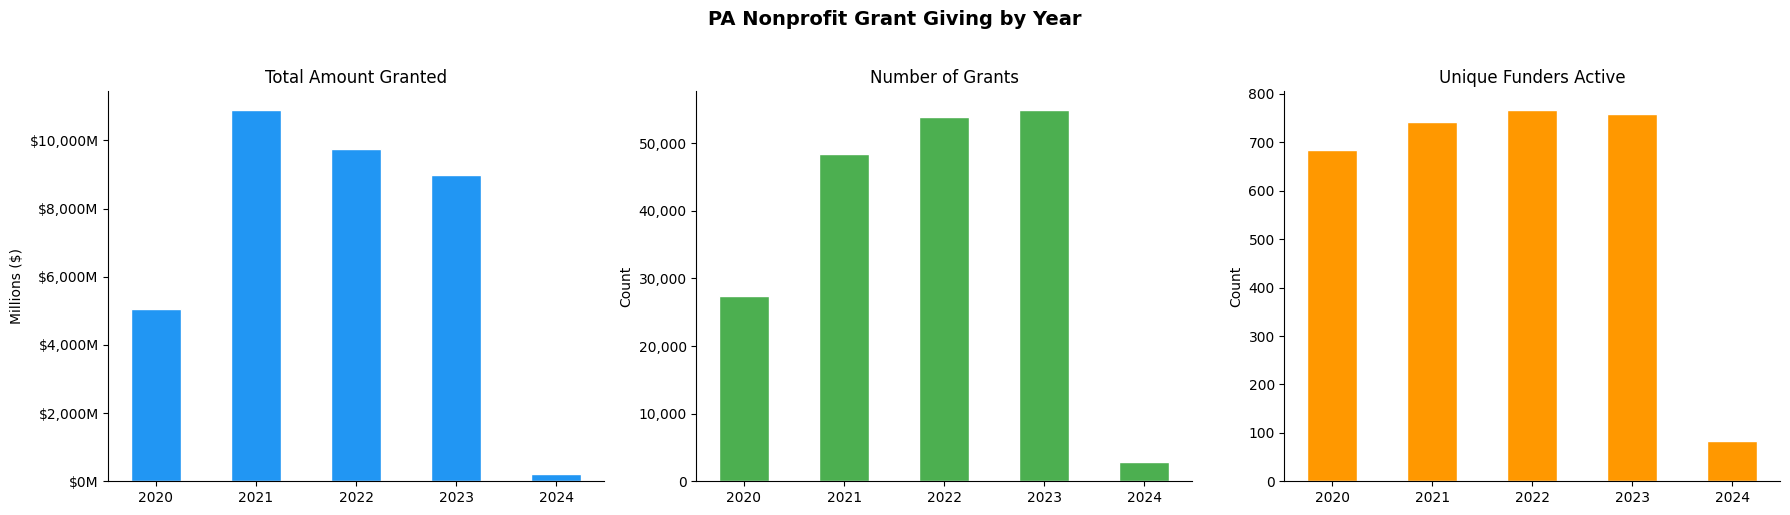

✓ Saved: chart_grants_by_year.png


In [ ]:
# =========================================================
# CELL 13: EDA — GRANTS BY YEAR
# =========================================================

year_df = (df.groupby("tax_year")
    .agg(
        num_grants     = ("amount", "count"),
        total_amount   = ("amount", "sum"),
        avg_grant      = ("amount", "mean"),
        median_grant   = ("amount", "median"),
        unique_funders = ("funder_ein", "nunique"),
        unique_recips  = ("recipient_name", "nunique"),).reset_index())

print("GRANTS BY YEAR")
display(year_df.assign(total_fmt  = year_df["total_amount"].apply(fmt_dollars),
    avg_fmt    = year_df["avg_grant"].apply(fmt_dollars),
    median_fmt = year_df["median_grant"].apply(fmt_dollars),)
[["tax_year","num_grants","total_fmt",
    "avg_fmt","median_fmt","unique_funders","unique_recips"]])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PA Nonprofit Grant Giving by Year", fontsize=14, fontweight="bold", y=1.02)

colors = ["#2196F3","#4CAF50","#FF9800"]
years  = year_df["tax_year"].astype(int).tolist()

# Total amount
axes[0].bar(years, year_df["total_amount"]/1e6, color=colors[0], edgecolor="white", width=0.5)
axes[0].set_title("Total Amount Granted")
axes[0].set_ylabel("Millions ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M"))
axes[0].set_xticks(years)
for spine in ["top","right"]: axes[0].spines[spine].set_visible(False)

# Number of grants
axes[1].bar(years, year_df["num_grants"], color=colors[1], edgecolor="white", width=0.5)
axes[1].set_title("Number of Grants")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].set_xticks(years)
for spine in ["top","right"]: axes[1].spines[spine].set_visible(False)

# Unique funders
axes[2].bar(years, year_df["unique_funders"], color=colors[2], edgecolor="white", width=0.5)
axes[2].set_title("Unique Funders Active")
axes[2].set_ylabel("Count")
axes[2].set_xticks(years)
for spine in ["top","right"]: axes[2].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "chart_grants_by_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: chart_grants_by_year.png")

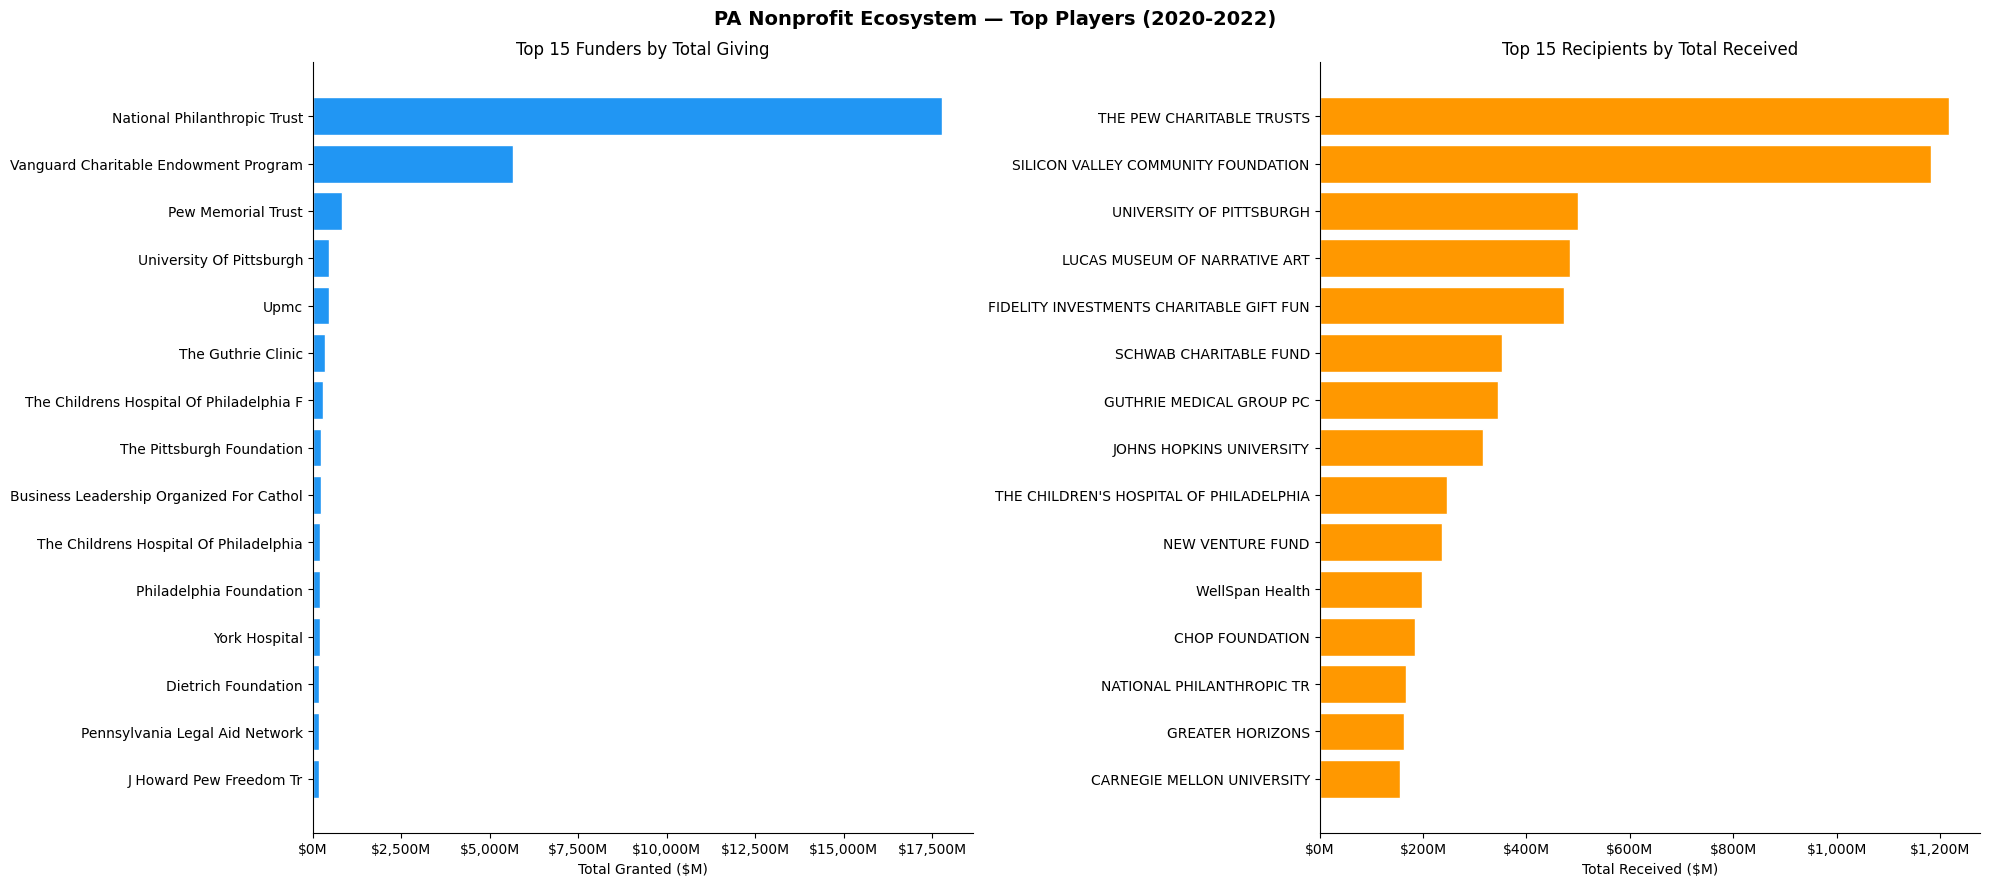


TOP 20 FUNDERS TABLE:


,funder_name,funder_city,total_given,num_grants,num_recips,avg_grant
592,National Philanthropic Trust,JENKINTOWN,$17.8B,53743,28902,$330.7K
937,Vanguard Charitable Endowment Program,MALVERN,$5.7B,62318,48276,$90.9K
680,Pew Memorial Trust,PHILADELPHIA,$814.0M,4,1,$203.5M
923,University Of Pittsburgh,PITTSBURGH,$466.3M,1374,605,$339.4K
930,Upmc,PITTSBURGH,$458.7M,903,571,$508.0K
857,The Guthrie Clinic,SYRE,$345.3M,4,1,$86.3M
842,The Childrens Hospital Of Philadelphia Foundation,PHILADELPHIA,$300.9M,10,5,$30.1M
874,The Pittsburgh Foundation,PITTSBURGH,$232.0M,4381,2281,$53.0K
120,Business Leadership Organized For Catholic Sch...,KNG OF PRUSSA,$224.2M,1082,488,$207.2K
841,The Childrens Hospital Of Philadelphia,PHILADELPHIA,$217.8M,690,380,$315.6K



TOP 20 RECIPIENTS TABLE:


,recipient_name,recipient_city,recipient_state,total_received,num_grants,num_funders
91574,THE PEW CHARITABLE TRUSTS,PHILADELPHIA,PA,$1.2B,27,7
79626,SILICON VALLEY COMMUNITY FOUNDATION,MOUNTAIN VIEW,CA,$1.2B,6,2
53464,LUCAS MUSEUM OF NARRATIVE ART,SAN FRANCISCO,CA,$485.0M,3,1
39072,GUTHRIE MEDICAL GROUP PC,SAYRE,PA,$345.3M,4,1
78224,SCHWAB CHARITABLE FUND,ORLANDO,FL,$329.6M,13,4
48154,JOHNS HOPKINS UNIVERSITY,BALTIMORE,MD,$315.6M,36,14
31632,FIDELITY INVESTMENTS CHARITABLE GIFT FUND,CINCINNATI,OH,$312.5M,4,2
97672,UNIVERSITY OF PITTSBURGH,Pittsburgh,PA,$267.2M,4,3
62654,NEW VENTURE FUND,WASHINGTON,DC,$235.9M,7,3
97671,UNIVERSITY OF PITTSBURGH,PITTSBURGH,PA,$232.3M,82,36


In [ ]:
# =========================================================
# CELL 14: EDA — TOP FUNDERS + RECIPIENTS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle("PA Nonprofit Ecosystem — Top Players (2020-2022)", fontsize=14, fontweight="bold")

# Top 15 funders
top_funders = (df.groupby("funder_name")["amount"]
    .sum().reset_index()
    .sort_values("amount", ascending=False)
    .head(15))
top_funders["label"] = top_funders["funder_name"].str[:40]

axes[0].barh(top_funders["label"][::-1],
    top_funders["amount"][::-1] / 1e6,
    color="#2196F3", edgecolor="white")

axes[0].set_title("Top 15 Funders by Total Giving", fontsize=12)
axes[0].set_xlabel("Total Granted ($M)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M"))
for spine in ["top","right"]: axes[0].spines[spine].set_visible(False)

# Top 15 recipients
top_recips = (df.groupby("recipient_name")["amount"]
    .sum().reset_index()
    .sort_values("amount", ascending=False)
    .head(15))

top_recips["label"] = top_recips["recipient_name"].str[:40]

axes[1].barh(
    top_recips["label"][::-1],
    top_recips["amount"][::-1] / 1e6,
    color="#FF9800", edgecolor="white")

axes[1].set_title("Top 15 Recipients by Total Received", fontsize=12)
axes[1].set_xlabel("Total Received ($M)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M"))
for spine in ["top","right"]: axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "chart_top_funders_recipients.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTOP 20 FUNDERS TABLE:")
display(df.groupby(["funder_name","funder_city"]).agg(
        total_given  = ("amount","sum"),
        num_grants   = ("amount","count"),
        num_recips   = ("recipient_name","nunique"),
        avg_grant    = ("amount","mean"),).reset_index()
    .sort_values("total_given", ascending=False)
    .head(20)
    .assign(total_given = lambda x: x["total_given"].apply(fmt_dollars),
        avg_grant   = lambda x: x["avg_grant"].apply(fmt_dollars),))

print("\nTOP 20 RECIPIENTS TABLE:")
display(df.groupby(["recipient_name","recipient_city","recipient_state"]).agg(
        total_received = ("amount","sum"),
        num_grants     = ("amount","count"),
        num_funders    = ("funder_ein","nunique"),).reset_index()
    .sort_values("total_received", ascending=False)
    .head(20)
    .assign(total_received = lambda x: x["total_received"].apply(fmt_dollars)))

IN-STATE vs OUT-OF-STATE:


,label,total,count,pct
0,Out-of-state,$24.6B,128797,70.4
1,In-state\n(PA→PA),$10.3B,58824,29.6


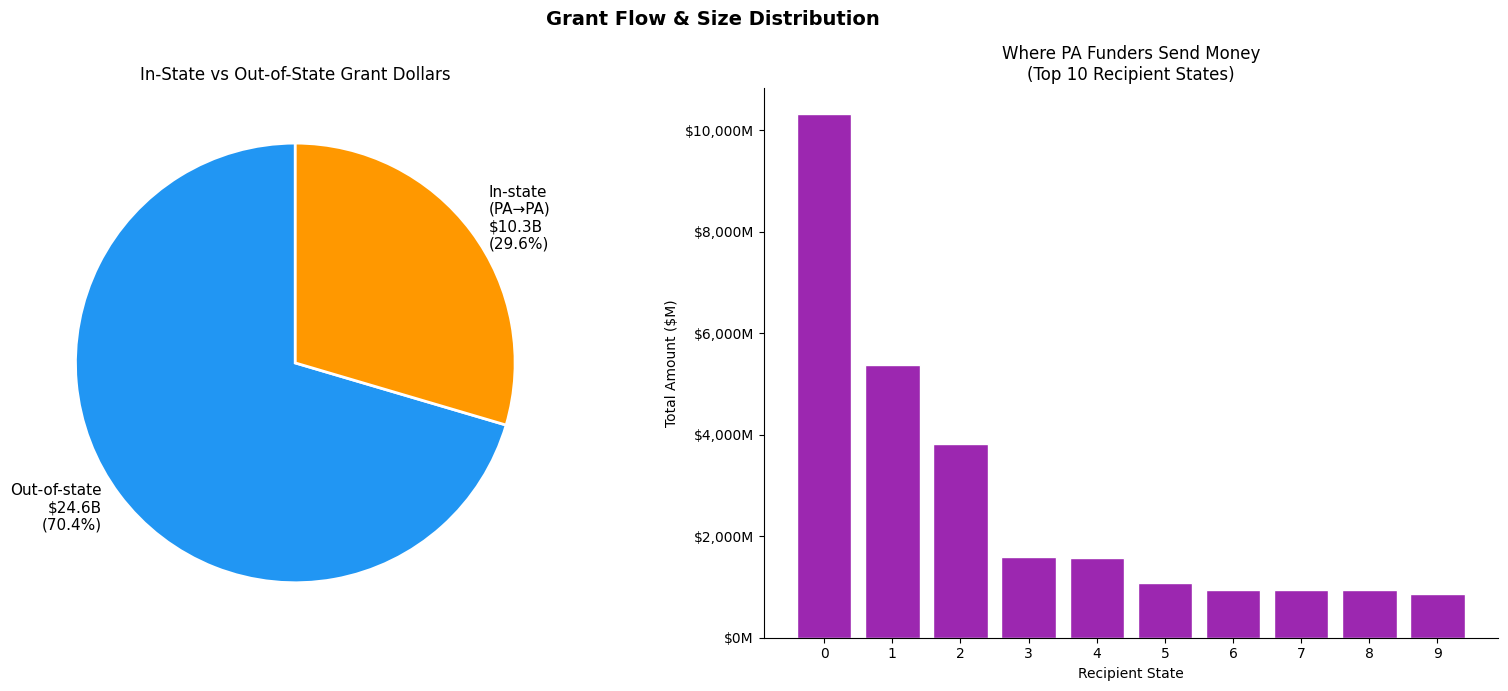

In [ ]:
# =========================================================
# CELL 15: EDA — IN-STATE vs OUT-OF-STATE + GRANT SIZE
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Grant Flow & Size Distribution", fontsize=14, fontweight="bold")

# In-state vs out-of-state
df["in_state"] = (df["funder_state"].str.upper().str.strip() ==
    df["recipient_state"].str.upper().str.strip())
state_flow = (df.groupby("in_state")["amount"]
    .agg(total="sum", count="count")
    .reset_index())
state_flow["label"] = state_flow["in_state"].map({True:"In-state\n(PA→PA)", False:"Out-of-state"})
state_flow["pct"]   = (100 * state_flow["total"] / state_flow["total"].sum()).round(1)

axes[0].pie(state_flow["total"],
    labels=[f"{r['label']}\n{fmt_dollars(r['total'])}\n({r['pct']}%)" for _, r in state_flow.iterrows()],
    colors=["#2196F3","#FF9800"],
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2},
    textprops={"fontsize":11})
axes[0].set_title("In-State vs Out-of-State Grant Dollars", fontsize=12)

print("IN-STATE vs OUT-OF-STATE:")
display(state_flow[["label","total","count","pct"]].assign(total=lambda x: x["total"].apply(fmt_dollars)))

# Top recipient states from PA funders
top_states = (df[df["funder_state"].str.upper() == "PA"]
    .groupby("recipient_state")["amount"]
    .sum().reset_index()
    .sort_values("amount", ascending=False)
    .head(10))
axes[1].bar(top_states["recipient_state"],
    top_states["amount"] / 1e6,
    color="#9C27B0", edgecolor="white")
axes[1].set_title("Where PA Funders Send Money\n(Top 10 Recipient States)", fontsize=12)
axes[1].set_xlabel("Recipient State")
axes[1].set_ylabel("Total Amount ($M)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x}"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M"))
for spine in ["top","right"]: axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "chart_flow_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

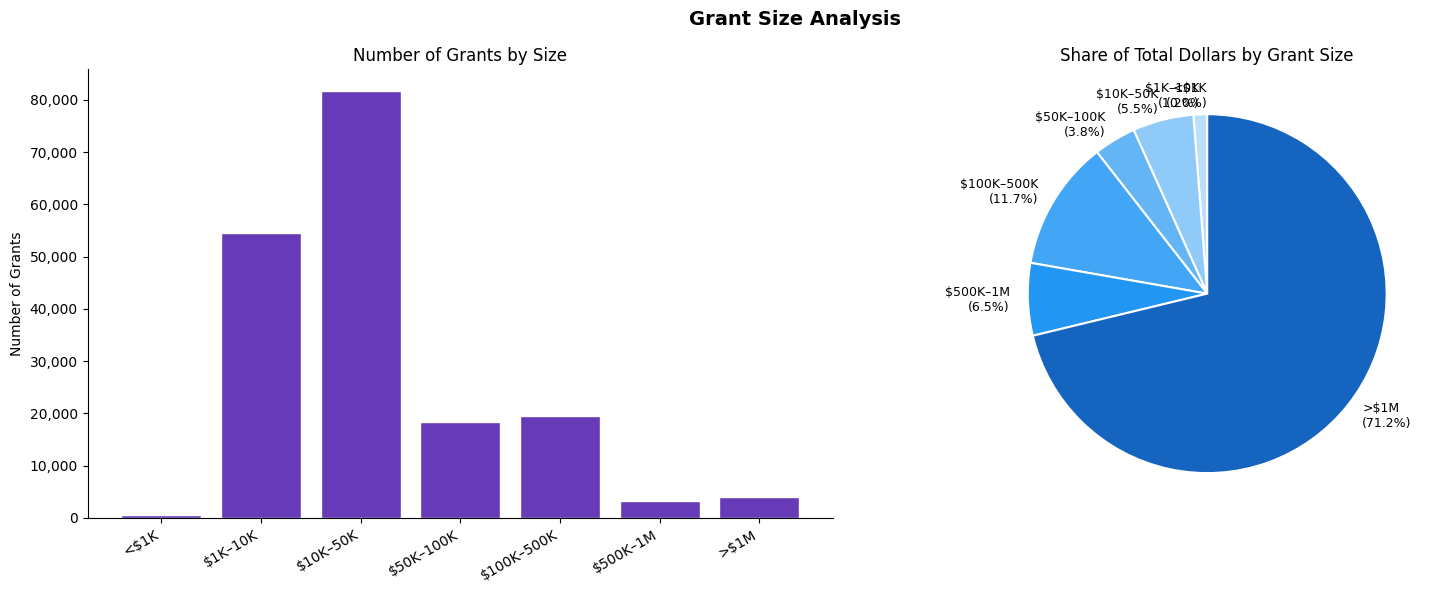


GRANT SIZE BREAKDOWN:


,bucket,count,pct_count,total_fmt,pct_dollars
0,<$1K,647,0.4,$327.0K,0.0
1,$1K–10K,54555,30.0,$429.9M,1.2
2,$10K–50K,81745,44.9,$1.9B,5.5
3,$50K–100K,18396,10.1,$1.3B,3.8
4,$100K–500K,19558,10.7,$4.1B,11.7
5,$500K–1M,3253,1.8,$2.3B,6.5
6,>$1M,3990,2.2,$24.9B,71.2


In [ ]:
# =========================================================
# CELL 16: EDA — GRANT SIZE DISTRIBUTION (FIXED)
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Grant Size Analysis", fontsize=14, fontweight="bold")

grant_amounts = df["amount"].dropna()
grant_amounts = grant_amounts[grant_amounts > 0]

bins   = [0, 1e3, 1e4, 5e4, 1e5, 5e5, 1e6, float("inf")]
labels = ["<$1K","$1K–10K","$10K–50K","$50K–100K","$100K–500K","$500K–1M",">$1M"]

# Add bucket column to df copy
df_buckets = df[df["amount"] > 0].copy()
df_buckets["bucket"] = pd.cut(df_buckets["amount"], bins=bins, labels=labels)

# Count and sum per bucket
bucket_summary = (df_buckets.groupby("bucket", observed=True)
    .agg(count=("amount","count"), total_amt=("amount","sum"))
    .reset_index())
bucket_summary["bucket"]     = bucket_summary["bucket"].astype(str)
bucket_summary["pct_count"]  = (100 * bucket_summary["count"]  / bucket_summary["count"].sum()).round(1)
bucket_summary["pct_dollars"]= (100 * bucket_summary["total_amt"] / bucket_summary["total_amt"].sum()).round(1)
bucket_summary["total_fmt"]  = bucket_summary["total_amt"].apply(fmt_dollars)

# Bar chart — count
axes[0].bar(bucket_summary["bucket"],
    bucket_summary["count"],
    color="#673AB7", edgecolor="white")
axes[0].set_xticklabels(bucket_summary["bucket"], rotation=30, ha="right")
axes[0].set_title("Number of Grants by Size")
axes[0].set_ylabel("Number of Grants")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ["top","right"]: axes[0].spines[spine].set_visible(False)

# Pie chart — dollar share
axes[1].pie(bucket_summary["total_amt"],
    labels=[f"{r['bucket']}\n({r['pct_dollars']}%)" for _, r in bucket_summary.iterrows()],
    colors=["#E3F2FD","#BBDEFB","#90CAF9","#64B5F6","#42A5F5","#2196F3","#1565C0"],
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":1.5},
    textprops={"fontsize":9})
axes[1].set_title("Share of Total Dollars by Grant Size")

plt.tight_layout()
plt.savefig(OUT_DIR / "chart_grant_size.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nGRANT SIZE BREAKDOWN:")
display(bucket_summary[["bucket","count","pct_count","total_fmt","pct_dollars"]])

In [ ]:
!pip install pgeocode -q
# =========================================================
# CELL 17: MAP — PA FUNDERS
# =========================================================

!pip install pgeocode -q

import folium
from folium.plugins import MarkerCluster
import pgeocode

nomi = pgeocode.Nominatim("us")

def get_coords(zipcode):
    if pd.isna(zipcode) or not zipcode:
        return None, None
    try:
        info = nomi.query_postal_code(str(zipcode)[:5])
        lat, lon = info.latitude, info.longitude
        if pd.isna(lat) or pd.isna(lon):
            return None, None
        return lat, lon
    except Exception:
        return None, None

# Build funder summary with top recipients per funder
funder_map_df = (df.groupby(["funder_ein","funder_name","funder_city","funder_state","funder_zipcode"]).agg(
        total_given  = ("amount","sum"),
        num_grants   = ("amount","count"),
        num_recips   = ("recipient_name","nunique"),).reset_index())

# Get top 5 recipients per funder for popup
top_recips_per_funder = (df.groupby(["funder_ein","recipient_name"])["amount"]
    .sum().reset_index()
    .sort_values(["funder_ein","amount"], ascending=[True, False])
    .groupby("funder_ein")
    .head(5))

def get_top_recips_html(ein):
    rows = top_recips_per_funder[top_recips_per_funder["funder_ein"] == ein]
    if len(rows) == 0:
        return "No grant data"
    lines = [f"<li>{r['recipient_name']} — {fmt_dollars(r['amount'])}</li>" for _, r in rows.iterrows()]
    return "<ul>" + "".join(lines) + "</ul>"

# Get coords
print("Getting coordinates for funders...")
funder_map_df[["lat","lon"]] = funder_map_df["funder_zipcode"].apply(lambda z: pd.Series(get_coords(z)))

valid = funder_map_df.dropna(subset=["lat","lon"])
print(f"Funders with coordinates: {len(valid):,} of {len(funder_map_df):,}")

# Build map
m_funders = folium.Map(location=[40.5, -77.5],
    zoom_start=7,
    tiles="CartoDB positron")

cluster = MarkerCluster(options={"maxClusterRadius": 40, "disableClusteringAtZoom": 10}).add_to(m_funders)

for _, row in valid.iterrows():
    popup_html = f"""
    <div style="font-family:Arial; width:280px;">
        <h4 style="margin:0;color:#1565C0;">{row['funder_name']}</h4>
        <p style="margin:4px 0;color:#555;">{row['funder_city']}, {row['funder_state']} {row['funder_zipcode']}</p>
        <hr style="margin:6px 0;">
        <b>Total Granted:</b> {fmt_dollars(row['total_given'])}<br>
        <b>Number of Grants:</b> {int(row['num_grants']):,}<br>
        <b>Unique Recipients:</b> {int(row['num_recips']):,}<br>
        <hr style="margin:6px 0;">
        <b>Top Recipients:</b>
        {get_top_recips_html(row['funder_ein'])}
    </div>
    """
    folium.CircleMarker(location=[row["lat"], row["lon"]],
        radius=max(6, min(20, row["total_given"] / 5e6)),
        color="#1565C0",
        fill=True,
        fill_color="#2196F3",
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{row['funder_name']} — {fmt_dollars(row['total_given'])}",).add_to(cluster)

m_funders.save(str(OUT_DIR / "map_pa_funders.html"))
print("✓ Saved: map_pa_funders.html")
display(m_funders)

Getting coordinates for funders...
Funders with coordinates: 1,012 of 1,013
✓ Saved: map_pa_funders.html
